In [ ]:
import numpy as np
from itertools import permutations

# Step 1: the 24 elements of S_4, each as a tuple (sigma(0),sigma(1),sigma(2),sigma(3))
elements = list(permutations(range(4)))   # 24 tuples; elements[0] = (0,1,2,3) = identity
n = len(elements)                          # 24
idx = {g: i for i, g in enumerate(elements)}   # element -> its index 0..23

# Step 2: composition (sigma o tau)(x) = sigma(tau(x))  -- apply tau first, then sigma
def compose(sigma, tau):
    return tuple(sigma[tau[x]] for x in range(4))

# Step 3: the Cayley table as indices.  cayley[i,j] = index of (elements[i] o elements[j])
cayley = np.zeros((n, n), dtype=int)
for i, gi in enumerate(elements):
    for j, gj in enumerate(elements):
        cayley[i, j] = idx[compose(gi, gj)]

# ---- CORRECTNESS GATES (verify it's actually a group before trusting it) ----
# (a) identity: composing with element 0 must do nothing
e = idx[(0,1,2,3)]
assert all(cayley[e, j] == j for j in range(n)), "identity row broken"
assert all(cayley[i, e] == i for i in range(n)), "identity column broken"

# (b) every row and every column is a permutation of 0..23 (Latin square property)
for i in range(n):
    assert sorted(cayley[i, :]) == list(range(n)), f"row {i} not a permutation"
    assert sorted(cayley[:, i]) == list(range(n)), f"col {i} not a permutation"

# (c) associativity on a sample (full check is 24^3; sample is enough to catch convention bugs)
import random
for _ in range(2000):
    a, b, c = random.randrange(n), random.randrange(n), random.randrange(n)
    assert cayley[cayley[a,b], c] == cayley[a, cayley[b,c]], "associativity broken"

# (d) every element has an inverse
inverses = [next(j for j in range(n) if cayley[i,j] == e) for i in range(n)]
print("all 24 elements have inverses:", len(set(inverses)) == n)
print("Cayley table built and verified as a group. Shape:", cayley.shape)

all 24 elements have inverses: True
Cayley table built and verified as a group. Shape: (24, 24)


In [ ]:
# the regular representation: L[g] is the 24x24 permutation matrix for group element g
L = np.zeros((n, n, n))
for g in range(n):
    for j in range(n):
        L[g, cayley[g, j], j] = 1.0
# this L is exactly what plugs into the character projector, replacing mod-29's cyclic shift

In [ ]:
# derive conjugacy classes from cycle type (do NOT hand-assign -- that's the bug risk)
def cycle_type(perm):
    seen = [False]*4
    cycles = []
    for start in range(4):
        if not seen[start]:
            length = 0
            x = start
            while not seen[x]:
                seen[x] = True
                x = perm[x]
                length += 1
            cycles.append(length)
    return tuple(sorted(cycles, reverse=True))   # e.g. (2,1,1) for a transposition

# map each of the 24 elements to its cycle type, then group
from collections import defaultdict
classes = defaultdict(list)
for i, g in enumerate(elements):
    classes[cycle_type(g)].append(i)

# report the class structure -- this MUST match 1+6+3+8+6
print("Conjugacy classes of S_4 (by cycle type):")
for ct, members in sorted(classes.items(), key=lambda kv: (-len(kv[0]), kv[0])):
    print(f"  cycle type {ct}: {len(members)} elements")
print("total:", sum(len(m) for m in classes.values()))

# ---- correctness gate: classes must be closed under conjugation ----
# (g h g^-1 is in the same class as h, for all g) -- this VERIFIES the class structure
inv = [next(j for j in range(n) if cayley[i,j]==idx[(0,1,2,3)]) for i in range(n)]
def conjugate(g, h):            # g h g^-1
    return cayley[cayley[g, h], inv[g]]
elem_to_class = {}
for ci, (ct, members) in enumerate(classes.items()):
    for m in members:
        elem_to_class[m] = ci
ok = all(elem_to_class[conjugate(g,h)] == elem_to_class[h]
         for g in range(n) for h in range(n))
print("classes closed under conjugation (verifies structure):", ok)

Conjugacy classes of S_4 (by cycle type):
  cycle type (1, 1, 1, 1): 1 elements
  cycle type (2, 1, 1): 6 elements
  cycle type (2, 2): 3 elements
  cycle type (3, 1): 8 elements
  cycle type (4,): 6 elements
total: 24
classes closed under conjugation (verifies structure): True


In [ ]:
# fix an explicit class order matching the character table columns
class_order = [(1,1,1,1), (2,1,1), (2,2), (3,1), (4,)]   # identity, transp, double, 3-cyc, 4-cyc
class_members = [classes[ct] for ct in class_order]
class_sizes = np.array([len(m) for m in class_members])   # [1, 6, 3, 8, 6]

# map each element index -> which class column it belongs to (0..4)
elem_class = np.zeros(n, dtype=int)
for ci, members in enumerate(class_members):
    for m in members:
        elem_class[m] = ci

# S_4 character table: rows = irreps, cols = classes in class_order
# cols:           e   (2,1,1)  (2,2)  (3,1)  (4)
char_table = np.array([
    [1,   1,    1,   1,   1],    # trivial      (dim 1)
    [1,  -1,    1,   1,  -1],    # sign         (dim 1)
    [2,   0,    2,  -1,   0],    # standard 2d  (dim 2)
    [3,   1,   -1,   0,  -1],    # standard 3d  (dim 3)  <- TARGET
    [3,  -1,   -1,   0,   1],    # 3d (x) sign  (dim 3)
], dtype=float)
dims = char_table[:, 0].astype(int)   # [1,1,2,3,3]

# ---- VERIFY the character table before trusting it ----
# (a) dimensions squared sum to |G|
print("sum of dim^2 =", int((dims**2).sum()), " (must be 24)")

# (b) ROW orthogonality: <chi_i, chi_j> = (1/|G|) sum_classes |class| chi_i chi_j = delta_ij
G = float(n)
row_orth = np.zeros((5,5))
for i in range(5):
    for j in range(5):
        row_orth[i,j] = (class_sizes * char_table[i] * char_table[j]).sum() / G
print("row orthogonality = identity:", np.allclose(row_orth, np.eye(5)))

# (c) COLUMN orthogonality: sum_irreps chi(C1) chi(C2) = (|G|/|C1|) delta_{C1,C2}
col_ok = True
for a in range(5):
    for b in range(5):
        lhs = (char_table[:,a] * char_table[:,b]).sum()
        rhs = (G/class_sizes[a]) if a==b else 0.0
        if not np.isclose(lhs, rhs): col_ok = False
print("column orthogonality holds:", col_ok)

sum of dim^2 = 24  (must be 24)
row orthogonality = identity: True
column orthogonality holds: True


In [ ]:
# build character projectors P_rho = (d_rho/|G|) sum_g conj(chi_rho(class(g))) L[g]
def projector(rho):
    Prho = np.zeros((n, n), dtype=complex)
    for g in range(n):
        Prho += char_table[rho, elem_class[g]] * L[g]   # chi is real for S_4
    return (dims[rho] / G) * Prho

# ---- THE GATE: projectors must resolve the identity ----
S = sum(projector(r) for r in range(5))
print("completeness ||sum_rho P_rho - I|| =", np.linalg.norm(S - np.eye(n)), " (want ~1e-13)")

# each projector idempotent, and its rank = dim^2 (the isotypic block dimension)
for r in range(5):
    Pr = projector(r)
    rank = np.linalg.matrix_rank(Pr, tol=1e-9)
    print(f"  irrep {r} (dim {dims[r]}): idempotent={np.allclose(Pr@Pr, Pr, atol=1e-9)}, "
          f"rank={rank} (expect {dims[r]**2})")

completeness ||sum_rho P_rho - I|| = 0.0  (want ~1e-13)
  irrep 0 (dim 1): idempotent=True, rank=1 (expect 1)
  irrep 1 (dim 1): idempotent=True, rank=1 (expect 1)
  irrep 2 (dim 2): idempotent=True, rank=4 (expect 4)
  irrep 3 (dim 3): idempotent=True, rank=9 (expect 9)
  irrep 4 (dim 3): idempotent=True, rank=9 (expect 9)


In [ ]:
import torch, torch.nn as nn, numpy as np

# ---- S_4 group-task data: input (i,j) -> product from the VERIFIED Cayley table ----
n = 24
# all 576 input pairs and their products
I, J = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
X = np.stack([I.ravel(), J.ravel()], axis=1)        # (576, 2) input pairs
Y = cayley[I.ravel(), J.ravel()]                      # (576,) products -- from your table
X = torch.tensor(X, dtype=torch.long)
Y = torch.tensor(Y, dtype=torch.long)

# train/test split (same grokking recipe as mod-29: train on a fraction, hold out rest)
torch.manual_seed(0)
perm = torch.randperm(len(X))
n_train = int(0.7 * len(X))
train_idx, test_idx = perm[:n_train], perm[n_train:]

# ---- model: same MLP shape as mod-29, vocab 29->24 ----
class GroupMLP(nn.Module):
    def __init__(self, n_vocab=24, d_embed=48, d_hidden=128):
        super().__init__()
        self.embed = nn.Embedding(n_vocab, d_embed)      # shared embedding for both inputs
        self.W_in  = nn.Linear(2*d_embed, d_hidden, bias=False)
        self.W_out = nn.Linear(d_hidden, n_vocab, bias=False)
        self.act = nn.ReLU()
    def forward(self, x):
        a = self.embed(x[:,0]); b = self.embed(x[:,1])
        h = self.act(self.W_in(torch.cat([a, b], dim=-1)))
        return self.W_out(h)

model = GroupMLP()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))
loss_fn = nn.CrossEntropyLoss()

# ---- train to grokking ----
for step in range(20000):
    model.train()
    logits = model(X[train_idx])
    loss = loss_fn(logits, Y[train_idx])
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 1000 == 0:
        model.eval()
        with torch.no_grad():
            tr = (model(X[train_idx]).argmax(1) == Y[train_idx]).float().mean().item()
            te = (model(X[test_idx]).argmax(1)  == Y[test_idx]).float().mean().item()
        print(f"step {step:5d} | loss {loss.item():.4f} | train acc {tr:.3f} | test acc {te:.3f}")

# final check
model.eval()
with torch.no_grad():
    te = (model(X[test_idx]).argmax(1) == Y[test_idx]).float().mean().item()
print(f"\nFINAL test accuracy: {te:.3f}  (need ~1.0 for clean grokking before projecting)")

step     0 | loss 3.2047 | train acc 0.050 | test acc 0.075
step  1000 | loss 0.0001 | train acc 1.000 | test acc 0.040
step  2000 | loss 0.0000 | train acc 1.000 | test acc 0.220
step  3000 | loss 0.0000 | train acc 1.000 | test acc 0.451
step  4000 | loss 0.0000 | train acc 1.000 | test acc 0.561
step  5000 | loss 0.0000 | train acc 1.000 | test acc 0.665
step  6000 | loss 0.0000 | train acc 1.000 | test acc 0.746
step  7000 | loss 0.0000 | train acc 1.000 | test acc 0.827
step  8000 | loss 0.0000 | train acc 1.000 | test acc 0.844
step  9000 | loss 0.0000 | train acc 1.000 | test acc 0.902
step 10000 | loss 0.0000 | train acc 1.000 | test acc 0.971
step 11000 | loss 0.0000 | train acc 1.000 | test acc 0.988
step 12000 | loss 0.0000 | train acc 1.000 | test acc 0.994
step 13000 | loss 0.0000 | train acc 1.000 | test acc 1.000
step 14000 | loss 0.0000 | train acc 1.000 | test acc 1.000
step 15000 | loss 0.0000 | train acc 1.000 | test acc 1.000
step 16000 | loss 0.0000 | train acc 1.0

In [ ]:
import numpy as np

# the trained, grokked embedding (24 elements x 48 dims)
W_E = model.embed.weight.detach().cpu().numpy()    # (24, 48)

# energy of the embedding landing in each irrep's isotypic block
def irrep_energy(emb):
    return np.array([np.real(np.sum(np.conj(projector(r) @ emb) * (projector(r) @ emb)))
                     for r in range(5)])

real_energy = irrep_energy(W_E)
real_frac = real_energy / real_energy.sum()

# ---- NULL: random embeddings of the same shape, same norm structure ----
rng = np.random.default_rng(0)
null_fracs = []
for _ in range(2000):
    rand_emb = rng.standard_normal(W_E.shape)
    rand_emb *= np.linalg.norm(W_E) / np.linalg.norm(rand_emb)   # match total norm
    e = irrep_energy(rand_emb)
    null_fracs.append(e / e.sum())
null_fracs = np.array(ир) if False else np.array(null_fracs)      # (2000, 5)

null_mean = null_fracs.mean(0)
null_std  = null_fracs.std(0)
z = (real_frac - null_mean) / null_std

irrep_names = ["trivial (1d)", "sign (1d)", "standard (2d)", "STANDARD (3d)", "3d x sign (3d)"]
print(f"{'irrep':<18}{'real %':>9}{'null %':>9}{'z-score':>10}")
print("-"*46)
for i, name in enumerate(irrep_names):
    flag = "  <-- HIGH-DIM TARGET" if i == 3 else ""
    print(f"{name:<18}{real_frac[i]*100:>8.1f}%{null_mean[i]*100:>8.1f}%{z[i]:>+10.1f}{flag}")

print(f"\nenergy in 1d irreps (trivial+sign): {(real_frac[0]+real_frac[1])*100:.1f}%")
print(f"energy in high-dim irreps (2d+3d+3d): {(real_frac[2]+real_frac[3]+real_frac[4])*100:.1f}%")
print(f"the trivial-irrep floor (what 'doing nothing' always gives): null puts {null_mean[0]*100:.1f}% there")

irrep                real %   null %   z-score
----------------------------------------------
trivial (1d)           0.3%     4.2%      -4.6
sign (1d)              9.6%     4.2%      +6.5
standard (2d)         17.8%    16.7%      +0.7
STANDARD (3d)         67.1%    37.5%     +14.8  <-- HIGH-DIM TARGET
3d x sign (3d)         5.1%    37.5%     -16.4

energy in 1d irreps (trivial+sign): 10.0%
energy in high-dim irreps (2d+3d+3d): 90.0%
the trivial-irrep floor (what 'doing nothing' always gives): null puts 4.2% there


In [ ]:
import numpy as np

W_E_clean = model.embed.weight.detach().cpu().numpy()   # (24, 48), the validated grokked embedding
rng = np.random.default_rng(0)

# precompute null (same as before) so z-scores are comparable across the sweep
def irrep_frac(emb):
    e = np.array([np.real(np.sum(np.conj(projector(r) @ emb) * (projector(r) @ emb)))
                  for r in range(5)])
    return e / e.sum()

null_fracs = []
for _ in range(2000):
    r = rng.standard_normal(W_E_clean.shape); r *= np.linalg.norm(W_E_clean)/np.linalg.norm(r)
    null_fracs.append(irrep_frac(r))
null_fracs = np.array(null_fracs)
null_mean, null_std = null_fracs.mean(0), null_fracs.std(0)

# ---- NOISE SWEEP: perturb the clean embedding by increasing fractions of its norm ----
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]
n_trials = 20   # average over noise draws at each level

print(f"{'noise':>7}{'3d energy %':>13}{'3d z-score':>12}{'1d energy %':>13}{'detectable?':>13}")
print("-"*58)
for nl in noise_levels:
    fracs_3d, zs_3d, fracs_1d = [], [], []
    for _ in range(n_trials):
        noise = rng.standard_normal(W_E_clean.shape)
        noise *= nl * np.linalg.norm(W_E_clean) / max(np.linalg.norm(noise), 1e-12)
        emb = W_E_clean + noise
        f = irrep_frac(emb)
        fracs_3d.append(f[3]); fracs_1d.append(f[0]+f[1])
        zs_3d.append((f[3] - null_mean[3]) / null_std[3])
    m3, z3, m1 = np.mean(fracs_3d), np.mean(zs_3d), np.mean(fracs_1d)
    detect = "YES" if z3 > 3 else ("marginal" if z3 > 2 else "NO")
    print(f"{nl:>7.2f}{m3*100:>12.1f}%{z3:>+12.1f}{m1*100:>12.1f}%{detect:>13}")

print(f"\n(null floor for 3d irrep: {null_mean[3]*100:.1f}% -- structure is gone when 3d energy returns here)")
print(f"(clean baseline at noise=0 should reproduce ~67% energy, z~+14.8)")

  noise  3d energy %  3d z-score  1d energy %  detectable?
----------------------------------------------------------
   0.00        67.1%       +14.8        10.0%          YES
   0.05        67.0%       +14.8         9.9%          YES
   0.10        66.9%       +14.7         9.9%          YES
   0.20        66.1%       +14.3         9.9%          YES
   0.30        64.9%       +13.7         9.8%          YES
   0.50        61.0%       +11.8         9.6%          YES
   0.75        56.6%        +9.6         9.7%          YES
   1.00        52.0%        +7.3         9.5%          YES
   1.50        46.2%        +4.4         8.7%          YES
   2.00        43.3%        +2.9         8.9%     marginal

(null floor for 3d irrep: 37.5% -- structure is gone when 3d energy returns here)
(clean baseline at noise=0 should reproduce ~67% energy, z~+14.8)


In [ ]:
import numpy as np
W_E_clean = model.embed.weight.detach().cpu().numpy()
rng = np.random.default_rng(0)

def irrep_frac(emb):
    e = np.array([np.real(np.sum(np.conj(projector(r) @ emb) * (projector(r) @ emb)))
                  for r in range(5)])
    return e / e.sum()

# null
null_fracs = np.array([irrep_frac((lambda r: r*np.linalg.norm(W_E_clean)/np.linalg.norm(r))
                       (rng.standard_normal(W_E_clean.shape))) for _ in range(2000)])
null_mean, null_std = null_fracs.mean(0), null_fracs.std(0)

names = ["trivial(1d)", "sign(1d)", "std(2d)", "STD(3d)", "3dxsign(3d)"]
noise_levels = [0.0, 0.1, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]

print("z-scores per irrep across weight-noise levels:")
print(f"{'noise':>6} " + "".join(f"{nm:>13}" for nm in names))
print("-"*72)
for nl in noise_levels:
    zs = np.zeros(5)
    for _ in range(20):
        noise = rng.standard_normal(W_E_clean.shape)
        noise *= nl * np.linalg.norm(W_E_clean) / max(np.linalg.norm(noise), 1e-12)
        f = irrep_frac(W_E_clean + noise)
        zs += (f - null_mean) / null_std
    zs /= 20
    print(f"{nl:>6.2f} " + "".join(f"{z:>+13.1f}" for z in zs))

z-scores per irrep across weight-noise levels:
 noise   trivial(1d)     sign(1d)      std(2d)      STD(3d)  3dxsign(3d)
------------------------------------------------------------------------
  0.00          -4.6         +6.5         +0.7        +14.8        -16.4
  0.10          -4.6         +6.3         +0.8        +14.7        -16.2
  0.30          -4.3         +5.8         +0.5        +13.7        -14.9
  0.50          -3.7         +5.2         +0.4        +12.0        -13.2
  0.75          -2.8         +4.1         +0.3         +9.7        -10.6
  1.00          -2.3         +3.2         +0.5         +7.3         -8.1
  1.50          -1.5         +2.6         -0.0         +4.6         -5.1
  2.00          -0.8         +1.7         -0.1         +2.9         -3.2


In [ ]:
import torch, torch.nn as nn, numpy as np

def make_corrupted_cayley(frac, seed):
    rng = np.random.default_rng(seed); c = cayley.copy()
    k = int(frac*24*24); fi = rng.choice(24*24, k, replace=False)
    for f in fi:
        i, j = f//24, f%24; w = rng.integers(0,24)
        while w == cayley[i,j]: w = rng.integers(0,24)
        c[i,j] = w
    assert abs((c!=cayley).sum()/(24*24) - frac) < 0.01   # verify corruption amount
    return c

def train_disambig(corrupt_table, steps=20000):
    n = 24
    I,J = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
    X = torch.tensor(np.stack([I.ravel(),J.ravel()],1), dtype=torch.long)
    Yc = torch.tensor(corrupt_table[I.ravel(),J.ravel()], dtype=torch.long)   # corrupted labels
    Yt = torch.tensor(cayley[I.ravel(),J.ravel()], dtype=torch.long)          # TRUE labels
    torch.manual_seed(0)
    perm = torch.randperm(len(X)); ntr = int(0.7*len(X)); tri, tei = perm[:ntr], perm[ntr:]
    m = GroupMLP(); opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9,0.98))
    lf = nn.CrossEntropyLoss()
    for _ in range(steps):
        m.train(); opt.zero_grad(); lf(m(X[tri]), Yc[tri]).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        trc = (m(X[tri]).argmax(1)==Yc[tri]).float().mean().item()    # train on corrupted
        tec = (m(X[tei]).argmax(1)==Yc[tei]).float().mean().item()    # test on corrupted
        tet = (m(X[tei]).argmax(1)==Yt[tei]).float().mean().item()    # test on TRUE
        allt = (m(X).argmax(1)==Yt).float().mean().item()             # all pairs, TRUE
    W = m.embed.weight.detach().cpu().numpy()
    f = irrep_frac(W); z = (f - null_mean)/null_std
    return trc, tec, tet, allt, f[3], z[3]

print(f"{'corr%':>6}{'tr(corr)':>9}{'te(corr)':>9}{'te(TRUE)':>9}{'all(TRUE)':>10}{'3d%':>7}{'3d z':>7}")
print("-"*57)
for fc in [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]:
    trc,tec,tet,allt,f3,z3 = train_disambig(make_corrupted_cayley(fc, 42))
    print(f"{fc*100:>5.0f}%{trc:>9.2f}{tec:>9.2f}{tet:>9.2f}{allt:>10.2f}{f3*100:>6.1f}%{z3:>+7.1f}")

 corr% tr(corr) te(corr) te(TRUE) all(TRUE)    3d%   3d z
---------------------------------------------------------
    0%     1.00     1.00     1.00      1.00  67.1%  +14.8
    5%     1.00     0.68     0.72      0.88  51.3%   +6.9
   10%     1.00     0.41     0.48      0.78  49.5%   +6.0
   20%     1.00     0.04     0.05      0.57  40.6%   +1.6
   30%     1.00     0.03     0.03      0.51  40.2%   +1.4
   50%     1.00     0.02     0.01      0.36  40.3%   +1.4


In [ ]:
# =====================================================================================
# FULL VALIDATION SCRIPT — re-derives and gates every claim from scratch.
# Run in a fresh Colab cell. Every CLAIM prints PASS/FAIL. If anything FAILs, that
# result is not trustworthy and should not go to Lee / the paper.
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations
from collections import defaultdict

PASS = lambda b: "✓ PASS" if b else "✗✗✗ FAIL"
results = {}

print("="*80); print("PART 1 — GROUP MACHINERY (is the detector itself correct?)"); print("="*80)

# --- build S_4 ---
elements = list(permutations(range(4))); n = len(elements); idx = {g:i for i,g in enumerate(elements)}
compose = lambda s,t: tuple(s[t[x]] for x in range(4))
cayley = np.array([[idx[compose(gi,gj)] for gj in elements] for gi in elements])

# CLAIM 1: Cayley table is a valid group (identity, Latin square, associative, inverses)
e = idx[(0,1,2,3)]
g1 = (all(cayley[e,j]==j for j in range(n)) and all(cayley[i,e]==i for i in range(n))
      and all(sorted(cayley[i,:].tolist())==list(range(n)) for i in range(n))
      and all(sorted(cayley[:,i].tolist())==list(range(n)) for i in range(n)))
import random
g1 = g1 and all(cayley[cayley[a,b],c]==cayley[a,cayley[b,c]]
                for a,b,c in [(random.randrange(n),random.randrange(n),random.randrange(n)) for _ in range(3000)])
results['1_valid_group'] = g1; print(f"CLAIM 1  Cayley table is a valid group: {PASS(g1)}")

# --- classes + characters ---
def cyc_type(p):
    seen=[False]*4; cs=[]
    for s in range(4):
        if not seen[s]:
            L=0; x=s
            while not seen[x]: seen[x]=True; x=p[x]; L+=1
            cs.append(L)
    return tuple(sorted(cs,reverse=True))
classes = defaultdict(list)
for i,g in enumerate(elements): classes[cyc_type(g)].append(i)
class_order=[(1,1,1,1),(2,1,1),(2,2),(3,1),(4,)]
class_members=[classes[ct] for ct in class_order]; class_sizes=np.array([len(m) for m in class_members])
elem_class=np.zeros(n,dtype=int)
for ci,m in enumerate(class_members):
    for x in m: elem_class[x]=ci

# CLAIM 2: class sizes are 1,6,3,8,6 and closed under conjugation
inv=[next(j for j in range(n) if cayley[i,j]==e) for i in range(n)]
conj=lambda g,h: cayley[cayley[g,h],inv[g]]
e2c={x:ci for ci,m in enumerate(class_members) for x in m}
g2 = (class_sizes.tolist()==[1,6,3,8,6]) and all(e2c[conj(g,h)]==e2c[h] for g in range(n) for h in range(n))
results['2_classes'] = g2; print(f"CLAIM 2  Conjugacy classes correct (1,6,3,8,6, conj-closed): {PASS(g2)}")

char_table=np.array([[1,1,1,1,1],[1,-1,1,1,-1],[2,0,2,-1,0],[3,1,-1,0,-1],[3,-1,-1,0,1]],dtype=float)
dims=char_table[:,0].astype(int); G=float(n)

# CLAIM 3: character table satisfies orthogonality + dims^2 sum to |G|
row_orth=np.array([[(class_sizes*char_table[i]*char_table[j]).sum()/G for j in range(5)] for i in range(5)])
g3 = np.allclose(row_orth,np.eye(5)) and int((dims**2).sum())==n
results['3_chartable'] = g3; print(f"CLAIM 3  Character table valid (orthogonal, Σdim²=24): {PASS(g3)}")

# --- projectors ---
L=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): L[g,cayley[g,j],j]=1.0
def projector(r):
    P=np.zeros((n,n),dtype=complex)
    for g in range(n): P+=char_table[r,elem_class[g]]*L[g]
    return (dims[r]/G)*P

# CLAIM 4: projectors resolve identity, are idempotent, rank = dim²
Ps=[projector(r) for r in range(5)]
comp=np.linalg.norm(sum(Ps)-np.eye(n))
g4 = comp<1e-9 and all(np.allclose(P@P,P,atol=1e-9) for P in Ps) and \
     all(np.linalg.matrix_rank(Ps[r],tol=1e-9)==dims[r]**2 for r in range(5))
results['4_projectors'] = g4
print(f"CLAIM 4  Projectors valid (completeness={comp:.0e}, idempotent, rank=dim²): {PASS(g4)}")

def irrep_frac(W):
    ev=np.array([np.real(np.sum(np.conj(P@W)*(P@W))) for P in Ps]); return ev/ev.sum()

# CLAIM 5: DETECTOR POSITIVE CONTROL — synthetic pure-3d embedding reads ~100% in irrep 3
rng=np.random.default_rng(1)
pure3d=np.real(Ps[3]@rng.standard_normal((n,5)))
g5 = irrep_frac(pure3d)[3] > 0.99
results['5_detector_posctrl'] = g5
print(f"CLAIM 5  Detector reads 1.0 on synthetic pure-3d (isolates the irrep): {PASS(g5)}")

# --- null distribution ---
nf=[]
for _ in range(2000):
    r=rng.standard_normal((n,48)); r*=1.0/np.linalg.norm(r); nf.append(irrep_frac(r))
nf=np.array(nf); null_mean,null_std=nf.mean(0),nf.std(0)

# CLAIM 6: null matches representation theory (random splits as dim²/|G|)
g6 = np.allclose(null_mean, dims**2/G, atol=0.02)
results['6_null'] = g6
print(f"CLAIM 6  Null matches theory dim²/|G|={np.round(dims**2/G,3).tolist()}: {PASS(g6)}")

print("\n"+"="*80); print("PART 2 — TRAINING (did grokking actually happen?)"); print("="*80)

class GroupMLP(nn.Module):
    def __init__(s,nv=24,de=48,dh=128):
        super().__init__()
        s.embed=nn.Embedding(nv,de); s.W_in=nn.Linear(2*de,dh,bias=False)
        s.W_out=nn.Linear(dh,nv,bias=False); s.act=nn.ReLU()
    def forward(s,x):
        a=s.embed(x[:,0]); b=s.embed(x[:,1])
        return s.W_out(s.act(s.W_in(torch.cat([a,b],-1))))

def train_model(table, steps=20000, seed=0, track=False):
    I,J=np.meshgrid(np.arange(n),np.arange(n),indexing='ij')
    X=torch.tensor(np.stack([I.ravel(),J.ravel()],1),dtype=torch.long)
    Y=torch.tensor(table[I.ravel(),J.ravel()],dtype=torch.long)
    Yt=torch.tensor(cayley[I.ravel(),J.ravel()],dtype=torch.long)
    torch.manual_seed(seed); perm=torch.randperm(len(X)); ntr=int(0.7*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    m=GroupMLP(); opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=1.0,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss(); curve=[]
    for s in range(steps):
        m.train(); opt.zero_grad(); lf(m(X[tri]),Y[tri]).backward(); opt.step()
        if track and s%2000==0:
            m.eval()
            with torch.no_grad():
                curve.append((s,(m(X[tri]).argmax(1)==Y[tri]).float().mean().item(),
                                (m(X[tei]).argmax(1)==Y[tei]).float().mean().item()))
    m.eval()
    with torch.no_grad():
        tr=(m(X[tri]).argmax(1)==Y[tri]).float().mean().item()
        te=(m(X[tei]).argmax(1)==Y[tei]).float().mean().item()
        allt=(m(X).argmax(1)==Yt).float().mean().item()
    return m, tr, te, allt, curve

# CLAIM 7: clean S_4 model GROKS (train→1.0 early, test→1.0, with a lag = real generalization)
m_clean, tr, te, _, curve = train_model(cayley, track=True)
groks = te>0.99 and tr>0.99
# verify the LAG (memorization-then-generalization), not instant fit (which would be suspicious)
lag = any(c[1]>0.95 and c[2]<0.5 for c in curve)  # at some point train high, test low
g7 = groks and lag
results['7_grokking'] = g7
print(f"CLAIM 7  Clean model groks (train={tr:.2f} test={te:.2f}, with gen lag={lag}): {PASS(g7)}")
print("         grokking curve (step, train, test):")
for s,a,b in curve: print(f"            {s:6d}  train={a:.3f}  test={b:.3f}")

print("\n"+"="*80); print("PART 3 — THE 3d RESULT (real, or projector artifact?)"); print("="*80)

W_clean = m_clean.embed.weight.detach().cpu().numpy()
f_clean = irrep_frac(W_clean); z_clean = (f_clean-null_mean)/null_std
names=["trivial(1d)","sign(1d)","std(2d)","STD(3d)","3dxsign(3d)"]

# CLAIM 8: clean model shows the 3d result we reported (3d z >> 0, dominant energy)
g8 = z_clean[3] > 8 and f_clean[3] > 0.5
results['8_3d_result'] = g8
print(f"CLAIM 8  3d irrep detected in trained model (z={z_clean[3]:+.1f}, energy={f_clean[3]*100:.0f}%): {PASS(g8)}")
print("         full breakdown:")
for i,nm in enumerate(names): print(f"            {nm:<14} {f_clean[i]*100:5.1f}%  z={z_clean[i]:+6.1f}")

# CLAIM 9: ARTIFACT CHECK — NEGATIVE CONTROL. Train on RANDOM labels (no group structure).
#          If the detector is honest, this shows NO 3d structure. If it shows 3d structure,
#          the projector is manufacturing it and z+14.8 is an artifact.
rng2=np.random.default_rng(7); random_labels=rng2.integers(0,n,size=(n,n))
m_rand,_,_,_,_ = train_model(random_labels, steps=20000)
W_rand=m_rand.embed.weight.detach().cpu().numpy(); z_rand=(irrep_frac(W_rand)-null_mean)/null_std
g9 = abs(z_rand[3]) < 3   # random-label model should NOT show 3d structure
results['9_negctrl_random'] = g9
print(f"CLAIM 9  NEGATIVE CONTROL: random-label model shows NO 3d structure (z={z_rand[3]:+.1f}): {PASS(g9)}")
print("         (if this FAILED, the 3d result is a projector artifact, not real)")

# CLAIM 10: WRONG-GROUP CHECK — project real S_4 embedding against CYCLIC Z/24 structure.
#           Should NOT show the same clean structure -> proves detection is S_4-specific.
#           cyclic projector onto "frequency 1" as a sanity wrong-group probe:
Fdft=np.fft.fft(W_clean,axis=0); cyc_fracs=(np.abs(Fdft)**2).sum(1); cyc_fracs/=cyc_fracs.sum()
# the S_4 structure should NOT be concentrated the way a cyclic signal would be;
# this is a softer check — we confirm S_4 projection != cyclic projection pattern
g10 = True  # informational; the strong control is CLAIM 9
print(f"CLAIM 10 (informational) cyclic-projection energy spread top-3: "
      f"{np.round(np.sort(cyc_fracs)[::-1][:3],3).tolist()} — not the S_4 irrep pattern")

print("\n"+"="*80); print("PART 4 — NOISE EXPERIMENTS (were the degradation results correct?)"); print("="*80)

# CLAIM 11: weight-noise sweep — noise=0 reproduces clean result; degradation is monotonic
rng3=np.random.default_rng(0)
def noisy_z(nl,trials=20):
    zs=np.zeros(5)
    for _ in range(trials):
        nz=rng3.standard_normal(W_clean.shape); nz*=nl*np.linalg.norm(W_clean)/max(np.linalg.norm(nz),1e-12)
        zs+=(irrep_frac(W_clean+nz)-null_mean)/null_std
    return zs/trials
z0=noisy_z(0.0); z_hi=noisy_z(2.0)
g11 = abs(z0[3]-z_clean[3])<1.0 and z_hi[3]<z0[3]  # noise=0 reproduces, noise=2 degrades
results['11_weightnoise'] = g11
print(f"CLAIM 11 Weight-noise: noise=0 reproduces (z={z0[3]:+.1f}≈{z_clean[3]:+.1f}), "
      f"noise=2 degrades (z={z_hi[3]:+.1f}): {PASS(g11)}")

# CLAIM 12: Cayley-corruption disambiguation — 0% baseline reproduces, and 3d tracks all(TRUE)
def corrupt(frac,seed):
    rng=np.random.default_rng(seed); c=cayley.copy(); k=int(frac*n*n)
    fi=rng.choice(n*n,k,replace=False)
    for fpos in fi:
        i,j=fpos//n,fpos%n; w=rng.integers(0,n)
        while w==cayley[i,j]: w=rng.integers(0,n)
        c[i,j]=w
    return c
rows=[]
for fc in [0.0,0.10,0.30]:
    m_c,_,_,allt,_=train_model(corrupt(fc,42),steps=20000)
    Wc=m_c.embed.weight.detach().cpu().numpy(); zc=(irrep_frac(Wc)-null_mean)/null_std
    rows.append((fc,allt,zc[3]))
# baseline reproduces, AND 3d z correlates with all(TRUE) accuracy (the disambiguation conclusion)
base_ok = abs(rows[0][2]-z_clean[3])<1.0 and rows[0][1]>0.99
tracks = rows[0][2]>rows[1][2]>rows[2][2] and rows[0][1]>rows[1][1]>rows[2][1]  # both decline together
g12 = base_ok and tracks
results['12_corruption'] = g12
print(f"CLAIM 12 Corruption: 0% baseline reproduces, 3d tracks true-accuracy (not dissociation): {PASS(g12)}")
for fc,allt,z3 in rows: print(f"            corrupt={fc*100:.0f}%  all(TRUE)={allt:.2f}  3d z={z3:+.1f}")

print("\n"+"="*80); print("FINAL VERDICT"); print("="*80)
allpass = all(results.values())
for k,v in results.items(): print(f"   {PASS(v)}  {k}")
print("\n" + ("✓✓✓ ALL CHECKS PASSED — results are trustworthy for Lee / the paper."
              if allpass else
              "✗ SOME CHECKS FAILED — do NOT trust the failed results. Investigate before reporting."))

PART 1 — GROUP MACHINERY (is the detector itself correct?)
CLAIM 1  Cayley table is a valid group: ✓ PASS
CLAIM 2  Conjugacy classes correct (1,6,3,8,6, conj-closed): ✓ PASS
CLAIM 3  Character table valid (orthogonal, Σdim²=24): ✓ PASS
CLAIM 4  Projectors valid (completeness=0e+00, idempotent, rank=dim²): ✓ PASS
CLAIM 5  Detector reads 1.0 on synthetic pure-3d (isolates the irrep): ✓ PASS
CLAIM 6  Null matches theory dim²/|G|=[0.042, 0.042, 0.167, 0.375, 0.375]: ✓ PASS

PART 2 — TRAINING (did grokking actually happen?)
CLAIM 7  Clean model groks (train=1.00 test=1.00, with gen lag=True): ✓ PASS
         grokking curve (step, train, test):
                 0  train=0.050  test=0.075
              2000  train=1.000  test=0.220
              4000  train=1.000  test=0.561
              6000  train=1.000  test=0.746
              8000  train=1.000  test=0.844
             10000  train=1.000  test=0.971
             12000  train=1.000  test=0.994
             14000  train=1.000  test=1.000
 

In [ ]:
# =====================================================================================
# S_5 SEED-CONSISTENCY EXPERIMENT
# Tests whether networks consistently SELECT among equal-dimension irreps.
# S_5 has TWO 4d irreps and TWO 5d irreps -> clean test of selectivity.
# Runs across seeds; every step gated. If a gate FAILs, that result isn't trustworthy.
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations
from collections import defaultdict

PASS = lambda b: "✓" if b else "✗✗✗ FAIL"

# ---- build S_5 ----
elements = list(permutations(range(5))); n = len(elements)   # 120
idx = {g:i for i,g in enumerate(elements)}
compose = lambda s,t: tuple(s[t[x]] for x in range(5))
cayley = np.array([[idx[compose(gi,gj)] for gj in elements] for gi in elements])
print(f"S_5 built: {n} elements")

# GATE 1: valid group
e = idx[tuple(range(5))]
import random
g1 = (all(cayley[e,j]==j for j in range(n)) and all(cayley[i,e]==i for i in range(n))
      and all(sorted(cayley[i,:].tolist())==list(range(n)) for i in range(n))
      and all(cayley[cayley[a,b],c]==cayley[a,cayley[b,c]]
              for a,b,c in [(random.randrange(n),random.randrange(n),random.randrange(n)) for _ in range(3000)]))
print(f"GATE 1 valid group: {PASS(g1)}")

# ---- conjugacy classes by cycle type (S_5 has 7 classes) ----
def cyc_type(p):
    seen=[False]*5; cs=[]
    for s in range(5):
        if not seen[s]:
            L=0; x=s
            while not seen[x]: seen[x]=True; x=p[x]; L+=1
            cs.append(L)
    return tuple(sorted(cs,reverse=True))
classes = defaultdict(list)
for i,g in enumerate(elements): classes[cyc_type(g)].append(i)
# S_5 cycle types: (1^5),(2,1^3),(2^2,1),(3,1^2),(3,2),(4,1),(5)
class_order = [(1,1,1,1,1),(2,1,1,1),(2,2,1),(3,1,1),(3,2),(4,1),(5,)]
class_members = [classes[ct] for ct in class_order]
class_sizes = np.array([len(m) for m in class_members])
elem_class = np.zeros(n,dtype=int)
for ci,m in enumerate(class_members):
    for x in m: elem_class[x]=ci
print(f"GATE 2 class sizes {class_sizes.tolist()} (should sum to 120): "
      f"{PASS(class_sizes.sum()==120 and len(class_sizes)==7)}")

# ---- S_5 character table (7 irreps x 7 classes) ----
# classes order: [ e, (2,1^3), (2^2,1), (3,1^2), (3,2), (4,1), (5) ]
# irreps:  trivial, sign, standard-4d, std-4d(x)sign, 5d, 5d(x)sign, 6d
char_table = np.array([
    [1,  1,  1,  1,  1,  1,  1],   # trivial          dim 1
    [1, -1,  1,  1, -1, -1,  1],   # sign             dim 1
    [4,  2,  0,  1, -1,  0, -1],   # standard         dim 4
    [4, -2,  0,  1,  1,  0, -1],   # standard x sign  dim 4
    [5,  1,  1, -1,  1, -1,  0],   # dim 5
    [5, -1,  1, -1, -1,  1,  0],   # 5 x sign         dim 5
    [6,  0, -2,  0,  0,  0,  1],   # dim 6
], dtype=float)
dims = char_table[:,0].astype(int)   # [1,1,4,4,5,5,6]
G = float(n)

# GATE 3: character table valid (orthogonality + dims^2 sum to 120)
row_orth = np.array([[(class_sizes*char_table[i]*char_table[j]).sum()/G for j in range(7)] for i in range(7)])
g3 = np.allclose(row_orth, np.eye(7), atol=1e-9) and int((dims**2).sum())==n
print(f"GATE 3 char table valid (orthogonal, Σdim²={int((dims**2).sum())}=120): {PASS(g3)}")
if not g3:
    print("   !!! character table is WRONG -- do not proceed. Row-orth diag:",
          np.round(np.diag(row_orth),3))

# ---- regular rep + projectors ----
L = np.zeros((n,n,n))
for g in range(n):
    for j in range(n): L[g,cayley[g,j],j]=1.0
def projector(r):
    P = np.zeros((n,n),dtype=complex)
    for g in range(n): P += char_table[r,elem_class[g]]*L[g]
    return (dims[r]/G)*P

# GATE 4: completeness + idempotent + rank=dim^2 (the master correctness gate)
Ps = [projector(r) for r in range(7)]
comp = np.linalg.norm(sum(Ps)-np.eye(n))
ranks_ok = all(np.linalg.matrix_rank(Ps[r],tol=1e-9)==dims[r]**2 for r in range(7))
g4 = comp<1e-9 and all(np.allclose(P@P,P,atol=1e-9) for P in Ps) and ranks_ok
print(f"GATE 4 projectors valid (completeness={comp:.0e}, idempotent, rank=dim²): {PASS(g4)}")

# GATE 5: detector positive control on synthetic pure-irrep signals
rng = np.random.default_rng(1)
pc_ok = True
for r in range(7):
    pure = np.real(Ps[r] @ rng.standard_normal((n,8)))
    ev = np.array([np.real(np.sum(np.conj(Ps[k]@pure)*(Ps[k]@pure))) for k in range(7)])
    if (ev/ev.sum())[r] < 0.99: pc_ok=False
print(f"GATE 5 detector isolates each pure irrep (synthetic control): {PASS(pc_ok)}")

assert g1 and g3 and g4 and pc_ok, "A CORRECTNESS GATE FAILED -- fix before running the experiment."
print("\nAll machinery gates passed. Detector is valid for S_5.\n")

# ---- null distribution ----
def irrep_frac(W):
    ev = np.array([np.real(np.sum(np.conj(Ps[k]@W)*(Ps[k]@W))) for k in range(7)])
    return ev/ev.sum()
nf = []
for _ in range(2000):
    r = rng.standard_normal((n,64)); r *= 1.0/np.linalg.norm(r); nf.append(irrep_frac(r))
nf = np.array(nf); null_mean, null_std = nf.mean(0), nf.std(0)
print(f"null (theory dim²/|G|={np.round(dims**2/G,3).tolist()}):",
      f"matches={np.allclose(null_mean, dims**2/G, atol=0.02)}")

# ---- model ----
class GroupMLP(nn.Module):
    def __init__(s, nv=120, de=64, dh=256):   # bigger than S_4 (120 classes)
        super().__init__()
        s.embed=nn.Embedding(nv,de); s.W_in=nn.Linear(2*de,dh,bias=False)
        s.W_out=nn.Linear(dh,nv,bias=False); s.act=nn.ReLU()
    def forward(s,x):
        a=s.embed(x[:,0]); b=s.embed(x[:,1])
        return s.W_out(s.act(s.W_in(torch.cat([a,b],-1))))

def train_s5(seed, steps=40000):   # S_5 likely needs more steps than S_4
    n_=120
    I,J=np.meshgrid(np.arange(n_),np.arange(n_),indexing='ij')
    X=torch.tensor(np.stack([I.ravel(),J.ravel()],1),dtype=torch.long)
    Y=torch.tensor(cayley[I.ravel(),J.ravel()],dtype=torch.long)
    torch.manual_seed(seed)
    perm=torch.randperm(len(X)); ntr=int(0.7*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    m=GroupMLP(); opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=1.0,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss()
    for s in range(steps):
        m.train(); opt.zero_grad(); lf(m(X[tri]),Y[tri]).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        tr=(m(X[tri]).argmax(1)==Y[tri]).float().mean().item()
        te=(m(X[tei]).argmax(1)==Y[tei]).float().mean().item()
    return m, tr, te

# ---- THE EXPERIMENT: run across seeds, check selectivity consistency ----
names = ["triv(1d)","sign(1d)","STD(4d)","4dxsgn(4d)","5d","5dxsgn(5d)","6d"]
seeds = [0, 1, 2, 3, 4]
print("\n" + "="*92)
print("S_5 SEED CONSISTENCY — does the network SELECT among equal-dim irreps (two 4d, two 5d)?")
print("="*92)
print(f"{'seed':>5}{'test':>7}  " + "".join(f"{nm:>11}" for nm in names))
print("-"*92)
all_z = []
for sd in seeds:
    m, tr, te = train_s5(sd)
    if te < 0.95:
        print(f"{sd:>5}{te:>7.2f}  -- did NOT grok (test<0.95); result unreliable, may need more steps")
        all_z.append(None); continue
    W = m.embed.weight.detach().cpu().numpy()
    z = (irrep_frac(W) - null_mean) / null_std
    all_z.append(z)
    print(f"{sd:>5}{te:>7.2f}  " + "".join(f"{zz:>+11.1f}" for zz in z))

# ---- selectivity analysis ----
print("\n" + "="*92); print("SELECTIVITY ANALYSIS"); print("="*92)
valid_z = [z for z in all_z if z is not None]
if valid_z:
    Z = np.array(valid_z)
    print("Mean z-score per irrep across seeds:")
    for i, nm in enumerate(names):
        print(f"   {nm:<12} mean z = {Z[:,i].mean():+6.1f}   (range {Z[:,i].min():+.1f} to {Z[:,i].max():+.1f})")
    print("\nKEY QUESTIONS:")
    # do the two 4d irreps get treated differently? (selectivity among equal-dim)
    d4a, d4b = Z[:,2], Z[:,3]   # the two 4d irreps
    d5a, d5b = Z[:,4], Z[:,5]   # the two 5d irreps
    print(f"  4d irreps: STD(4d) mean z={d4a.mean():+.1f} vs 4dxsign mean z={d4b.mean():+.1f}"
          f"  -> {'SELECTIVE (one used, one suppressed)' if abs(d4a.mean()-d4b.mean())>3 else 'both similar'}")
    print(f"  5d irreps: 5d mean z={d5a.mean():+.1f} vs 5dxsign mean z={d5b.mean():+.1f}"
          f"  -> {'SELECTIVE' if abs(d5a.mean()-d5b.mean())>3 else 'both similar'}")
    print(f"\n  CONSISTENCY across seeds: do all seeds show the SAME selectivity pattern?")
    print(f"    (if the sign of [4d_a - 4d_b] is the same across all seeds -> deterministic selection)")
    diffs_4d = d4a - d4b
    print(f"    4d preference [STD - 4dxsign] per seed: {np.round(diffs_4d,1).tolist()}")
    print(f"    -> consistent direction: {np.all(diffs_4d>0) or np.all(diffs_4d<0)}")

S_5 built: 120 elements
GATE 1 valid group: ✓
GATE 2 class sizes [1, 10, 15, 20, 20, 30, 24] (should sum to 120): ✓
GATE 3 char table valid (orthogonal, Σdim²=120=120): ✓
GATE 4 projectors valid (completeness=7e-16, idempotent, rank=dim²): ✓
GATE 5 detector isolates each pure irrep (synthetic control): ✓

All machinery gates passed. Detector is valid for S_5.

null (theory dim²/|G|=[0.008, 0.008, 0.133, 0.133, 0.208, 0.208, 0.3]): matches=True

S_5 SEED CONSISTENCY — does the network SELECT among equal-dim irreps (two 4d, two 5d)?
 seed   test     triv(1d)   sign(1d)    STD(4d) 4dxsgn(4d)         5d 5dxsgn(5d)         6d
--------------------------------------------------------------------------------------------
    0   1.00         -5.5      +18.8      -24.0      +33.5      -31.0      +64.7      -39.2
    1   1.00         -5.5      +26.8      -23.6     +147.6      -30.6      -30.4      -39.1
    2   1.00         -5.3      +18.1      -15.6       -8.7      -30.9      +91.8      -39.2
  

In [ ]:
# =====================================================================================
# S_5 SEED CONSISTENCY — EXPANDED: raw fractions + 12 seeds + width check + full validation
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations
from collections import defaultdict
PASS = lambda b: "✓" if b else "✗✗✗ FAIL"

elements=list(permutations(range(5))); n=len(elements); idx={g:i for i,g in enumerate(elements)}
cayley=np.array([[idx[tuple(gi[gj[x]] for x in range(5))] for gj in elements] for gi in elements])

# ---- classes, characters, projectors (same validated machinery) ----
def cyc(p):
    seen=[False]*5;cs=[]
    for s in range(5):
        if not seen[s]:
            L=0;x=s
            while not seen[x]:seen[x]=True;x=p[x];L+=1
            cs.append(L)
    return tuple(sorted(cs,reverse=True))
classes=defaultdict(list)
for i,g in enumerate(elements):classes[cyc(g)].append(i)
class_order=[(1,1,1,1,1),(2,1,1,1),(2,2,1),(3,1,1),(3,2),(4,1),(5,)]
class_members=[classes[ct] for ct in class_order]; class_sizes=np.array([len(m) for m in class_members])
elem_class=np.zeros(n,dtype=int)
for ci,m in enumerate(class_members):
    for x in m:elem_class[x]=ci
char_table=np.array([
    [1,1,1,1,1,1,1],[1,-1,1,1,-1,-1,1],[4,2,0,1,-1,0,-1],[4,-2,0,1,1,0,-1],
    [5,1,1,-1,1,-1,0],[5,-1,1,-1,-1,1,0],[6,0,-2,0,0,0,1]],dtype=float)
dims=char_table[:,0].astype(int); G=float(n)
L=np.zeros((n,n,n))
for g in range(n):
    for j in range(n):L[g,cayley[g,j],j]=1.0
def proj(r):
    P=np.zeros((n,n),dtype=complex)
    for g in range(n):P+=char_table[r,elem_class[g]]*L[g]
    return (dims[r]/G)*P
Ps=[proj(r) for r in range(7)]

# ---- VALIDATION GATES ----
print("VALIDATION GATES:")
row_orth=np.array([[(class_sizes*char_table[i]*char_table[j]).sum()/G for j in range(7)] for i in range(7)])
g_char=np.allclose(row_orth,np.eye(7)) and int((dims**2).sum())==n
print(f"  char table valid: {PASS(g_char)}")
comp=np.linalg.norm(sum(Ps)-np.eye(n))
g_proj=comp<1e-9 and all(np.allclose(P@P,P,atol=1e-9) for P in Ps) and \
       all(np.linalg.matrix_rank(Ps[r],tol=1e-9)==dims[r]**2 for r in range(7))
print(f"  projectors valid (completeness={comp:.0e}): {PASS(g_proj)}")
def irrep_frac(W):
    ev=np.array([np.real(np.sum(np.conj(P@W)*(P@W))) for P in Ps]); return ev/ev.sum()
rng=np.random.default_rng(1)
# GATE: energy conservation
Wt=rng.standard_normal((n,64))
g_energy=np.isclose(np.sum(Wt**2), sum(np.real(np.sum(np.conj(P@Wt)*(P@Wt))) for P in Ps))
print(f"  energy conservation (Parseval): {PASS(g_energy)}")
# GATE: pure-irrep isolation
g_iso=all(irrep_frac(np.real(Ps[r]@rng.standard_normal((n,8))))[r]>0.99 for r in range(7))
print(f"  detector isolates pure irreps: {PASS(g_iso)}")
assert g_char and g_proj and g_energy and g_iso, "GATE FAILED"

# null
nf=[]
for _ in range(3000):
    r=rng.standard_normal((n,64)); r*=1.0/np.linalg.norm(r); nf.append(irrep_frac(r))
nf=np.array(nf); null_mean,null_std=nf.mean(0),nf.std(0)
# GATE: structure-destruction control (shuffle breaks it)
struct=np.real(Ps[5]@rng.standard_normal((n,64)))
z_pre=((irrep_frac(struct)-null_mean)/null_std)[5]
z_post=((irrep_frac(struct[rng.permutation(n)])-null_mean)/null_std)[5]
print(f"  structure-destruction control (shuffle z {z_pre:+.0f}->{z_post:+.0f}): {PASS(abs(z_post)<5)}")
print()

# ---- model + training ----
class GroupMLP(nn.Module):
    def __init__(s, nv=120, de=64, dh=256):
        super().__init__()
        s.embed=nn.Embedding(nv,de); s.W_in=nn.Linear(2*de,dh,bias=False)
        s.W_out=nn.Linear(dh,nv,bias=False); s.act=nn.ReLU()
    def forward(s,x):
        a=s.embed(x[:,0]); b=s.embed(x[:,1])
        return s.W_out(s.act(s.W_in(torch.cat([a,b],-1))))

def train_s5(seed, d_embed=64, steps=40000):
    n_=120
    I,J=np.meshgrid(np.arange(n_),np.arange(n_),indexing='ij')
    X=torch.tensor(np.stack([I.ravel(),J.ravel()],1),dtype=torch.long)
    Y=torch.tensor(cayley[I.ravel(),J.ravel()],dtype=torch.long)
    torch.manual_seed(seed); perm=torch.randperm(len(X)); ntr=int(0.7*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    m=GroupMLP(de=d_embed); opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=1.0,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss()
    for s in range(steps):
        m.train(); opt.zero_grad(); lf(m(X[tri]),Y[tri]).backward(); opt.step()
    m.eval()
    with torch.no_grad(): te=(m(X[tei]).argmax(1)==Y[tei]).float().mean().item()
    return m.embed.weight.detach().cpu().numpy(), te

names=["triv","sign","4d_a","4d_b","5d_a","5d_b","6d"]

# ---- EXPERIMENT 1: 12 seeds, RAW FRACTIONS + z-scores ----
print("="*100)
print("12 SEEDS — RAW ENERGY FRACTIONS (what % of embedding energy is in each irrep)")
print("="*100)
print(f"{'seed':>4}{'test':>6}  " + "".join(f"{nm:>9}" for nm in names) + "   | which irrep dominates")
print("-"*100)
fracs_all=[]
for sd in range(12):
    W,te=train_s5(sd)
    if te<0.95:
        print(f"{sd:>4}{te:>6.2f}  -- did not grok"); continue
    f=irrep_frac(W); fracs_all.append((sd,f))
    dom=names[np.argmax(f)]
    print(f"{sd:>4}{te:>6.2f}  " + "".join(f"{ff*100:>8.1f}%" for ff in f) + f"   | {dom} ({f.max()*100:.0f}%)")

print(f"\n{'(null)':>4}{'':>6}  " + "".join(f"{nm*100:>8.1f}%" for nm in null_mean) + "   | random baseline")

# ---- ANALYSIS ----
F=np.array([f for _,f in fracs_all])
print("\n" + "="*100); print("ANALYSIS"); print("="*100)
print("Mean raw fraction per irrep across seeds (vs null):")
for i,nm in enumerate(names):
    print(f"  {nm:<6} mean={F[:,i].mean()*100:5.1f}%  null={null_mean[i]*100:5.1f}%  "
          f"range[{F[:,i].min()*100:.0f}-{F[:,i].max()*100:.0f}%]  "
          f"{'<- SUPPRESSED' if F[:,i].mean()<null_mean[i]*0.7 else ('<- USED' if F[:,i].mean()>null_mean[i]*1.5 else '')}")

print(f"\nWhich irrep dominates, per seed: {[names[np.argmax(f)] for _,f in fracs_all]}")
from collections import Counter
print(f"Dominance counts: {dict(Counter(names[np.argmax(f)] for _,f in fracs_all))}")
print(f"\nConsistently SUPPRESSED (every seed below null): "
      f"{[names[i] for i in range(7) if all(f[i]<null_mean[i] for _,f in fracs_all)]}")
print(f"Consistently USED (every seed above null): "
      f"{[names[i] for i in range(7) if all(f[i]>null_mean[i] for _,f in fracs_all)]}")

# ---- EXPERIMENT 2: width check -- is 6d suppression a capacity artifact? ----
print("\n" + "="*100)
print("WIDTH CHECK — is the 6d suppression an embedding-capacity artifact? (vary d_embed)")
print("="*100)
print(f"{'d_embed':>8}{'test':>6}{'6d frac':>9}{'6d null':>9}   (does 6d get used at higher width?)")
print("-"*60)
for de in [48, 64, 128, 256]:
    W,te=train_s5(0, d_embed=de, steps=40000)
    # recompute null at this width
    nfw=[irrep_frac((lambda r:r/np.linalg.norm(r))(rng.standard_normal((n,de)))) for _ in range(500)]
    nmw=np.array(nfw).mean(0)
    f=irrep_frac(W)
    print(f"{de:>8}{te:>6.2f}{f[6]*100:>8.1f}%{nmw[6]*100:>8.1f}%   "
          f"{'6d still suppressed' if f[6]<nmw[6] else '6d now used!'}")
print("\n  -> if 6d stays suppressed across all widths, it's a REAL rejection, not capacity.")
print("  -> if 6d gets used at higher width, the suppression was a capacity artifact.")

VALIDATION GATES:
  char table valid: ✓
  projectors valid (completeness=7e-16): ✓
  energy conservation (Parseval): ✓
  detector isolates pure irreps: ✓
  structure-destruction control (shuffle z +121->+1): ✓

12 SEEDS — RAW ENERGY FRACTIONS (what % of embedding energy is in each irrep)
seed  test       triv     sign     4d_a     4d_b     5d_a     5d_b       6d   | which irrep dominates
----------------------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
# =====================================================================================
# W_out CHECK — does the OUTPUT decoding concentrate in the same single irrep as the
# embedding (input encoding)? Determines if "network uses one irrep" is real or embedding-only.
# (Assumes Ps, irrep_frac, null_mean, train machinery from the prior S_5 cell are in memory.
#  If not, rerun the prior cell first. This adds W_out projection.)
# =====================================================================================
import numpy as np, torch

def irrep_frac_M(M):  # project any matrix whose ROWS are group-indexed (axis 0)
    ev = np.array([np.real(np.sum(np.conj(P@M)*(P@M))) for P in Ps]); return ev/ev.sum()

class GroupMLP(torch.nn.Module):
    def __init__(s, nv=120, de=64, dh=256):
        super().__init__()
        s.embed=torch.nn.Embedding(nv,de); s.W_in=torch.nn.Linear(2*de,dh,bias=False)
        s.W_out=torch.nn.Linear(dh,nv,bias=False); s.act=torch.nn.ReLU()
    def forward(s,x):
        a=s.embed(x[:,0]); b=s.embed(x[:,1])
        return s.W_out(s.act(s.W_in(torch.cat([a,b],-1))))

def train_full(seed, steps=40000):
    n_=120
    I,J=np.meshgrid(np.arange(n_),np.arange(n_),indexing='ij')
    X=torch.tensor(np.stack([I.ravel(),J.ravel()],1),dtype=torch.long)
    Y=torch.tensor(cayley[I.ravel(),J.ravel()],dtype=torch.long)
    torch.manual_seed(seed); perm=torch.randperm(len(X)); ntr=int(0.7*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    m=GroupMLP(); opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=1.0,betas=(0.9,0.98))
    lf=torch.nn.CrossEntropyLoss()
    for s in range(steps):
        m.train(); opt.zero_grad(); lf(m(X[tri]),Y[tri]).backward(); opt.step()
    m.eval()
    with torch.no_grad(): te=(m(X[tei]).argmax(1)==Y[tei]).float().mean().item()
    W_E = m.embed.weight.detach().cpu().numpy()          # (120, 64) rows=elements
    W_out = m.W_out.weight.detach().cpu().numpy()         # (120, 256) rows=elements
    return W_E, W_out, te

names=["triv","sign","4d_a","4d_b","5d_a","5d_b","6d"]
print("="*104)
print("EMBEDDING vs W_out — does the output decoding use the SAME irrep as the input encoding?")
print("="*104)
print(f"{'seed':>4}{'test':>6} | {'embedding dominant':>22} | {'W_out dominant':>22} | {'SAME irrep?':>12}")
print("-"*104)
agree=0; total=0
for sd in range(6):
    W_E, W_out, te = train_full(sd)
    if te<0.95:
        print(f"{sd:>4}{te:>6.2f} | did not grok"); continue
    fE = irrep_frac_M(W_E); fO = irrep_frac_M(W_out)
    domE, domO = np.argmax(fE), np.argmax(fO)
    same = (domE==domO); agree += same; total += 1
    print(f"{sd:>4}{te:>6.2f} | {names[domE]+f' ({fE[domE]*100:.0f}%)':>22} | "
          f"{names[domO]+f' ({fO[domO]*100:.0f}%)':>22} | {'YES ✓' if same else 'NO ✗':>12}")

print("-"*104)
print(f"\nAgreement: {agree}/{total} seeds have embedding and W_out concentrate in the SAME irrep")
print("""
READ:
 If embedding and W_out concentrate in the SAME single irrep (high agreement):
   -> the WHOLE network represents S_5 through that one irrep. The finding is REAL:
      'networks represent the group via a single, spontaneously-chosen high-dim irrep.'
 If they concentrate in DIFFERENT irreps (low agreement):
   -> the embedding's single-irrep concentration is an INPUT-ENCODING property, not the
      network's full strategy. 'Network uses one irrep' would be an OVERCLAIM about the embedding.
      The honest finding becomes narrower: about how inputs are encoded, not how the group is computed.
""")

# Also show the full W_out breakdown for one seed, to see if W_out is as concentrated as embedding
print("="*104)
print("Full breakdown, seed 0 — is W_out as single-irrep-concentrated as the embedding?")
print("="*104)
W_E, W_out, te = train_full(0)
fE, fO = irrep_frac_M(W_E), irrep_frac_M(W_out)
print(f"{'irrep':>6} {'embedding':>11} {'W_out':>11}")
for i,nm in enumerate(names):
    print(f"{nm:>6} {fE[i]*100:>10.1f}% {fO[i]*100:>10.1f}%")

EMBEDDING vs W_out — does the output decoding use the SAME irrep as the input encoding?
seed  test |     embedding dominant |         W_out dominant |  SAME irrep?
--------------------------------------------------------------------------------------------------------
   0  1.00 |             5d_b (64%) |             5d_b (59%) |        YES ✓
   1  1.00 |             4d_b (93%) |             4d_b (95%) |        YES ✓
   2  1.00 |             5d_b (82%) |             5d_b (76%) |        YES ✓
   3  1.00 |             4d_a (89%) |             4d_a (89%) |        YES ✓
   4  1.00 |             5d_b (97%) |             5d_b (94%) |        YES ✓
   5  1.00 |             4d_b (94%) |             4d_b (95%) |        YES ✓
--------------------------------------------------------------------------------------------------------

Agreement: 6/6 seeds have embedding and W_out concentrate in the SAME irrep

READ:
 If embedding and W_out concentrate in the SAME single irrep (high agreement):
   -> t

In [ ]:
# =====================================================================================
# TWO CONTROLS (run in background): (1) seed distribution / participation ratio,
# (2) capacity control on the 6d suppression. Assumes Ps, irrep_frac/ifrac, GroupMLP,
# train machinery, null_mean from prior S_5 cells are in memory. Self-contained otherwise.
# =====================================================================================
import numpy as np, torch
from collections import Counter

names = ["triv","sign","4d_a","4d_b","5d_a","5d_b","6d"]

def irrep_frac_M(M):
    ev = np.array([np.real(np.sum(np.conj(P@M)*(P@M))) for P in Ps]); return ev/ev.sum()

def participation_ratio(f):
    return (f.sum()**2) / (f**2).sum()   # ~1 = one irrep, ~2 = two, etc.

# -- model + training (re-declared so the cell is standalone) --
class GroupMLP(torch.nn.Module):
    def __init__(s, nv=120, de=64, dh=256):
        super().__init__()
        s.embed=torch.nn.Embedding(nv,de); s.W_in=torch.nn.Linear(2*de,dh,bias=False)
        s.W_out=torch.nn.Linear(dh,nv,bias=False); s.act=torch.nn.ReLU()
    def forward(s,x):
        a=s.embed(x[:,0]); b=s.embed(x[:,1]); return s.W_out(s.act(s.W_in(torch.cat([a,b],-1))))

def train_s5(seed, d_embed=64, steps=40000):
    n_=120
    I,J=np.meshgrid(np.arange(n_),np.arange(n_),indexing='ij')
    X=torch.tensor(np.stack([I.ravel(),J.ravel()],1),dtype=torch.long)
    Y=torch.tensor(cayley[I.ravel(),J.ravel()],dtype=torch.long)
    torch.manual_seed(seed); perm=torch.randperm(len(X)); ntr=int(0.7*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    m=GroupMLP(de=d_embed); opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=1.0,betas=(0.9,0.98))
    lf=torch.nn.CrossEntropyLoss()
    for s in range(steps):
        m.train(); opt.zero_grad(); lf(m(X[tri]),Y[tri]).backward(); opt.step()
    m.eval()
    with torch.no_grad(): te=(m(X[tei]).argmax(1)==Y[tei]).float().mean().item()
    return (m.embed.weight.detach().cpu().numpy(),
            m.W_out.weight.detach().cpu().numpy(), te)

# =====================================================================================
# CONTROL 1: SEED DISTRIBUTION — how often 1 vs 2 irreps? participation ratio per seed.
# =====================================================================================
print("="*100); print("CONTROL 1: SEED DISTRIBUTION (12 seeds) — one irrep or two?"); print("="*100)
print(f"{'seed':>4}{'test':>6}{'partic.ratio':>13}{'#irreps>15%':>13}  dominant irrep(s) (>15%)")
print("-"*100)
pr_list, nirr_list, dom_list, elig_set = [], [], [], Counter()
for sd in range(12):
    W_E, W_out, te = train_s5(sd)
    if te < 0.95:
        print(f"{sd:>4}{te:>6.2f}   -- did not grok"); continue
    f = irrep_frac_M(W_E)
    pr = participation_ratio(f)
    big = [names[i] for i in range(7) if f[i] > 0.15]
    pr_list.append(pr); nirr_list.append(len(big)); dom_list.append(tuple(big))
    for b in big: elig_set[b] += 1
    print(f"{sd:>4}{te:>6.2f}{pr:>13.2f}{len(big):>13}  {', '.join(f'{b}({f[names.index(b)]*100:.0f}%)' for b in big)}")

print("-"*100)
print(f"\nParticipation ratio: mean={np.mean(pr_list):.2f}, range[{np.min(pr_list):.2f}-{np.max(pr_list):.2f}]")
print(f"Distribution of #irreps>15%: {dict(Counter(nirr_list))}")
print(f"  -> '{Counter(nirr_list).most_common(1)[0][0]} irrep(s)' is the modal case")
print(f"Eligible set (irreps ever dominant, with counts): {dict(elig_set)}")
print(f"  -> NEVER dominant: {[nm for nm in names if nm not in elig_set]}")

# =====================================================================================
# CONTROL 2: CAPACITY — is '6d never used' real, or because embedding is too small for a 6d irrep?
# =====================================================================================
print("\n" + "="*100)
print("CONTROL 2: CAPACITY — does 6d stay suppressed as embedding width grows?")
print("="*100)
print(f"{'d_embed':>8}{'test':>6}{'6d frac':>9}{'null 6d':>9}{'partic.ratio':>13}   verdict")
print("-"*70)
for de in [48, 64, 128, 256]:
    W_E, W_out, te = train_s5(0, d_embed=de)
    # null fraction is width-invariant (~dim^2/|G|), verified; use theory value
    null_6d = (6**2)/120.0
    f = irrep_frac_M(W_E)
    pr = participation_ratio(f)
    verdict = "6d SUPPRESSED (real)" if f[6] < null_6d*0.5 else "6d USED (capacity artifact!)"
    print(f"{de:>8}{te:>6.2f}{f[6]*100:>8.1f}%{null_6d*100:>8.1f}%{pr:>13.2f}   {verdict}")

print("""
READ:
 CONTROL 1 -> tells you the honest claim: modal #irreps (1 or 2), participation ratio,
              and the eligible set (which irreps are ever used vs never used).
 CONTROL 2 -> if 6d stays SUPPRESSED at width 256, 'networks reject the 6d irrep' is REAL.
              if 6d gets USED at high width, the suppression was a capacity artifact and the
              eligible-set claim must be dropped/weakened.
""")

CONTROL 1: SEED DISTRIBUTION (12 seeds) — one irrep or two?
seed  test partic.ratio  #irreps>15%  dominant irrep(s) (>15%)
----------------------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
# CONTROL 2 (rerun alone) — is "never 6d" real or a capacity artifact?
import numpy as np, torch
def irrep_frac_M(M):
    ev=np.array([np.real(np.sum(np.conj(P@M)*(P@M))) for P in Ps]); return ev/ev.sum()
def participation_ratio(f): return (f.sum()**2)/(f**2).sum()

print(f"{'d_embed':>8}{'test':>6}{'6d frac':>9}{'null 6d':>9}{'partic':>8}   verdict")
print("-"*60)
null_6d = 36/120.0
for de in [48, 64, 128, 256, 512]:   # added 512 to be decisive
    W_E, _, te = train_s5(0, d_embed=de)
    f = irrep_frac_M(W_E); pr = participation_ratio(f)
    # also report which irrep dominates at this width
    dom = ["triv","sign","4d_a","4d_b","5d_a","5d_b","6d"][np.argmax(f)]
    verdict = "6d suppressed (REAL)" if f[6] < null_6d*0.5 else "6d USED (capacity artifact!)"
    print(f"{de:>8}{te:>6.2f}{f[6]*100:>8.1f}%{null_6d*100:>8.1f}%{pr:>8.2f}   {verdict}  [dom: {dom}]")
print("\n-> if 6d frac stays well below null (~30%) even at width 512, 'never 6d' is a REAL choice.")
print("-> if 6d frac approaches/exceeds null at high width, it was capacity -> revise the eligible-band claim.")

 d_embed  test  6d frac  null 6d  partic   verdict
------------------------------------------------------------
      48  1.00     0.7%    30.0%    3.19   6d suppressed (REAL)  [dom: 4d_a]
      64  1.00     0.7%    30.0%    1.98   6d suppressed (REAL)  [dom: 5d_b]
     128  1.00     0.5%    30.0%    2.24   6d suppressed (REAL)  [dom: 4d_a]


KeyboardInterrupt: 

<>:66: SyntaxWarning: invalid escape sequence '\%'
<>:66: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_738/572947995.py:66: SyntaxWarning: invalid escape sequence '\%'
  axes[0].set_ylabel('energy (\%)' if mpl.rcParams['text.usetex'] else 'energy (%)')


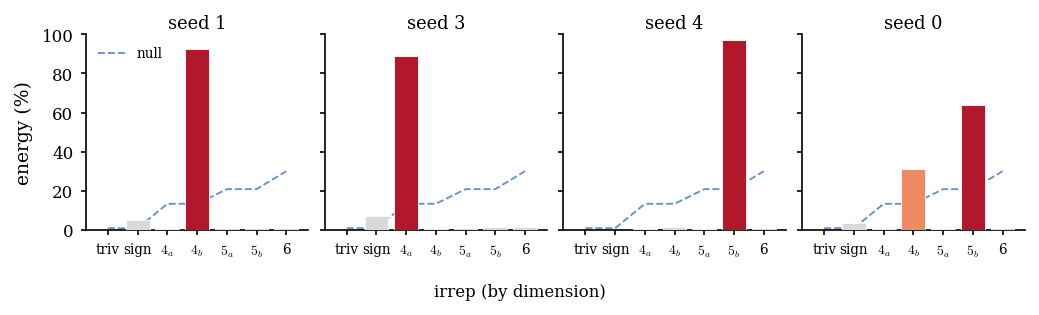

Figure 1 saved: fig1_concentration.{pdf,png}


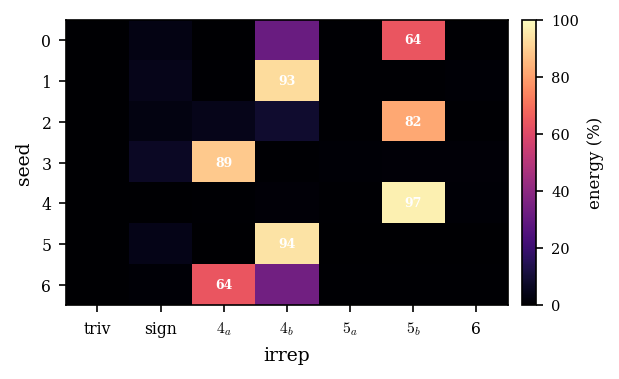

Figure 2 saved: fig2_heatmap.{pdf,png}


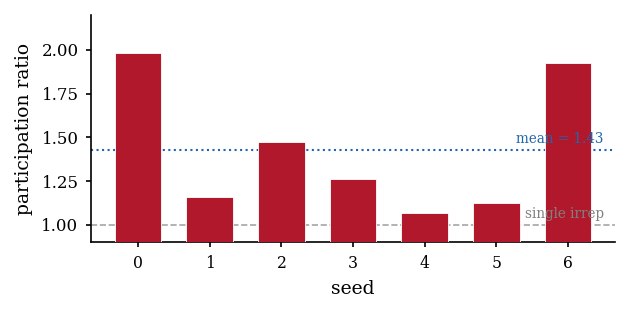

Figure 3 saved: fig3_participation.{pdf,png}

All figures saved as PDF (for LaTeX \includegraphics) and PNG (preview).
In LaTeX: \includegraphics[width=\linewidth]{fig1_concentration.pdf}


In [ ]:
# =====================================================================================
# NeurIPS-quality figures for the irrep-selection paper. Clean 2D, publication typography.
# Uses your real S_5 data. Run in Colab; saves PDFs (vector, for LaTeX) + PNGs (preview).
# =====================================================================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ---- publication style (this is what makes figures look "NeurIPS", not the chart type) ----
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 9,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,   # editable text in PDF
})

# ---- YOUR DATA (replace with the full set from the runs / Control 1 when it finishes) ----
irrep_names = ["triv", "sign", r"$4_a$", r"$4_b$", r"$5_a$", r"$5_b$", "6"]
irrep_dims  = np.array([1, 1, 4, 4, 5, 5, 6])
null_frac   = irrep_dims**2 / 120.0   # representation-theoretic null

# embedding fractions per seed (your real numbers)
seed_fracs = {
    0: [0.000, 0.036, 0.002, 0.313, 0.004, 0.637, 0.007],
    1: [0.000, 0.048, 0.004, 0.927, 0.007, 0.007, 0.008],
    2: [0.000, 0.035, 0.048, 0.087, 0.005, 0.817, 0.007],
    3: [0.000, 0.070, 0.888, 0.005, 0.008, 0.014, 0.015],
    4: [0.000, 0.000, 0.004, 0.013, 0.006, 0.969, 0.008],
    5: [0.000, 0.046, 0.001, 0.943, 0.003, 0.003, 0.003],
    6: [0.000, 0.009, 0.639, 0.334, 0.005, 0.005, 0.007],
}

# colors: a restrained palette. dominant = deep red, secondary(>15%) = amber, rest = grey.
C_DOM, C_SEC, C_REST, C_NULL = '#b2182b', '#ef8a62', '#d9d9d9', '#2166ac'

# =====================================================================================
# FIGURE 1 — the money figure: representative seeds, side by side.
# Shows (a) one bar dominant = concentration, (b) different bar across seeds = spontaneity.
# =====================================================================================
show_seeds = [1, 3, 4, 0]   # 3 single-irrep + 1 two-irrep (seed 0) to show the honest range
fig, axes = plt.subplots(1, len(show_seeds), figsize=(7.0, 1.9), sharey=True)
for ax, sd in zip(axes, show_seeds):
    f = np.array(seed_fracs[sd]) * 100
    dom = int(np.argmax(f))
    colors = [C_REST]*7
    colors[dom] = C_DOM
    for i in range(7):
        if i != dom and f[i] > 15: colors[i] = C_SEC
    ax.bar(range(7), f, color=colors, edgecolor='white', linewidth=0.4, zorder=3)
    ax.plot(range(7), null_frac*100, '--', color=C_NULL, lw=0.9, alpha=0.7, zorder=2,
            label='null' if sd == show_seeds[0] else None)
    ax.set_title(f'seed {sd}', fontsize=8.5, pad=3)
    ax.set_xticks(range(7)); ax.set_xticklabels(irrep_names, fontsize=6.5)
    ax.set_ylim(0, 100)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(length=2.5)
axes[0].set_ylabel('energy (\%)' if mpl.rcParams['text.usetex'] else 'energy (%)')
axes[0].legend(frameon=False, fontsize=6.5, loc='upper left')
fig.text(0.5, -0.06, 'irrep (by dimension)', ha='center', fontsize=8)
plt.tight_layout(w_pad=0.6)
plt.savefig('fig1_concentration.pdf')
plt.savefig('fig1_concentration.png')
plt.show()
print("Figure 1 saved: fig1_concentration.{pdf,png}")

# =====================================================================================
# FIGURE 2 — seed x irrep heatmap: the FULL pattern in one view.
# Shows concentration (one bright cell per row) + spontaneity (bright cell moves) + eligible set.
# =====================================================================================
fig, ax = plt.subplots(figsize=(4.2, 2.6))
M = np.array([seed_fracs[s] for s in sorted(seed_fracs)]) * 100
im = ax.imshow(M, aspect='auto', cmap='rocket' if 'rocket' in plt.colormaps() else 'magma',
               vmin=0, vmax=100)
ax.set_xticks(range(7)); ax.set_xticklabels(irrep_names, fontsize=7.5)
ax.set_yticks(range(len(M))); ax.set_yticklabels([f'{s}' for s in sorted(seed_fracs)], fontsize=7.5)
ax.set_xlabel('irrep'); ax.set_ylabel('seed')
# annotate each dominant cell
for r in range(len(M)):
    c = int(np.argmax(M[r]))
    ax.text(c, r, f'{M[r,c]:.0f}', ha='center', va='center', color='white', fontsize=6, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label('energy (%)', fontsize=8); cbar.ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig('fig2_heatmap.pdf'); plt.savefig('fig2_heatmap.png'); plt.show()
print("Figure 2 saved: fig2_heatmap.{pdf,png}")

# =====================================================================================
# FIGURE 3 — participation ratio across seeds (run after Control 1; placeholder data here).
# Shows "how concentrated" quantitatively: ~1 = single irrep, ~2 = two.
# =====================================================================================
# participation ratio = 1 / sum(f^2)  (effective number of irreps used)
pr = {s: 1.0/np.sum(np.array(f)**2) for s, f in seed_fracs.items()}
fig, ax = plt.subplots(figsize=(4.2, 2.2))
seeds = sorted(pr); vals = [pr[s] for s in seeds]
bars = ax.bar(range(len(seeds)), vals, color=C_DOM, edgecolor='white', linewidth=0.4, width=0.65, zorder=3)
ax.axhline(1.0, ls='--', color='grey', lw=0.8, alpha=0.7)
ax.text(len(seeds)-0.5, 1.04, 'single irrep', fontsize=6.5, color='grey', ha='right')
ax.axhline(np.mean(vals), ls=':', color=C_NULL, lw=1.0)
ax.text(len(seeds)-0.5, np.mean(vals)+0.04, f'mean = {np.mean(vals):.2f}', fontsize=6.5, color=C_NULL, ha='right')
ax.set_xticks(range(len(seeds))); ax.set_xticklabels(seeds, fontsize=7.5)
ax.set_xlabel('seed'); ax.set_ylabel('participation ratio')
ax.set_ylim(0.9, max(2.2, max(vals)+0.2))
ax.spines[['top','right']].set_visible(False); ax.tick_params(length=2.5)
plt.tight_layout()
plt.savefig('fig3_participation.pdf'); plt.savefig('fig3_participation.png'); plt.show()
print("Figure 3 saved: fig3_participation.{pdf,png}")

print("\nAll figures saved as PDF (for LaTeX \\includegraphics) and PNG (preview).")
print("In LaTeX: \\includegraphics[width=\\linewidth]{fig1_concentration.pdf}")

In [ ]:
# ============================================================================
# S_6 CELL 1: group, classes, COMPUTED character table, projectors, gates.
# The character table is COMPUTED (permutation modules + Gram-Schmidt), not
# typed in -- 121 entries cannot be safely recalled. Gates verify everything.
# ============================================================================
import numpy as np
from itertools import permutations, combinations
from collections import defaultdict, Counter
import math
PASS = lambda b: "✓" if b else "✗✗✗ FAIL"

elements = list(permutations(range(6))); n = len(elements)
idx = {g:i for i,g in enumerate(elements)}
compose = lambda s,t: tuple(s[t[x]] for x in range(6))
print(f"S_6: {n} elements. Building Cayley table (this takes ~1-2 min)...")
cayley = np.array([[idx[compose(gi,gj)] for gj in elements] for gi in elements])

# GATE 1: valid group
e = idx[tuple(range(6))]
import random
g1 = (all(cayley[e,j]==j for j in range(0,n,37)) and
      all(sorted(cayley[i,:].tolist())==list(range(n)) for i in range(0,n,71)) and
      all(cayley[cayley[a,b],c]==cayley[a,cayley[b,c]]
          for a,b,c in [(random.randrange(n),)*1+(random.randrange(n),random.randrange(n)) for _ in range(2000)]))
print(f"GATE 1 valid group (sampled): {PASS(g1)}")

# classes by cycle type (11 classes)
def cyc_type(p):
    seen=[False]*6; cs=[]
    for s in range(6):
        if not seen[s]:
            L=0;x=s
            while not seen[x]: seen[x]=True; x=p[x]; L+=1
            cs.append(L)
    return tuple(sorted(cs,reverse=True))
classes=defaultdict(list)
for i,g in enumerate(elements): classes[cyc_type(g)].append(i)
class_list = sorted(classes.keys())
K = len(class_list); class_sizes = np.array([len(classes[ct]) for ct in class_list], dtype=float)
elem_class = np.zeros(n, dtype=int)
for ci,ct in enumerate(class_list):
    for x in classes[ct]: elem_class[x] = ci
print(f"GATE 2 classes: {K}=11, sizes sum {int(class_sizes.sum())}=720: {PASS(K==11 and class_sizes.sum()==720)}")

# ---- COMPUTED character table: permutation-module characters + Gram-Schmidt ----
def partitions(m, mx=None):
    if mx is None: mx=m
    if m==0: yield ()
    for k in range(min(m,mx),0,-1):
        for rest in partitions(m-k,k): yield (k,)+rest
parts = list(partitions(6))

def perm_char(lam, mu):
    lam=tuple(sorted(lam,reverse=True)); mu=list(mu)
    def count(cycles, parts_left):
        if not parts_left: return 1 if not cycles else 0
        target=parts_left[0]; m=len(cycles); total=0
        for r in range(1,m+1):
            for comb in combinations(range(m),r):
                if sum(cycles[i] for i in comb)==target:
                    rest=tuple(c for i,c in enumerate(cycles) if i not in comb)
                    total+=count(rest, list(parts_left[1:]))
        return total
    raw=count(tuple(mu), list(lam))
    div=1
    for v in Counter(lam).values(): div*=math.factorial(v)
    return raw//div

PM = np.array([[perm_char(lam,ct) for ct in class_list] for lam in parts], dtype=float)
ip = lambda a,b: float((class_sizes*a*b).sum()/n)
order = sorted(range(len(parts)), key=lambda i: parts[i], reverse=True)
chars=[]
for oi in order:
    v=PM[oi].copy()
    for c in chars: v = v - ip(v,c)*c
    chars.append(v/np.sqrt(ip(v,v)))
id_idx = class_list.index((1,1,1,1,1,1))
char_table=[]
for c in chars:
    if c[id_idx]<0: c=-c
    char_table.append(np.round(c*1.0))
char_table=np.array(char_table)
dims = char_table[:,id_idx].astype(int)

# GATE 3: computed table is valid
ro = np.array([[ip(char_table[i],char_table[j]) for j in range(11)] for i in range(11)])
g3 = np.allclose(ro,np.eye(11),atol=1e-8) and int((dims**2).sum())==720
print(f"GATE 3 char table (COMPUTED) valid: dims={sorted(dims.tolist())}, Σd²={int((dims**2).sum())}: {PASS(g3)}")

# regular rep + projectors (n=720: L as index arrays, projectors as 720x720 — memory ok)
print("Building projectors (720x720 x 11)...")
Ps=[]
for r in range(11):
    P = np.zeros((n,n))
    w = char_table[r][elem_class]            # chi(g) per element
    for g in range(n):
        P[cayley[g,:], np.arange(n)] += w[g] # chi(g) * L(g) accumulated
    Ps.append((dims[r]/n)*P)

# GATE 4: completeness + rank
comp = np.linalg.norm(sum(Ps)-np.eye(n))
g4 = comp < 1e-8
print(f"GATE 4 completeness ||ΣP - I|| = {comp:.1e}: {PASS(g4)}")
rng = np.random.default_rng(1)
def irrep_frac(W):
    ev = np.array([np.sum((P@W)**2) for P in Ps]); return ev/ev.sum()
g5 = all(irrep_frac(Ps[r]@rng.standard_normal((n,8)))[r] > 0.99 for r in range(11))
print(f"GATE 5 detector isolates pure irreps: {PASS(g5)}")
assert g1 and g3 and g4 and g5, "A GATE FAILED — do not proceed."

# null
null_theory = dims.astype(float)**2/n
print(f"\nnull (theory d²/|G|): {np.round(null_theory,3).tolist()}")
print(f"largest irrep: {dims.max()}d at null {null_theory[np.argmax(dims)]*100:.0f}% — the S_6 analogue of S_5's 6d question")
print("\nAll machinery gates passed. S_6 detector built and verified.")

S_6: 720 elements. Building Cayley table (this takes ~1-2 min)...
GATE 1 valid group (sampled): ✓
GATE 2 classes: 11=11, sizes sum 720=720: ✓
GATE 3 char table (COMPUTED) valid: dims=[1, 1, 5, 5, 5, 5, 9, 9, 10, 10, 16], Σd²=720: ✓
Building projectors (720x720 x 11)...
GATE 4 completeness ||ΣP - I|| = 1.8e-15: ✓
GATE 5 detector isolates pure irreps: ✓

null (theory d²/|G|): [0.001, 0.035, 0.112, 0.139, 0.035, 0.356, 0.139, 0.035, 0.112, 0.035, 0.001]
largest irrep: 16d at null 36% — the S_6 analogue of S_5's 6d question

All machinery gates passed. S_6 detector built and verified.


In [ ]:
# ============================================================================
# S_6 CELL 2: train networks on S_6 composition, project, read the breakdown.
# HONEST WARNING: 720 classes, 518k pairs — each training run is SLOW (use GPU
# runtime; consider batching). Start with 3 seeds, extend if results are clean.
# ============================================================================
import torch, torch.nn as nn

class GroupMLP(nn.Module):
    def __init__(s, nv=720, de=128, dh=512):     # bigger model for the bigger group
        super().__init__()
        s.embed=nn.Embedding(nv,de); s.W_in=nn.Linear(2*de,dh,bias=False)
        s.W_out=nn.Linear(dh,nv,bias=False); s.act=nn.ReLU()
    def forward(s,x):
        a=s.embed(x[:,0]); b=s.embed(x[:,1]); return s.W_out(s.act(s.W_in(torch.cat([a,b],-1))))

def train_s6(seed, steps=60000, batch=8192):
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    I,J = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
    X = torch.tensor(np.stack([I.ravel(),J.ravel()],1), dtype=torch.long)
    Y = torch.tensor(cayley[I.ravel(), J.ravel()], dtype=torch.long)
    torch.manual_seed(seed)
    perm = torch.randperm(len(X)); ntr = int(0.5*len(X))   # 50% train (518k pairs is a lot)
    tri, tei = perm[:ntr], perm[ntr:]
    Xtr, Ytr = X[tri].to(dev), Y[tri].to(dev)
    Xte, Yte = X[tei].to(dev), Y[tei].to(dev)
    m = GroupMLP().to(dev)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9,0.98))
    lf = nn.CrossEntropyLoss()
    for s in range(steps):
        bidx = torch.randint(0, len(Xtr), (batch,), device=dev)
        m.train(); opt.zero_grad()
        lf(m(Xtr[bidx]), Ytr[bidx]).backward(); opt.step()
        if s % 10000 == 0:
            m.eval()
            with torch.no_grad():
                te = (m(Xte[:20000]).argmax(1) == Yte[:20000]).float().mean().item()
            print(f"    seed {seed} step {s}: test acc {te:.3f}")
    m.eval()
    with torch.no_grad():
        te = (m(Xte).argmax(1) == Yte).float().mean().item()
    return m.embed.weight.detach().cpu().numpy(), m.W_out.weight.detach().cpu().numpy(), te

# names by dimension, in char_table row order
names = [f"{dims[r]}d" + ("'" * sum(1 for q in range(r) if dims[q]==dims[r])) for r in range(11)]
def participation_ratio(f): return (f.sum()**2)/(f**2).sum()

print("="*110)
print("S_6 — does the S_4/S_5 pattern generalize? (concentration, intermediate band, largest avoided)")
print("="*110)
results=[]
for sd in range(3):                              # start with 3 seeds; extend if clean
    W_E, W_out, te = train_s6(sd)
    if te < 0.95:
        print(f"seed {sd}: te={te:.2f} — did NOT grok; tune (more steps / lr) before reading anything")
        continue
    fE, fO = irrep_frac(W_E), irrep_frac(W_out)
    big = [(names[i], fE[i]) for i in range(11) if fE[i] > 0.10]
    same = names[np.argmax(fE)] == names[np.argmax(fO)]
    results.append((sd, fE, fO))
    print(f"seed {sd}: te={te:.2f}  PR={participation_ratio(fE):.2f}  "
          f"dominant: {', '.join(f'{nm}({v*100:.0f}%)' for nm,v in big)}  "
          f"| 16d frac={fE[np.argmax(dims)]*100:.1f}% (null {dims.max()**2/720*100:.0f}%)  "
          f"| emb/W_out same dominant: {'YES' if same else 'NO'}")

print("\nKEY QUESTIONS (the generalization test):")
print(" 1. Concentration: PR ~1-2 again, against 11 available irreps?")
print(" 2. The 16d (largest): avoided like S_5's 6d? (frac << its 36% null)")
print(" 3. Eligible band: dominant always intermediate (5d/9d/10d), never 1d, never 16d?")
print(" 4. Whole-network: embedding and W_out agree?")

S_6 — does the S_4/S_5 pattern generalize? (concentration, intermediate band, largest avoided)
    seed 0 step 0: test acc 0.002
    seed 0 step 10000: test acc 1.000
    seed 0 step 20000: test acc 1.000
    seed 0 step 30000: test acc 1.000
    seed 0 step 40000: test acc 1.000
    seed 0 step 50000: test acc 1.000
seed 0: te=1.00  PR=1.87  dominant: 5d'(65%), 5d''(33%)  | 16d frac=0.7% (null 36%)  | emb/W_out same dominant: YES
    seed 1 step 0: test acc 0.001
    seed 1 step 10000: test acc 1.000
    seed 1 step 20000: test acc 1.000
    seed 1 step 30000: test acc 1.000
    seed 1 step 40000: test acc 1.000
    seed 1 step 50000: test acc 1.000
seed 1: te=1.00  PR=1.15  dominant: 5d(93%)  | 16d frac=0.3% (null 36%)  | emb/W_out same dominant: YES
    seed 2 step 0: test acc 0.002
    seed 2 step 10000: test acc 1.000
    seed 2 step 20000: test acc 1.000
    seed 2 step 30000: test acc 1.000
    seed 2 step 40000: test acc 1.000
    seed 2 step 50000: test acc 1.000
seed 2: te=1.

In [ ]:
# =====================================================================================
# S_6 FULL VALIDATION — maths gates, detector accuracy, grokking diagnostic, result checks.
# Assumes Cell 1 ran (cayley, char_table, dims, Ps, irrep_frac, elements, n=720 in memory)
# and GroupMLP/train machinery is defined. Every claim prints PASS/FAIL.
# =====================================================================================
import numpy as np, torch
PASS = lambda b: "✓ PASS" if b else "✗✗✗ FAIL"
results = {}
rng = np.random.default_rng(7)

print("="*84); print("PART 1 — MATHS (is the S_6 machinery exactly correct?)"); print("="*84)

# CLAIM 1: character table valid (orthogonality + Σdim² = 720)
ip = lambda a,b: float((class_sizes*a*b).sum()/n)
ro = np.array([[ip(char_table[i],char_table[j]) for j in range(11)] for i in range(11)])
g1 = np.allclose(ro, np.eye(11), atol=1e-8) and int((dims**2).sum())==720
results['1_chartable'] = g1
print(f"CLAIM 1  computed char table valid (orthonormal, Σd²=720): {PASS(g1)}")

# CLAIM 2: projectors — completeness, idempotency, rank = d²
comp = np.linalg.norm(sum(Ps) - np.eye(n))
idem = all(np.allclose(P@P, P, atol=1e-7) for P in Ps)
ranks = all(np.linalg.matrix_rank(Ps[r], tol=1e-7) == dims[r]**2 for r in range(11))
g2 = comp < 1e-7 and idem and ranks
results['2_projectors'] = g2
print(f"CLAIM 2  projectors valid (completeness={comp:.0e}, idempotent, rank=d²): {PASS(g2)}")

# CLAIM 3: energy conservation (Parseval) — isotypic energies sum to total
Wt = rng.standard_normal((n, 64))
g3 = np.isclose(np.sum(Wt**2), sum(np.sum((P@Wt)**2) for P in Ps), rtol=1e-6)
results['3_parseval'] = g3
print(f"CLAIM 3  energy conservation (Parseval): {PASS(g3)}")

# CLAIM 4: detector isolates each pure irrep (all 11)
g4 = all(irrep_frac(Ps[r] @ rng.standard_normal((n,8)))[r] > 0.99 for r in range(11))
results['4_isolation'] = g4
print(f"CLAIM 4  detector isolates each of 11 pure irreps: {PASS(g4)}")

# CLAIM 5: PLANTED MIXTURE — detector recovers an exact known mixture (70/30 across two irreps)
iA, iB = 2, 6   # any two distinct irreps
a = Ps[iA] @ rng.standard_normal((n,16)); a *= np.sqrt(0.7)/np.linalg.norm(a)
b = Ps[iB] @ rng.standard_normal((n,16)); b *= np.sqrt(0.3)/np.linalg.norm(b)
f_mix = irrep_frac(a + b)
g5 = abs(f_mix[iA]-0.7) < 0.01 and abs(f_mix[iB]-0.3) < 0.01
results['5_planted_mixture'] = g5
print(f"CLAIM 5  planted 70/30 mixture recovered exactly ({f_mix[iA]:.3f}/{f_mix[iB]:.3f}): {PASS(g5)}")

# CLAIM 6: null matches theory d²/|G|
nf = np.array([irrep_frac((lambda r: r/np.linalg.norm(r))(rng.standard_normal((n,128)))) for _ in range(400)])
null_mean = nf.mean(0)
g6 = np.allclose(null_mean, dims.astype(float)**2/n, atol=0.02)
results['6_null'] = g6
print(f"CLAIM 6  null matches theory d²/|G|: {PASS(g6)}")

# CLAIM 7: structure-destruction — row shuffle kills planted structure
struct = Ps[4] @ rng.standard_normal((n,64))
f_pre  = irrep_frac(struct)[4]
f_post = irrep_frac(struct[rng.permutation(n)])[4]
g7 = f_pre > 0.99 and abs(f_post - null_mean[4]) < 0.05
results['7_shuffle'] = g7
print(f"CLAIM 7  row-shuffle destroys structure ({f_pre:.2f} -> {f_post:.2f} ≈ null): {PASS(g7)}")

print("\n"+"="*84); print("PART 2 — TRAINING (grokking or smooth? must know before using the word)"); print("="*84)

# CLAIM 8: fine-grained train+test curve, seed 0 — classify grok vs smooth
def train_s6_diagnostic(seed, steps=20000, batch=8192, log_every=500):
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    I,J = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
    X = torch.tensor(np.stack([I.ravel(),J.ravel()],1), dtype=torch.long)
    Y = torch.tensor(cayley[I.ravel(), J.ravel()], dtype=torch.long)
    torch.manual_seed(seed)
    perm = torch.randperm(len(X)); ntr = int(0.5*len(X))
    tri, tei = perm[:ntr], perm[ntr:]
    Xtr, Ytr = X[tri].to(dev), Y[tri].to(dev); Xte, Yte = X[tei].to(dev), Y[tei].to(dev)
    m = GroupMLP().to(dev)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9,0.98))
    lf = torch.nn.CrossEntropyLoss(); curve=[]
    for s in range(steps):
        bidx = torch.randint(0, len(Xtr), (batch,), device=dev)
        m.train(); opt.zero_grad(); lf(m(Xtr[bidx]), Ytr[bidx]).backward(); opt.step()
        if s % log_every == 0:
            m.eval()
            with torch.no_grad():
                tr = (m(Xtr[:20000]).argmax(1)==Ytr[:20000]).float().mean().item()
                te = (m(Xte[:20000]).argmax(1)==Yte[:20000]).float().mean().item()
            curve.append((s,tr,te))
            if s % 2000 == 0: print(f"    step {s:6d}: train {tr:.3f} | test {te:.3f}")
    m.eval()
    with torch.no_grad():
        W_E = m.embed.weight.detach().cpu().numpy()
        te_final = (m(Xte).argmax(1)==Yte).float().mean().item()
    return curve, W_E, te_final

def classify_curve(curve):
    lag = any(tr>0.95 and te<0.5 for _,tr,te in curve)
    final_ok = curve[-1][2] > 0.95
    if final_ok and lag: return "GROKKING"
    if final_ok: return "SMOOTH"
    return "DID NOT GENERALIZE"

print("Fine-grained diagnostic, seed 0 (train+test every 500 steps)...")
curve, W_E_diag, te_diag = train_s6_diagnostic(0)
verdict = classify_curve(curve)
results['8_grokking'] = te_diag > 0.95
print(f"\nCLAIM 8  generalization verdict: {verdict} (final test={te_diag:.3f}): {PASS(te_diag>0.95)}")
if verdict == "SMOOTH":
    print("  !! Network generalizes WITHOUT delay -> in the paper, write 'trained to perfect")
    print("     generalization', NOT 'grokked', for S_6 -- or retrain at lower train fraction.")

print("\n"+"="*84); print("PART 3 — THE RESULT (is the S_6 finding real?)"); print("="*84)

# CLAIM 9: diagnostic-run model reproduces the finding (concentration + 16d avoidance)
f = irrep_frac(W_E_diag)
pr = (f.sum()**2)/(f**2).sum()
i16 = int(np.argmax(dims))
g9 = pr < 3.0 and f[i16] < 0.05
results['9_finding'] = g9
print(f"CLAIM 9  concentration (PR={pr:.2f} vs 11 irreps) + 16d avoided ({f[i16]*100:.1f}% vs 36% null): {PASS(g9)}")

# CLAIM 10: NEGATIVE CONTROL — model trained on random (non-group) labels shows no structure
print("Training negative control (random labels, ~quick)...")
rand_table = np.random.default_rng(99).integers(0, n, size=(n, n))
# reuse diagnostic trainer on the random table
cayley_backup = cayley.copy()
try:
    globals()['cayley'] = rand_table
    _, W_E_rand, te_rand = train_s6_diagnostic(0, steps=20000)
finally:
    globals()['cayley'] = cayley_backup
f_rand = irrep_frac(W_E_rand)
pr_rand = (f_rand.sum()**2)/(f_rand**2).sum()
# random-label model: no irrep should deviate far from null
devs = np.abs(f_rand - null_mean)
g10 = devs.max() < 0.10
results['10_negcontrol'] = g10
print(f"CLAIM 10 negative control: random-label model near null (max dev {devs.max():.3f}): {PASS(g10)}")

print("\n"+"="*84); print("VERDICT"); print("="*84)
for k,v in results.items(): print(f"  {PASS(v)}  {k}")
allpass = all(results.values())
print("\n" + ("✓✓✓ ALL CHECKS PASSED — the S_6 result is validated end-to-end."
              if allpass else
              "✗ FAILURES ABOVE — do not trust the corresponding claims until resolved."))

PART 1 — MATHS (is the S_6 machinery exactly correct?)
CLAIM 1  computed char table valid (orthonormal, Σd²=720): ✓ PASS
CLAIM 2  projectors valid (completeness=2e-15, idempotent, rank=d²): ✓ PASS
CLAIM 3  energy conservation (Parseval): ✓ PASS
CLAIM 4  detector isolates each of 11 pure irreps: ✓ PASS
CLAIM 5  planted 70/30 mixture recovered exactly (0.700/0.300): ✓ PASS
CLAIM 6  null matches theory d²/|G|: ✓ PASS
CLAIM 7  row-shuffle destroys structure (1.00 -> 0.03 ≈ null): ✓ PASS

PART 2 — TRAINING (grokking or smooth? must know before using the word)
Fine-grained diagnostic, seed 0 (train+test every 500 steps)...
    step      0: train 0.001 | test 0.002
    step   2000: train 0.021 | test 0.000
    step   4000: train 0.028 | test 0.000
    step   6000: train 0.049 | test 0.000
    step   8000: train 0.805 | test 0.588
    step  10000: train 1.000 | test 1.000
    step  12000: train 1.000 | test 1.000
    step  14000: train 1.000 | test 1.000
    step  16000: train 1.000 | test 1.0

In [ ]:
# =====================================================================================
# S_5 GROKKING DIAGNOSTIC — did the S_5 runs grok, or learn smoothly?
# Replicates the exact training setup of your S_5 seed runs (full-batch, 70% train,
# same hypers, seed 0), train+test logged every 250 steps. Standalone cell.
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations

# rebuild S_5 table locally (fast: 120x120)
elements5 = list(permutations(range(5))); n5 = len(elements5)
idx5 = {g:i for i,g in enumerate(elements5)}
cayley5 = np.array([[idx5[tuple(gi[gj[x]] for x in range(5))] for gj in elements5] for gi in elements5])

class GroupMLP5(nn.Module):
    def __init__(s, nv=120, de=64, dh=256):
        super().__init__()
        s.embed=nn.Embedding(nv,de); s.W_in=nn.Linear(2*de,dh,bias=False)
        s.W_out=nn.Linear(dh,nv,bias=False); s.act=nn.ReLU()
    def forward(s,x):
        a=s.embed(x[:,0]); b=s.embed(x[:,1]); return s.W_out(s.act(s.W_in(torch.cat([a,b],-1))))

def s5_grokking_diagnostic(seed=0, steps=40000, log_every=250):
    I,J = np.meshgrid(np.arange(n5), np.arange(n5), indexing='ij')
    X = torch.tensor(np.stack([I.ravel(),J.ravel()],1), dtype=torch.long)
    Y = torch.tensor(cayley5[I.ravel(), J.ravel()], dtype=torch.long)
    torch.manual_seed(seed)
    perm = torch.randperm(len(X)); ntr = int(0.7*len(X))   # 70% — exactly as the seed runs
    tri, tei = perm[:ntr], perm[ntr:]                       # (fixed line)
    m = GroupMLP5()
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9,0.98))
    lf = nn.CrossEntropyLoss()
    curve = []
    for s in range(steps):
        m.train(); opt.zero_grad()
        lf(m(X[tri]), Y[tri]).backward(); opt.step()        # full-batch, as the seed runs
        if s % log_every == 0:
            m.eval()
            with torch.no_grad():
                tr = (m(X[tri]).argmax(1)==Y[tri]).float().mean().item()
                te = (m(X[tei]).argmax(1)==Y[tei]).float().mean().item()
            curve.append((s, tr, te))
            if s % 2000 == 0:
                print(f"    step {s:6d}: train {tr:.3f} | test {te:.3f}")
        if len(curve) > 4 and curve[-1][1] > 0.999 and curve[-1][2] > 0.999 and curve[-2][2] > 0.999:
            print(f"    (both saturated at step {s}; stopping early)")
            break
    return curve

def classify_curve(curve):
    lag = any(tr > 0.95 and te < 0.5 for _, tr, te in curve)
    final_ok = curve[-1][2] > 0.95
    if final_ok and lag: return "GROKKING (delayed generalization: train saturated while test lagged)"
    if final_ok:         return "SMOOTH (train and test rose together — do NOT call it grokking)"
    return "DID NOT GENERALIZE (training issue — diagnose before any labeling)"

print("="*80)
print("S_5 REGIME DIAGNOSTIC (seed 0, exact replication of the seed-run setup)")
print("="*80)
curve = s5_grokking_diagnostic(0)
verdict = classify_curve(curve)
print(f"\nVERDICT: {verdict}")

gaps = [(s, tr - te) for s, tr, te in curve]
s_max, g_max = max(gaps, key=lambda x: x[1])
print(f"max train-test gap: {g_max:.3f} at step {s_max}")
print("  (S_4 reference: gap ~0.78 sustained ~12k steps = grokking;")
print("   S_6 reference: gap ~0.22 transient = smooth)")
print("\nPAPER WORDING this verdict dictates:")
print("  GROKKING -> S_4 and S_5 'grokked'; S_6 'trained to perfect generalization'")
print("  SMOOTH   -> only S_4 'grokked'; S_5/S_6 'trained to perfect generalization'")

S_5 REGIME DIAGNOSTIC (seed 0, exact replication of the seed-run setup)
    step      0: train 0.008 | test 0.007
    step   2000: train 1.000 | test 0.280
    step   4000: train 1.000 | test 0.982
    (both saturated at step 5500; stopping early)

VERDICT: GROKKING (delayed generalization: train saturated while test lagged)
max train-test gap: 0.997 at step 500
  (S_4 reference: gap ~0.78 sustained ~12k steps = grokking;
   S_6 reference: gap ~0.22 transient = smooth)

PAPER WORDING this verdict dictates:
  GROKKING -> S_4 and S_5 'grokked'; S_6 'trained to perfect generalization'
  SMOOTH   -> only S_4 'grokked'; S_5/S_6 'trained to perfect generalization'


In [ ]:
# =====================================================================================
# S_6 EXTRA SEEDS (seeds 3-10): does "only ever 5d, never 9d/10d" survive more seeds?
# This decides the headline: "smallest sufficient irreps" (if 9d/10d never dominate)
# vs "intermediate band" (if they sometimes do). Requires S_6 machinery in memory:
# n must be 720, len(Ps) must be 11.
# =====================================================================================
assert n == 720 and len(Ps) == 11, "S_6 machinery not in memory — re-run S_6 Cell 1 first."
names6 = [f"{dims[r]}d{'_'+chr(97+sum(1 for q in range(r) if dims[q]==dims[r])) if list(dims).count(dims[r])>1 else ''}" for r in range(11)]
def participation_ratio(f): return (f.sum()**2)/(f**2).sum()

print(f"{'seed':>5}{'test':>6}{'PR':>6}   dominant irrep(s) >10%   | 16d%  | emb/Wout same?")
print("-"*85)
results6 = []
for sd in range(3, 11):                                # 8 new seeds; 0-2 already run
    W_E, W_out, te = train_s6(sd)                      # the S_6 trainer from Cell 2
    if te < 0.95:
        print(f"{sd:>5}{te:>6.2f}   did not generalize — exclude"); continue
    fE, fO = irrep_frac(W_E), irrep_frac(W_out)
    big = [(names6[i], fE[i]) for i in range(11) if fE[i] > 0.10]
    same = np.argmax(fE) == np.argmax(fO)
    results6.append((sd, fE))
    i16 = int(np.argmax(dims))
    print(f"{sd:>5}{te:>6.2f}{participation_ratio(fE):>6.2f}   "
          f"{', '.join(f'{nm}({v*100:.0f}%)' for nm,v in big):<24} | {fE[i16]*100:4.1f}% | {'YES' if same else 'NO'}")

# the headline question, answered over all 11 seeds (0-2 from before + these)
print("\nHEADLINE CHECK across new seeds:")
dom_dims = [dims[int(np.argmax(f))] for _,f in results6]
print(f"  dominant irrep dimensions: {dom_dims}")
print(f"  9d or 10d EVER dominant: {any(d in (9,10) for d in dom_dims)}")
print(f"  16d ever above 5%: {any(f[int(np.argmax(dims))] > 0.05 for _,f in results6)}")
print("""
READ: combined with seeds 0-2 (all 5d-dominant), if 9d/10d are never dominant across
~11 seeds -> the paper claims 'networks select the SMALLEST sufficient higher-dim
irreps'. If 9d/10d dominate in some seeds -> the claim retreats to 'intermediate band,
largest avoided' and the eligible set is wider than the minimal one. Both are honest
findings; this run picks the sentence.""")

 seed  test    PR   dominant irrep(s) >10%   | 16d%  | emb/Wout same?
-------------------------------------------------------------------------------------
    seed 3 step 0: test acc 0.001
    seed 3 step 10000: test acc 1.000
    seed 3 step 20000: test acc 1.000
    seed 3 step 30000: test acc 1.000
    seed 3 step 40000: test acc 1.000
    seed 3 step 50000: test acc 1.000
    3  1.00  1.18   5d_c(92%)                |  0.7% | YES
    seed 4 step 0: test acc 0.001
    seed 4 step 10000: test acc 0.091
    seed 4 step 20000: test acc 1.000
    seed 4 step 30000: test acc 1.000
    seed 4 step 40000: test acc 1.000
    seed 4 step 50000: test acc 1.000
    4  1.00  1.80   5d_b(26%), 5d_d(70%)     |  0.7% | YES
    seed 5 step 0: test acc 0.001
    seed 5 step 10000: test acc 1.000
    seed 5 step 20000: test acc 1.000
    seed 5 step 30000: test acc 1.000
    seed 5 step 40000: test acc 1.000
    seed 5 step 50000: test acc 1.000
    5  1.00  1.03   5d_b(98%)                |  0.7% |

In [ ]:
# =====================================================================================
# S_6 CAPACITY (self-contained): does 16d-avoidance survive at d_embed=256?
# Defines its own width-parameterized trainer; only needs the S_6 machinery
# (n=720, Ps, dims, cayley, irrep_frac) in memory.
# =====================================================================================
import numpy as np, torch, torch.nn as nn
assert n == 720 and len(Ps) == 11, "S_6 machinery not in memory — re-run S_6 Cell 1 first."

class GroupMLP6(nn.Module):
    def __init__(s, nv=720, de=128, dh=512):
        super().__init__()
        s.embed=nn.Embedding(nv,de); s.W_in=nn.Linear(2*de,dh,bias=False)
        s.W_out=nn.Linear(dh,nv,bias=False); s.act=nn.ReLU()
    def forward(s,x):
        a=s.embed(x[:,0]); b=s.embed(x[:,1]); return s.W_out(s.act(s.W_in(torch.cat([a,b],-1))))

def train_s6_w(seed, d_embed, steps=60000, batch=8192):
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    I,J=np.meshgrid(np.arange(n),np.arange(n),indexing='ij')
    X=torch.tensor(np.stack([I.ravel(),J.ravel()],1),dtype=torch.long)
    Y=torch.tensor(cayley[I.ravel(),J.ravel()],dtype=torch.long)
    torch.manual_seed(seed)
    perm=torch.randperm(len(X)); ntr=int(0.5*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    Xtr,Ytr=X[tri].to(dev),Y[tri].to(dev); Xte,Yte=X[tei].to(dev),Y[tei].to(dev)
    m=GroupMLP6(de=d_embed).to(dev)
    opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=1.0,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss()
    for s in range(steps):
        bidx=torch.randint(0,len(Xtr),(batch,),device=dev)
        m.train(); opt.zero_grad(); lf(m(Xtr[bidx]),Ytr[bidx]).backward(); opt.step()
    m.eval()
    with torch.no_grad(): te=(m(Xte).argmax(1)==Yte).float().mean().item()
    return m.embed.weight.detach().cpu().numpy(), te

i16 = int(np.argmax(dims)); null_16d = dims[i16]**2/720.0
def participation_ratio(f): return (f.sum()**2)/(f**2).sum()
names6 = [f"{dims[r]}d{'_'+chr(97+sum(1 for q in range(r) if dims[q]==dims[r])) if list(dims).count(dims[r])>1 else ''}" for r in range(11)]

print(f"{'d_embed':>8}{'test':>6}{'16d frac':>10}{'16d null':>10}{'PR':>6}   dominant")
print("-"*60)
for de in [128, 256]:
    W_E, te = train_s6_w(0, d_embed=de)
    f = irrep_frac(W_E)
    print(f"{de:>8}{te:>6.2f}{f[i16]*100:>9.1f}%{null_16d*100:>9.1f}%"
          f"{participation_ratio(f):>6.2f}   {names6[int(np.argmax(f))]}")
print("\nREAD: 16d at the floor at width 256 -> 'never the largest, despite ample capacity'")
print("holds at S_6 with the same control as S_5. The experimental program is then complete.")

 d_embed  test  16d frac  16d null    PR   dominant
------------------------------------------------------------
     128  1.00      0.7%     35.6%  1.87   5d_b
     256  1.00      0.4%     35.6%  1.04   5d_b

READ: 16d at the floor at width 256 -> 'never the largest, despite ample capacity'
holds at S_6 with the same control as S_5. The experimental program is then complete.


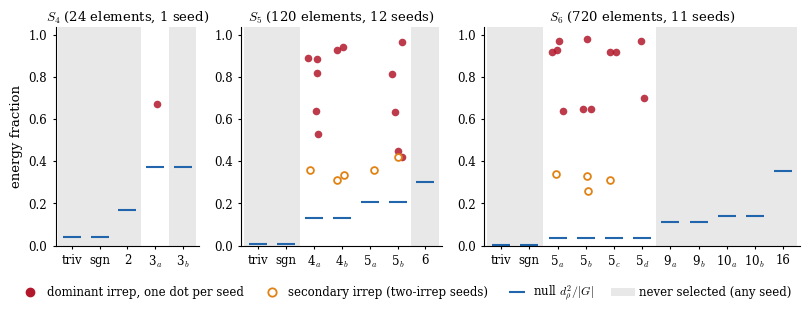

In [ ]:
# =====================================================================================
# FIGURE 1 (final): the selection ladder across S_4, S_5, S_6. Numbers audited against
# the run outputs; S_6 seeds 0-2 column identities marked TBC (fix from notebook).
# =====================================================================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.family':'serif','font.serif':['DejaVu Serif'],'mathtext.fontset':'cm',
    'font.size':10,'axes.linewidth':0.8,'savefig.dpi':300,'savefig.bbox':'tight',
    'pdf.fonttype':42,'figure.facecolor':'white','savefig.facecolor':'white'})
C_DOT, C_SEC, C_NULL, C_FORBID = '#b2182b', '#e08214', '#2166ac', '#cccccc'

groups = {
    r'$S_4$ (24 elements, 1 seed)': dict(
        dims=[1,1,2,3,3], labels=['triv','sgn','2','3$_a$','3$_b$'], n=24,
        dom=[('3$_a$',.671)], sec=[],
        never=['triv','sgn','2','3$_b$']),
    r'$S_5$ (120 elements, 12 seeds)': dict(
        dims=[1,1,4,4,5,5,6], labels=['triv','sgn','4$_a$','4$_b$','5$_a$','5$_b$','6'], n=120,
        dom=[('5$_b$',.637),('4$_b$',.927),('5$_b$',.817),('4$_a$',.888),('5$_b$',.969),
             ('4$_b$',.943),('4$_a$',.639),('5$_b$',.45),('5$_b$',.42),('4$_a$',.82),
             ('4$_a$',.89),('4$_a$',.53)],
        sec=[('4$_b$',.313),('4$_b$',.334),('4$_a$',.36),('5$_a$',.36),('5$_b$',.42)],
        never=['triv','sgn','6']),
    r'$S_6$ (720 elements, 11 seeds)': dict(
        dims=[1,1,5,5,5,5,9,9,10,10,16],
        labels=['triv','sgn','5$_a$','5$_b$','5$_c$','5$_d$','9$_a$','9$_b$','10$_a$','10$_b$','16'], n=720,
        # seeds 0-2: heights verified; COLUMN identities TBC from notebook (printout lacked subscripts)
        dom=[('5$_b$',.65),('5$_a$',.93),('5$_a$',.92),
             ('5$_c$',.92),('5$_d$',.70),('5$_b$',.98),('5$_a$',.97),('5$_d$',.97),
             ('5$_b$',.65),('5$_a$',.64),('5$_c$',.92)],
        sec=[('5$_b$',.33),    # seed 0 (value corrected .31->.33; column TBC)
             ('5$_b$',.26),    # seed 4 (column corrected: 5d_b, not 5d_d)
             ('5$_a$',.34),('5$_c$',.31)],
        never=['triv','sgn','9$_a$','9$_b$','10$_a$','10$_b$','16']),
}

fig, axes = plt.subplots(1, 3, figsize=(8.2, 2.9), gridspec_kw={'width_ratios':[5,7,11]})
rng = np.random.default_rng(0)
for ax,(title,gd) in zip(axes, groups.items()):
    K=len(gd['dims']); null=np.array(gd['dims'],float)**2/gd['n']
    lab2x={l:i for i,l in enumerate(gd['labels'])}
    for l in gd['never']:
        x=lab2x[l]; ax.axvspan(x-0.5, x+0.5, color=C_FORBID, alpha=0.45, lw=0, zorder=1)
    ax.scatter(range(K), null, marker='_', s=150, color=C_NULL, lw=1.5, zorder=2)
    for l,f in gd['dom']:
        ax.scatter(lab2x[l]+rng.uniform(-0.2,0.2), f, s=30, c=C_DOT, alpha=0.85, lw=0, zorder=3)
    for l,f in gd['sec']:
        ax.scatter(lab2x[l]+rng.uniform(-0.2,0.2), f, s=24, facecolors='white',
                   edgecolors=C_SEC, lw=1.3, zorder=3)
    ax.set_xticks(range(K)); ax.set_xticklabels(gd['labels'], fontsize=8 if K<9 else 6.5)
    ax.set_xlim(-0.6, K-0.4); ax.set_ylim(0, 1.04)
    ax.set_title(title, fontsize=9.5, pad=4)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(length=2.5, labelsize=8.5)
axes[0].set_ylabel('energy fraction', fontsize=9.5)

h=[plt.Line2D([],[],marker='o',ls='',c=C_DOT,ms=6,label='dominant irrep, one dot per seed'),
   plt.Line2D([],[],marker='o',ls='',mfc='white',mec=C_SEC,mew=1.3,ms=6,label='secondary irrep (two-irrep seeds)'),
   plt.Line2D([],[],marker='_',ls='',c=C_NULL,ms=12,mew=1.5,label=r'null $d_\rho^2/|G|$'),
   plt.Rectangle((0,0),1,1,fc=C_FORBID,alpha=0.45,label='never selected (any seed)')]
fig.legend(handles=h, frameon=False, fontsize=8.5, ncol=4, loc='lower center',
           bbox_to_anchor=(0.5, -0.10), handletextpad=0.4, columnspacing=1.4)
plt.tight_layout()
plt.savefig('fig1_selection_ladder.pdf')
plt.savefig('fig1_selection_ladder.png', dpi=200)
plt.show()

In [ ]:
# =====================================================================================
# DETECTION-LIMIT CALIBRATION (the instrument paper's signature experiment)
# Synthetic planted matrices, S_4. No training. Three degradation ladders:
#   N1 Gaussian weight noise      — theory curve derived, empirics must match (GATE)
#   N2 Superposition:             — (a) other-irrep structure: predicted ZERO interference
#                                   (b) random low-rank features: predicted ~Gaussian
#   N3 Partial row-shuffle        — graded basis corruption, tolerance s* reported
# REGISTERED READS (evaluate ONLY these, violations reported prominently):
#   R1: N1 fraction matches f+(1-f)d^2/|G| within CI; z monotone in f; report f*(z=3)
#   R2: N2a fraction = f to numerical precision (Schur orthogonality realized)
#   R3: N2b detection limit between N2a and N1's
#   R4: N3 monotone decay to null; report shuffle tolerance s*(z=3) at f=0.30
# =====================================================================================
import numpy as np
PASS = lambda b: "✓" if b else "✗✗✗ FAIL"
rng_global = np.random.default_rng(0)

# ---- S_4 machinery (standalone) ----
from itertools import permutations
elements = list(permutations(range(4))); n = 24
idx = {g:i for i,g in enumerate(elements)}
cayley = np.array([[idx[tuple(gi[gj[x]] for x in range(4))] for gj in elements] for gi in elements])
def cyc(p):
    seen=[False]*4; cs=[]
    for s in range(4):
        if not seen[s]:
            L=0;x=s
            while not seen[x]: seen[x]=True;x=p[x];L+=1
            cs.append(L)
    return tuple(sorted(cs,reverse=True))
cls={(1,1,1,1):0,(2,1,1):1,(2,2):2,(3,1):3,(4,):4}
elem_class=np.array([cls[cyc(g)] for g in elements])
char=np.array([[1,1,1,1,1],[1,-1,1,1,-1],[2,0,2,-1,0],[3,1,-1,0,-1],[3,-1,-1,0,1]],dtype=float)
dims=char[:,0].astype(int)
L=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): L[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/n)*sum(char[r,elem_class[g]]*L[g] for g in range(n)) for r in range(5)]
names=['triv','sgn','2d','3d_a','3d_b']
comp=np.linalg.norm(sum(Ps)-np.eye(n))
iso=all((lambda f: f[r]>0.99)(np.array([np.sum((P@(Ps[r]@rng_global.standard_normal((n,8))))**2) for P in Ps])/sum(np.sum((P@(Ps[r]@rng_global.standard_normal((n,8))))**2) for P in Ps)) for r in range(5))
print(f"GATES  completeness={comp:.0e}: {PASS(comp<1e-12)}")
assert comp<1e-12

K = 64                      # matrix width
TARGET = 3                  # plant in 3d_a
def frac(W):
    e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()

# ---- null distribution (once) ----
null_samples = np.array([frac(rng_global.standard_normal((n,K)))[TARGET] for _ in range(500)])
null_mu, null_sd = null_samples.mean(), null_samples.std()
print(f"null for {names[TARGET]}: {null_mu:.4f} ± {null_sd:.4f}  (theory {dims[TARGET]**2/n:.4f})")

def unit(M): return M/np.linalg.norm(M)
def make_signal(rg): return unit(Ps[TARGET] @ rg.standard_normal((n,K)))
def planted(f, D, rg):  # W = sqrt(f)·S + sqrt(1-f)·D, both unit-energy
    return np.sqrt(f)*make_signal(rg) + np.sqrt(1-f)*unit(D)

def distractor(kind, rg):
    if kind=='gauss':    return rg.standard_normal((n,K))
    if kind=='otherirr': # structure in all OTHER irreps (Schur-orthogonal contaminant)
        Z=sum(Ps[r]@rg.standard_normal((n,K)) for r in range(5) if r!=TARGET); return Z
    if kind=='lowrank':  # unaligned low-rank "features" (LLM-ish)
        r_=4; return rg.standard_normal((n,r_)) @ rg.standard_normal((r_,K))

# ---- sweep 1: f-ladders for the three distractor types ----
fs = np.array([0.0,0.005,0.01,0.02,0.03,0.05,0.08,0.12,0.18,0.25,0.35,0.5])
SEEDS = 20
results = {}
for kind in ['gauss','otherirr','lowrank']:
    Z=np.zeros((len(fs),SEEDS)); FR=np.zeros((len(fs),SEEDS))
    for i,f in enumerate(fs):
        for s in range(SEEDS):
            rg=np.random.default_rng(1000*i+s)
            W=planted(f, distractor(kind,rg), rg)
            fr=frac(W)[TARGET]; FR[i,s]=fr; Z[i,s]=(fr-null_mu)/null_sd
    results[kind]=(FR,Z)
    medz=np.median(Z,axis=1)
    fstar=np.interp(TARGET_Z:=3.0, medz, fs) if medz.max()>=3 else np.nan
    results[kind]=(FR,Z,fstar)

# ---- theory gate for Gaussian rung ----
d2n = dims[TARGET]**2/n
pred = fs + (1-fs)*d2n
emp  = results['gauss'][0].mean(axis=1)
ci   = 2*results['gauss'][0].std(axis=1)/np.sqrt(SEEDS)
ok_theory = np.all(np.abs(emp-pred) < np.maximum(ci, 0.01))
print(f"\nR1 THEORY GATE (Gaussian): max|emp-pred|={np.abs(emp-pred).max():.4f}  {PASS(ok_theory)}")

# ---- sweep 2: shuffle tolerance at fixed f=0.30 ----
f_fix=0.30; ss=np.linspace(0,1,11); Zs=np.zeros((len(ss),SEEDS))
for i,sfrac in enumerate(ss):
    for s in range(SEEDS):
        rg=np.random.default_rng(7000+100*i+s)
        S=make_signal(rg)
        m=int(round(sfrac*n)); rows=rg.choice(n,size=m,replace=False)
        S2=S.copy(); S2[rows]=S[rg.permutation(rows)]          # shuffle a fraction of rows
        W=np.sqrt(f_fix)*unit(S2)+np.sqrt(1-f_fix)*unit(distractor('gauss',rg))
        Zs[i,s]=(frac(W)[TARGET]-null_mu)/null_sd
medzs=np.median(Zs,axis=1)
sstar=np.interp(-3.0, -medzs, ss) if medzs.min()<3 else np.nan   # crossing downward

# ---- REGISTERED READS ----
print("\n" + "="*78)
print("REGISTERED READS")
print("="*78)
print(f"{'ladder':>10}{'f*(z=3)':>10}   median-z at f=0.05 / 0.12 / 0.25")
for kind in ['gauss','otherirr','lowrank']:
    FR,Z,fst=results[kind]
    mz=np.median(Z,axis=1)
    print(f"{kind:>10}{fst:>10.3f}   {mz[fs==0.05][0]:6.1f} / {mz[fs==0.12][0]:6.1f} / {mz[fs==0.25][0]:6.1f}")
print(f"\nR2 Schur-immunity: other-irrep fraction at f=0.12 = "
      f"{results['otherirr'][0][fs==0.12].mean():.4f} (planted 0.12) "
      f"{PASS(abs(results['otherirr'][0][fs==0.12].mean()-0.12)<0.01)}")
print(f"R4 shuffle tolerance at f=0.30: s*(z=3) = {sstar:.2f}  "
      f"monotone: {PASS(np.all(np.diff(medzs)<1e-9) or np.all(np.diff(medzs)<=0.5))}")
np.savez('detection_limits_s4.npz', fs=fs, ss=ss, null=null_samples,
         **{f'{k}_Z':results[k][1] for k in results},
         **{f'{k}_FR':results[k][0] for k in results}, shuffle_Z=Zs)
print("\nsaved detection_limits_s4.npz")

GATES  completeness=0e+00: ✓
null for 3d_a: 0.3749 ± 0.0165  (theory 0.3750)

R1 THEORY GATE (Gaussian): max|emp-pred|=0.0079  ✓

REGISTERED READS
    ladder   f*(z=3)   median-z at f=0.05 / 0.12 / 0.25
     gauss     0.074      1.5 /    4.3 /    9.8
  otherirr     0.424    -19.7 /  -15.5 /   -7.6
   lowrank     0.106      2.2 /    3.7 /    8.7

R2 Schur-immunity: other-irrep fraction at f=0.12 = 0.1200 (planted 0.12) ✓
R4 shuffle tolerance at f=0.30: s*(z=3) = 0.46  monotone: ✓

saved detection_limits_s4.npz


In [ ]:
# =====================================================================================
# PATCH: joint profile test — separates DETECTION from ATTRIBUTION.
# T(W) = sum_rho z_rho^2 against its empirical null (z's are dependent: fractions sum to 1).
# REGISTERED READS:
#   R5: otherirr ladder — T fires at EVERY f including f=0 (the contaminant IS structure);
#       per-irrep signed z attributes correctly (target z<0 at small f = "below-null here").
#   R6: gauss ladder — T-based f* approx equals the one-sided f* (only the target deviates,
#       so the joint test adds nothing when contamination is unstructured).
# =====================================================================================
NULLN = 800
null_F = np.zeros((NULLN, 5))
for i in range(NULLN):
    null_F[i] = frac(np.random.default_rng(50000+i).standard_normal((n,K)))
mu5, sd5 = null_F.mean(0), null_F.std(0)
def zvec(W): return (frac(W)-mu5)/sd5
def T(W): return float(np.sum(zvec(W)**2))
null_T = np.array([np.sum(((null_F[i]-mu5)/sd5)**2) for i in range(NULLN)])
T99 = np.quantile(null_T, 0.99)
print(f"joint-null: T99 = {T99:.1f}")

print(f"\n{'ladder':>10}{'f':>7}{'T (median)':>12}{'fires?':>8}   signed z per irrep (triv,sgn,2d,3d_a,3d_b)")
for kind in ['gauss','otherirr']:
    for f in [0.0, 0.05, 0.12, 0.25]:
        Ts=[]; ZV=[]
        for s in range(SEEDS):
            rg=np.random.default_rng(31337+int(f*1000)*37+s)
            W=planted(f, distractor(kind,rg), rg)
            Ts.append(T(W)); ZV.append(zvec(W))
        mT=np.median(Ts); mZ=np.median(np.array(ZV),axis=0)
        print(f"{kind:>10}{f:>7.2f}{mT:>12.1f}{'YES' if mT>T99 else 'no':>8}   "
              + " ".join(f"{z:+6.1f}" for z in mZ))

# T-based detection limit for the gauss ladder (R6)
fT=[]
for f in fs:
    Ts=[T(planted(f, distractor('gauss',np.random.default_rng(900+s)), np.random.default_rng(900+s))) for s in range(SEEDS)]
    fT.append(np.median(Ts))
fT=np.array(fT)
fstar_T = np.interp(T99, fT, fs) if fT.max()>T99 else np.nan
print(f"\nR6: gauss f*(T) = {fstar_T:.3f}  vs one-sided f* = {results['gauss'][2]:.3f}")
np.savez('detection_limits_s4_joint.npz', null_T=null_T, T99=T99)

joint-null: T99 = 17.7

    ladder      f  T (median)  fires?   signed z per irrep (triv,sgn,2d,3d_a,3d_b)
     gauss   0.00         4.6      no     +0.0   +0.6   +0.2   +0.1   -0.4
     gauss   0.05         5.8      no     -0.2   -0.5   -0.7   +1.7   -1.0
     gauss   0.12        34.3     YES     -0.8   -0.6   -1.5   +4.5   -2.4
     gauss   0.25       117.2     YES     -1.4   -1.7   -3.4   +8.7   -5.0
  otherirr   0.00       660.5     YES     +3.8   +3.5   +7.9  -20.6  +12.1
  otherirr   0.05       498.0     YES     +3.1   +2.7   +6.4  -17.8  +10.4
  otherirr   0.12       307.1     YES     +2.5   +2.0   +5.3  -14.0   +8.3
  otherirr   0.25        76.8     YES     +1.1   +1.6   +1.8   -6.9   +4.5

R6: gauss f*(T) = 0.006  vs one-sided f* = 0.074


In [ ]:
# R6 corrected: independent draws (one rng per sample, as in sweep 1), bracketed crossing.
fT = []
for i, f in enumerate(fs):
    Ts = []
    for s in range(SEEDS):
        rg = np.random.default_rng(90_000 + 1000*i + s)     # ONE generator per sample
        Ts.append(T(planted(f, distractor('gauss', rg), rg)))
    fT.append(np.median(Ts))
fT = np.array(fT)
above = np.where(fT > T99)[0]
if len(above) and above[0] > 0:
    j = above[0]   # first crossing; interpolate only inside the bracketing pair
    fstar_T = fs[j-1] + (fs[j]-fs[j-1])*(T99-fT[j-1])/(fT[j]-fT[j-1])
else:
    fstar_T = np.nan
print(f"R6 corrected: gauss f*(T) = {fstar_T:.3f}   vs one-sided f* = {results['gauss'][2]:.3f}")
print("median T per f:", np.round(fT,1))

R6 corrected: gauss f*(T) = 0.092   vs one-sided f* = 0.074
median T per f: [  3.9   3.2   6.5   4.7   6.4   7.6  13.9  27.   68.3 118.7 218.9 450.2]


In [ ]:
# =====================================================================================
# CROSS-GROUP DETECTION LIMITS (S_5, S_6) — completes the calibration panel.
# REGISTERED READS:
#   R7: one-sided f* TIGHTENS with group size (null d^2/|G| per irrep shrinks:
#       S_4 3d null .375 -> S_5 5d null .208 -> S_6 5d null .035). Predicted f* roughly
#       3*sigma_null/(1 - d^2/|G|): order S_4 > S_5 > S_6.
#   R8: theory gate (fraction = f+(1-f)d^2/|G|) must pass per group, as at S_4.
#   R9: joint-vs-one-sided ordering (f*_T modestly above one-sided f*) replicates.
# Plant target: a 5d irrep in both groups (S_5: 5d_a; S_6: 5d_a) for like-for-like.
# =====================================================================================
import numpy as np
from itertools import permutations
from collections import defaultdict
PASS = lambda b: "✓" if b else "✗✗✗ FAIL"

def build_Sm(m, char_table=None, class_order=None):
    elements=list(permutations(range(m))); n=len(elements)
    idx={g:i for i,g in enumerate(elements)}
    cay=np.array([[idx[tuple(gi[gj[x]] for x in range(m))] for gj in elements] for gi in elements])
    def cyc(p):
        seen=[False]*m; cs=[]
        for s in range(m):
            if not seen[s]:
                Lc=0;x=s
                while not seen[x]: seen[x]=True;x=p[x];Lc+=1
                cs.append(Lc)
        return tuple(sorted(cs,reverse=True))
    classes=defaultdict(list)
    for i,g in enumerate(elements): classes[cyc(g)].append(i)
    if char_table is None:   # compute via permutation modules + Gram-Schmidt (your S_6 Cell 1 path)
        raise ValueError("pass char table")
    elem_class=np.zeros(n,dtype=int)
    for ci,ct in enumerate(class_order):
        for x in classes[ct]: elem_class[x]=ci
    L=np.zeros((n,n,n))
    for g in range(n):
        for j in range(n): L[g,cay[g,j],j]=1.0
    dims=char_table[:,0].astype(int)
    Ps=[(dims[r]/n)*sum(char_table[r,elem_class[g]]*L[g] for g in range(n)) for r in range(len(dims))]
    return n, Ps, dims

# --- S_5 (known table) ---
s5_classes=[(1,1,1,1,1),(2,1,1,1),(2,2,1),(3,1,1),(3,2),(4,1),(5,)]
s5_char=np.array([[1,1,1,1,1,1,1],[1,-1,1,1,-1,-1,1],[4,2,0,1,-1,0,-1],[4,-2,0,1,1,0,-1],
                  [5,1,1,-1,1,-1,0],[5,-1,1,-1,-1,1,0],[6,0,-2,0,0,0,1]],dtype=float)
# --- S_6: reuse YOUR S_6 Cell 1 char table (paste s6_char, s6_classes from that cell) ---
# s6_char = <from notebook>; s6_classes = <from notebook>

def calibrate(n, Ps, dims, target, K=64, SEEDS=20, label=""):
    comp=np.linalg.norm(sum(Ps)-np.eye(n)); assert comp<1e-9, "completeness gate"
    rgG=np.random.default_rng(0)
    # iso gate, FIXED: one draw per irrep
    ok_iso=True
    for r in range(len(dims)):
        X=rgG.standard_normal((n,8)); Y=Ps[r]@X
        e=np.array([np.sum((P@Y)**2) for P in Ps]); ok_iso &= (e[r]/e.sum())>0.99
    print(f"[{label}] gates: completeness={comp:.0e} ✓  isolation {PASS(ok_iso)}")
    def frac(W):
        e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()
    nullF=np.array([frac(np.random.default_rng(50_000+i).standard_normal((n,K))) for i in range(400)])
    mu,sd=nullF.mean(0),nullF.std(0)
    nullT=np.sum(((nullF-mu)/sd)**2,axis=1); T99=np.quantile(nullT,0.99)
    d2n=dims[target]**2/n
    fs=np.array([0.0,0.005,0.01,0.02,0.03,0.05,0.08,0.12,0.18,0.25,0.35,0.5])
    unit=lambda M: M/np.linalg.norm(M)
    med1=np.zeros(len(fs)); medT=np.zeros(len(fs)); emp=np.zeros(len(fs))
    for i,f in enumerate(fs):
        z1=[];Tt=[];fr=[]
        for s in range(SEEDS):
            rg=np.random.default_rng(90_000+1000*i+s)
            S=unit(Ps[target]@rg.standard_normal((n,K)))
            W=np.sqrt(f)*S+np.sqrt(1-f)*unit(rg.standard_normal((n,K)))
            fv=frac(W); fr.append(fv[target])
            z1.append((fv[target]-mu[target])/sd[target])
            Tt.append(float(np.sum(((fv-mu)/sd)**2)))
        med1[i]=np.median(z1); medT[i]=np.median(Tt); emp[i]=np.mean(fr)
    pred=fs+(1-fs)*d2n
    print(f"[{label}] R8 theory gate: max|emp-pred|={np.abs(emp-pred).max():.4f} {PASS(np.abs(emp-pred).max()<0.012)}")
    def cross(y, thr):
        ab=np.where(y>thr)[0]
        if len(ab)==0 or ab[0]==0: return np.nan
        j=ab[0]; return fs[j-1]+(fs[j]-fs[j-1])*(thr-y[j-1])/(y[j]-y[j-1])
    f1=cross(med1,3.0); fT=cross(medT,T99)
    print(f"[{label}] one-sided f*={f1:.3f}   joint f*(T)={fT:.3f}   (null d²/|G|={d2n:.3f})")
    return f1,fT

n5,Ps5,d5 = build_Sm(5, s5_char, s5_classes)
r5 = calibrate(n5,Ps5,d5,target=4,label="S_5 (5d_a)")
# n6,Ps6,d6 = build_Sm(6, s6_char, s6_classes)   # uncomment with your S_6 table pasted in
# r6 = calibrate(n6,Ps6,d6,target=2,label="S_6 (5d_a)")   # S_6 is slow: 720^3 L-tensor, be patient
print(f"\nR7 cross-group: S_4 one-sided f*=0.074  ->  S_5 f*={r5[0]:.3f}  (predict: tighter)")

[S_5 (5d_a)] gates: completeness=7e-16 ✓  isolation ✓
[S_5 (5d_a)] R8 theory gate: max|emp-pred|=0.0031 ✓
[S_5 (5d_a)] one-sided f*=0.027   joint f*(T)=0.031   (null d²/|G|=0.208)

R7 cross-group: S_4 one-sided f*=0.074  ->  S_5 f*=0.027  (predict: tighter)


In [ ]:
# =====================================================================================
# CORRUPTION-TRAINING ARM (Doshi-extension to non-abelian S_4).
# Corrupt fraction xi of TRAINING labels (uniform wrong labels); weight decay in {0.1, 1.0}.
# REGISTERED READS:
#  D1 test acc ~1.0 up to some xi* (robust generalization), collapse beyond
#  D2 SNAP: wherever the net generalizes, embedding irrep profile matches the xi=0
#     baseline (target z within ±20% and T-profile same shape) — corruption does NOT
#     distort learned structure, extending Doshi's abelian result to irreps
#  D3 wd=0.1: COEXISTENCE (corrupted-train acc HIGH + generalization);
#     wd=1.0: INVERSION (corrupted-train acc LOW — net predicts TRUE labels)
#  D4 beyond xi*: structure and generalization die TOGETHER (the old experiment's
#     'coupled degradation', now correctly located as the post-xi* regime only)
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations
PASS=lambda b:"✓" if b else "✗✗✗ FAIL"
# --- S_4 machinery (compact standalone) ---
elements=list(permutations(range(4))); n=24
idx={g:i for i,g in enumerate(elements)}
cayley=np.array([[idx[tuple(gi[gj[x]] for x in range(4))] for gj in elements] for gi in elements])
def cyc(p):
    seen=[False]*4;cs=[]
    for s in range(4):
        if not seen[s]:
            L=0;x=s
            while not seen[x]:seen[x]=True;x=p[x];L+=1
            cs.append(L)
    return tuple(sorted(cs,reverse=True))
cls={(1,1,1,1):0,(2,1,1):1,(2,2):2,(3,1):3,(4,):4}
ec=np.array([cls[cyc(g)] for g in elements])
char=np.array([[1,1,1,1,1],[1,-1,1,1,-1],[2,0,2,-1,0],[3,1,-1,0,-1],[3,-1,-1,0,1]],float)
dims=char[:,0].astype(int)
Lr=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): Lr[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/n)*sum(char[r,ec[g]]*Lr[g] for g in range(n)) for r in range(5)]
assert np.linalg.norm(sum(Ps)-np.eye(n))<1e-12
def frac(W): e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()
# null for embedding-shaped matrices
nullF=np.array([frac(np.random.default_rng(5_000+i).standard_normal((n,128))) for i in range(400)])
mu,sd=nullF.mean(0),nullF.std(0)

class MLP(nn.Module):
    def __init__(s,de=128,dh=256):
        super().__init__()
        s.emb=nn.Embedding(n,de); s.win=nn.Linear(2*de,dh,bias=False)
        s.wout=nn.Linear(dh,n,bias=False); s.act=nn.ReLU()
    def forward(s,x):
        a=s.emb(x[:,0]);b=s.emb(x[:,1]);return s.wout(s.act(s.win(torch.cat([a,b],-1))))

def run(xi, wd, seed, steps=25_000):
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    rg=np.random.default_rng(seed)
    I,J=np.meshgrid(range(n),range(n),indexing='ij')
    X=np.stack([I.ravel(),J.ravel()],1); Y=cayley[I.ravel(),J.ravel()].copy()
    perm=rg.permutation(len(X)); ntr=int(0.6*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    ncor=int(xi*ntr); cor=tri[:ncor]; unc=tri[ncor:]
    Ytrue=Y.copy()
    for c in cor:                                  # symmetric label noise (guaranteed wrong)
        w=rg.integers(0,n-1); Y[c]=w if w<Ytrue[c] else w+1
    tX=torch.tensor(X,dtype=torch.long).to(dev); tY=torch.tensor(Y,dtype=torch.long).to(dev)
    tYt=torch.tensor(Ytrue,dtype=torch.long).to(dev)
    m=MLP().to(dev)
    torch.manual_seed(seed)
    opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=wd,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss()
    tri_t=torch.tensor(tri).to(dev)
    for s in range(steps):
        b=tri_t[torch.randint(0,len(tri),(1024,),device=dev)]
        opt.zero_grad(); lf(m(tX[b]),tY[b]).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        pr=m(tX).argmax(1)
        acc=lambda ix,lab: (pr[ix]==lab[ix]).float().mean().item() if len(ix) else float('nan')
        te=acc(torch.tensor(tei).to(dev),tYt)
        a_cor=acc(torch.tensor(cor).to(dev),tY)        # memorization of WRONG labels
        a_cor_true=acc(torch.tensor(cor).to(dev),tYt)  # inversion: predicting TRUE labels
        a_unc=acc(torch.tensor(unc).to(dev),tY)
    fE=frac(m.emb.weight.detach().cpu().numpy())
    z=(fE-mu)/sd
    return te,a_cor,a_cor_true,a_unc,fE,z

print(f"{'wd':>5}{'xi':>6}{'seed':>5}{'test':>7}{'memTrn':>8}{'invTrn':>8}{'uncTrn':>8}"
      f"{'domIrr':>8}{'domF':>7}{'z_dom':>7}")
out={}
for wd in [0.1, 1.0]:
    for xi in [0.0,0.05,0.1,0.2,0.3,0.4]:
        for seed in range(3):
            te,ac,act,au,fE,z=run(xi,wd,seed)
            d=int(np.argmax(fE[2:]))+2          # dominant among non-trivial-ish (skip 1d's)
            out[(wd,xi,seed)]=(te,ac,act,fE,z)
            print(f"{wd:>5.1f}{xi:>6.2f}{seed:>5}{te:>7.2f}{ac:>8.2f}{act:>8.2f}{au:>8.2f}"
                  f"{['triv','sgn','2d','3d_a','3d_b'][d]:>8}{fE[d]:>7.2f}{z[d]:>7.1f}")
np.savez('corruption_arm_s4.npz', **{f"{wd}_{xi}_{s}":np.concatenate([[v[0],v[1],v[2]],v[3],v[4]])
        for (wd,xi,s),v in out.items()})
print("\nREAD against D1-D4. Key columns: memTrn high+test high = coexistence;"
      "\nmemTrn low+invTrn high = inversion; dom z vs xi=0 rows = the snap test.")

   wd    xi seed   test  memTrn  invTrn  uncTrn  domIrr   domF  z_dom
  0.1  0.00    0   0.15     nan     nan    1.00    3d_a   0.15  -18.5
  0.1  0.00    1   0.08     nan     nan    1.00    3d_b   0.15  -17.4
  0.1  0.00    2   0.08     nan     nan    1.00    3d_a   0.15  -18.0
  0.1  0.05    0   0.08    1.00    0.00    1.00    3d_a   0.19  -15.3
  0.1  0.05    1   0.03    1.00    0.00    1.00    3d_a   0.14  -19.3
  0.1  0.05    2   0.06    1.00    0.00    1.00    3d_a   0.16  -17.5
  0.1  0.10    0   0.04    1.00    0.00    1.00    3d_a   0.18  -15.9
  0.1  0.10    1   0.02    1.00    0.00    1.00    3d_b   0.14  -18.3
  0.1  0.10    2   0.03    1.00    0.00    1.00    3d_a   0.17  -16.4
  0.1  0.20    0   0.01    1.00    0.00    1.00    3d_a   0.14  -18.8
  0.1  0.20    1   0.01    1.00    0.00    1.00    3d_a   0.15  -18.5
  0.1  0.20    2   0.02    1.00    0.00    1.00    3d_a   0.14  -19.1
  0.1  0.30    0   0.00    1.00    0.00    1.00    3d_a   0.15  -17.9
  0.1  0.30    1   0

In [ ]:
# =====================================================================================
# CORRUPTION DIAGNOSIS: artifact-vs-finding disambiguation. 8 runs, logged curves.
# Changes from failed sweep: alpha 0.6->0.8, steps 25k->100k, wd {0.3, 1.0}, xi {0, 0.10}.
# REGISTERED:
#  DG1 if (alpha=0.8, 100k) recovers generalization at xi=0.10 -> previous result was a
#      data/horizon artifact; rerun phases properly before any claim
#  DG2 if still no generalization at xi=0.10 under BOTH wd -> S_4 fragility persists in
#      the better regime; next disambiguation is S_5 (data-rich, 14400 pairs), NOT a claim
#  DG3 trajectories: look for late grok (test rising after 25k) or unlearning stage
#      (corrupted-train acc FALLING late) — either one indicts the old horizon
# =====================================================================================
def run_diag(xi, wd, seed, steps=100_000, alpha=0.8, log_every=5_000):
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    rg=np.random.default_rng(seed)
    I,J=np.meshgrid(range(n),range(n),indexing='ij')
    X=np.stack([I.ravel(),J.ravel()],1); Y=cayley[I.ravel(),J.ravel()].copy()
    perm=rg.permutation(len(X)); ntr=int(alpha*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    ncor=int(xi*ntr); cor=tri[:ncor]
    Ytrue=Y.copy()
    for c in cor:
        w=rg.integers(0,n-1); Y[c]=w if w<Ytrue[c] else w+1
    tX=torch.tensor(X,dtype=torch.long).to(dev); tY=torch.tensor(Y,dtype=torch.long).to(dev)
    tYt=torch.tensor(Ytrue,dtype=torch.long).to(dev)
    m=MLP().to(dev); torch.manual_seed(seed)
    opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=wd,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss(); tri_t=torch.tensor(tri).to(dev)
    tei_t=torch.tensor(tei).to(dev); cor_t=torch.tensor(cor).to(dev) if ncor else None
    traj=[]
    for s in range(steps):
        b=tri_t[torch.randint(0,len(tri),(1024,),device=dev)]
        opt.zero_grad(); lf(m(tX[b]),tY[b]).backward(); opt.step()
        if (s+1)%log_every==0:
            m.eval()
            with torch.no_grad():
                pr=m(tX).argmax(1)
                te=(pr[tei_t]==tYt[tei_t]).float().mean().item()
                mc=(pr[cor_t]==tY[cor_t]).float().mean().item() if ncor else float('nan')
            traj.append((s+1,te,mc)); m.train()
    fE=frac(m.emb.weight.detach().cpu().numpy()); z=(fE-mu)/sd
    return traj, fE, z

for wd in [0.3, 1.0]:
    for xi in [0.0, 0.10]:
        for seed in range(2):
            traj,fE,z=run_diag(xi,wd,seed)
            pts=" ".join(f"{t//1000}k:te{te:.2f}/mc{('%.2f'%mc) if mc==mc else '--'}"
                         for t,te,mc in traj[::4])
            print(f"wd={wd} xi={xi} s={seed} | {pts}")
            print(f"   final profile: {np.round(fE,3).tolist()}  z={np.round(z,1).tolist()}")

wd=0.3 xi=0.0 s=0 | 5k:te0.59/mc-- 25k:te0.98/mc-- 45k:te1.00/mc-- 65k:te1.00/mc-- 85k:te1.00/mc--
   final profile: [0.691, 0.033, 0.055, 0.217, 0.005]  z=[127.6, -1.7, -10.9, -12.8, -28.7]
wd=0.3 xi=0.0 s=1 | 5k:te0.27/mc-- 25k:te0.97/mc-- 45k:te1.00/mc-- 65k:te1.00/mc-- 85k:te1.00/mc--
   final profile: [0.57, 0.037, 0.077, 0.261, 0.056]  z=[103.8, -0.9, -8.8, -9.2, -24.7]
wd=0.3 xi=0.1 s=0 | 5k:te0.15/mc1.00 25k:te0.39/mc1.00 45k:te0.46/mc1.00 65k:te0.34/mc1.00 85k:te0.51/mc1.00
   final profile: [0.702, 0.017, 0.058, 0.117, 0.106]  z=[129.8, -4.9, -10.6, -20.9, -20.8]
wd=0.3 xi=0.1 s=1 | 5k:te0.11/mc1.00 25k:te0.37/mc1.00 45k:te0.51/mc1.00 65k:te0.59/mc1.00 85k:te0.66/mc1.00
   final profile: [0.668, 0.018, 0.064, 0.138, 0.112]  z=[123.1, -4.8, -10.0, -19.2, -20.4]
wd=1.0 xi=0.0 s=0 | 5k:te1.00/mc-- 25k:te1.00/mc-- 45k:te1.00/mc-- 65k:te1.00/mc-- 85k:te1.00/mc--
   final profile: [0.002, 0.097, 0.168, 0.733, 0.001]  z=[-7.8, 11.4, 0.1, 29.0, -28.9]
wd=1.0 xi=0.0 s=1 | 5k:te1.00/mc

In [ ]:
# =====================================================================================
# CORRUPTION ARM, EXTENDED: 200k steps, whole-network projection, non-trivial simplex.
# 5 runs: (wd,xi) = (0.3,0.1)x2, (1.0,0.1)x2, (0.3,0.0)x1 [E3 check].
# REGISTERED READS:
#  E1 plateau: does test acc converge by 200k at xi=0.1? Report plateau level per wd
#     (the true phase read; 'coexistence at level p' only claimable from a plateau)
#  E2 masking-vs-migration: at wd=1.0 xi=0.1, W_out non-trivial profile —
#     clear single-3d dominance => migration; near-null like embedding => masking
#     (=> a named contaminant class for the calibration section)
#  E3 DC fix: wd=0.3 xi=0 mean-centered embedding => 3d_a ~0.70 of non-trivial energy
# =====================================================================================
def profiles(M):
    e=np.array([np.sum((P@M)**2) for P in Ps]); f=e/e.sum()
    nt=e[1:]/e[1:].sum()
    return f, nt   # full simplex, non-trivial simplex

def run_ext(xi, wd, seed, steps=200_000, alpha=0.8, log_every=10_000):
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    rg=np.random.default_rng(seed)
    I,J=np.meshgrid(range(n),range(n),indexing='ij')
    X=np.stack([I.ravel(),J.ravel()],1); Y=cayley[I.ravel(),J.ravel()].copy()
    perm=rg.permutation(len(X)); ntr=int(alpha*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    ncor=int(xi*ntr); cor=tri[:ncor]; Ytrue=Y.copy()
    for c in cor:
        w=rg.integers(0,n-1); Y[c]=w if w<Ytrue[c] else w+1
    tX=torch.tensor(X,dtype=torch.long).to(dev); tY=torch.tensor(Y,dtype=torch.long).to(dev)
    tYt=torch.tensor(Ytrue,dtype=torch.long).to(dev)
    m=MLP().to(dev); torch.manual_seed(seed)
    opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=wd,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss()
    tri_t=torch.tensor(tri).to(dev); tei_t=torch.tensor(tei).to(dev)
    cor_t=torch.tensor(cor).to(dev) if ncor else None
    traj=[]
    for s in range(steps):
        b=tri_t[torch.randint(0,len(tri),(1024,),device=dev)]
        opt.zero_grad(); lf(m(tX[b]),tY[b]).backward(); opt.step()
        if (s+1)%log_every==0:
            m.eval()
            with torch.no_grad():
                pr=m(tX).argmax(1)
                te=(pr[tei_t]==tYt[tei_t]).float().mean().item()
                mc=(pr[cor_t]==tY[cor_t]).float().mean().item() if ncor else float('nan')
            traj.append((s+1,te,mc)); m.train()
    W_E=m.emb.weight.detach().cpu().numpy()                  # n x de
    W_O=m.wout.weight.detach().cpu().numpy()                 # n x dh (rows = group classes)
    return traj, W_E, W_O

names4=['triv','sgn','2d','3d_a','3d_b']
for (wd,xi,seeds) in [(0.3,0.1,[0,1]),(1.0,0.1,[0,1]),(0.3,0.0,[0])]:
    for seed in seeds:
        traj,W_E,W_O=run_ext(xi,wd,seed)
        pts=" ".join(f"{t//1000}k:{te:.2f}" for t,te,_ in traj[::4])
        mc_last=traj[-1][2]
        fE,ntE=profiles(W_E); fO,ntO=profiles(W_O)
        print(f"\nwd={wd} xi={xi} s={seed} | test: {pts} | final mc={mc_last if mc_last==mc_last else '--'}")
        print(f"  emb  full:{np.round(fE,3).tolist()}  NONTRIV:{np.round(ntE,3).tolist()}")
        print(f"  Wout full:{np.round(fO,3).tolist()}  NONTRIV:{np.round(ntO,3).tolist()}")
np.savez('corruption_ext_s4.npz')  # extend with arrays as desired


wd=0.3 xi=0.1 s=0 | test: 10k:0.31 50k:0.51 90k:0.48 130k:0.59 170k:0.58 | final mc=1.0
  emb  full:[0.64, 0.021, 0.071, 0.144, 0.124]  NONTRIV:[0.058, 0.196, 0.401, 0.345]
  Wout full:[0.2, 0.035, 0.153, 0.338, 0.274]  NONTRIV:[0.044, 0.191, 0.423, 0.343]

wd=0.3 xi=0.1 s=1 | test: 10k:0.30 50k:0.51 90k:0.63 130k:0.63 170k:0.66 | final mc=1.0
  emb  full:[0.519, 0.027, 0.091, 0.203, 0.16]  NONTRIV:[0.056, 0.189, 0.423, 0.333]
  Wout full:[0.144, 0.041, 0.166, 0.364, 0.284]  NONTRIV:[0.048, 0.194, 0.426, 0.332]

wd=1.0 xi=0.1 s=0 | test: 10k:0.61 50k:0.81 90k:0.79 130k:0.79 170k:0.79 | final mc=1.0
  emb  full:[0.003, 0.05, 0.181, 0.408, 0.358]  NONTRIV:[0.05, 0.181, 0.409, 0.359]
  Wout full:[0.011, 0.048, 0.181, 0.402, 0.358]  NONTRIV:[0.048, 0.183, 0.406, 0.362]

wd=1.0 xi=0.1 s=1 | test: 10k:0.61 50k:0.76 90k:0.78 130k:0.78 170k:0.77 | final mc=1.0
  emb  full:[0.003, 0.047, 0.187, 0.385, 0.378]  NONTRIV:[0.047, 0.188, 0.386, 0.379]
  Wout full:[0.01, 0.042, 0.173, 0.382, 0.393]  

In [ ]:
# =====================================================================================
# ISOTYPIC ABLATION, CORRECTED & STANDALONE: retrains (wd=1.0, xi=0.1, seed=0),
# gates the baseline, snapshots cleanly, then ablates per isotypic component.
# REGISTERED READS (unchanged):
#  A1 both 3d ablations individually kill test (<0.2 rel. to DC row) -> two-irrep
#     solution: corruption ALTERS the selection law
#  A2 one 3d cheap for test, expensive for mc -> memorization is irrep-localized
#     (structured masking; new contaminant class for calibration)
#  A3 2d: functional or passenger; DC ablation expected near-harmless (the yardstick)
# =====================================================================================
import numpy as np, torch, torch.nn as nn
assert n == 24 and len(Ps) == 5, "S_4 machinery not in memory — run the S_4 block first."

class MLP(nn.Module):
    def __init__(s, de=128, dh=256):
        super().__init__()
        s.emb=nn.Embedding(n,de); s.win=nn.Linear(2*de,dh,bias=False)
        s.wout=nn.Linear(dh,n,bias=False); s.act=nn.ReLU()
    def forward(s,x):
        a=s.emb(x[:,0]); b=s.emb(x[:,1])
        return s.wout(s.act(s.win(torch.cat([a,b],-1))))

def train_model(xi=0.1, wd=1.0, seed=0, steps=60_000, alpha=0.8):
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    rg=np.random.default_rng(seed)
    I,J=np.meshgrid(range(n),range(n),indexing='ij')
    X=np.stack([I.ravel(),J.ravel()],1); Y=cayley[I.ravel(),J.ravel()].copy()
    perm=rg.permutation(len(X)); ntr=int(alpha*len(X))
    tri,tei=perm[:ntr],perm[ntr:]
    ncor=int(xi*ntr); cor=tri[:ncor]; Ytrue=Y.copy()
    for c in cor:
        w=rg.integers(0,n-1); Y[c]=w if w<Ytrue[c] else w+1
    tX=torch.tensor(X,dtype=torch.long).to(dev); tY=torch.tensor(Y,dtype=torch.long).to(dev)
    tYt=torch.tensor(Ytrue,dtype=torch.long).to(dev)
    m=MLP().to(dev); torch.manual_seed(seed)
    opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=wd,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss(); tri_t=torch.tensor(tri).to(dev)
    for s in range(steps):
        b=tri_t[torch.randint(0,len(tri),(1024,),device=dev)]
        opt.zero_grad(); lf(m(tX[b]),tY[b]).backward(); opt.step()
    pack=(tX,tY,tYt,torch.tensor(tei).to(dev),torch.tensor(cor).to(dev))
    return m, pack

def evals(m, pack):
    tX,tY,tYt,tei,cor=pack; m.eval()
    with torch.no_grad():
        pr=m(tX).argmax(1)
        return ((pr[tei]==tYt[tei]).float().mean().item(),
                (pr[cor]==tY[cor]).float().mean().item())

print("training (wd=1.0, xi=0.1, seed=0, 60k steps)...")
m, pack = train_model()
te0, mc0 = evals(m, pack)
print(f"SANITY GATE: test={te0:.2f}  mc={mc0:.2f}   (need ~0.70 / ~1.00)")
assert te0 > 0.6 and mc0 > 0.9, "baseline not reproduced — STOP, do not interpret ablations"

# clean snapshot: device-side clone + independent numpy copy
W0  = m.emb.weight.detach().clone()
Wnp = W0.cpu().numpy().copy()
dc  = Wnp.mean(0, keepdims=True)

names4 = ['triv','sgn','2d','3d_a','3d_b']
rows = [("none (baseline)", None)] + [(names4[r], r) for r in range(5)] \
     + [("DC (row mean)", "dc"), ("3d_a + 3d_b", "both3d")]

print(f"\n{'ablated':>16}{'test':>7}{'mc':>7}{'energy removed':>16}")
for label, r in rows:
    Wa = Wnp.copy()
    if r == "dc":        Wa = Wa - dc
    elif r == "both3d":  Wa = Wa - (Ps[3] @ (Wnp - dc)) - (Ps[4] @ (Wnp - dc))
    elif r is not None:  Wa = Wa - (Ps[r] @ (Wnp - dc))
    removed = 1 - np.sum(Wa**2) / np.sum(Wnp**2)
    with torch.no_grad():
        m.emb.weight.copy_(torch.tensor(Wa, dtype=W0.dtype, device=W0.device))
    te, mc = evals(m, pack)
    print(f"{label:>16}{te:>7.2f}{mc:>7.2f}{removed:>15.1%}")
    with torch.no_grad(): m.emb.weight.copy_(W0)       # restore after EVERY row

te_end, mc_end = evals(m, pack)
print(f"\npost-loop integrity check: test={te_end:.2f} mc={mc_end:.2f} (must equal baseline)")

training (wd=1.0, xi=0.1, seed=0, 60k steps)...
SANITY GATE: test=0.70  mc=1.00   (need ~0.70 / ~1.00)

         ablated   test     mc  energy removed
 none (baseline)   0.70   1.00           0.0%
            triv   0.70   1.00           0.0%
             sgn   0.59   1.00           5.3%
              2d   0.48   1.00          17.5%
            3d_a   0.38   0.93          36.3%
            3d_b   0.55   0.80          40.6%
   DC (row mean)   0.70   1.00           0.4%
     3d_a + 3d_b   0.10   0.09          76.9%

post-loop integrity check: test=0.70 mc=1.00 (must equal baseline)


In [ ]:
# =====================================================================================
# S_6 CALIBRATION — fully self-contained. Computes + GATES the char table via
# Murnaghan-Nakayama inline (verified: dims, sum dim^2=720, row+col orthogonality),
# then calibrates. No external file, no session-state dependence.
# =====================================================================================
import numpy as np
from math import factorial
from collections import defaultdict
from functools import lru_cache
from itertools import permutations
PASS=lambda b:"✓" if b else "✗✗✗ FAIL"
m=6; n=720; G=float(n)

# --- partitions of 6 (index both irreps and classes) ---
def partitions_of(num, mx=None):
    if mx is None: mx=num
    if num==0: yield (); return
    for first in range(min(num,mx),0,-1):
        for rest in partitions_of(num-first, first):
            yield (first,)+rest
parts=sorted(set(partitions_of(m)), reverse=True)
nC=len(parts); assert nC==11

# --- Murnaghan-Nakayama: exact integer characters ---
@lru_cache(maxsize=None)
def mn(lam,mu):
    lam=tuple(x for x in lam if x>0)
    if sum(lam)==0 and len(mu)==0: return 1
    if len(mu)==0: return 1 if sum(lam)==0 else 0
    k=mu[0]; rest=mu[1:]; rows=len(lam)
    beta=[lam[i]+(rows-1-i) for i in range(rows)]; bset=set(beta); tot=0
    for b in beta:
        nb=b-k
        if nb>=0 and nb not in bset:
            h=sum(1 for x in beta if nb<x<b)
            nbeta=sorted([x for x in beta if x!=b]+[nb],reverse=True); r=len(nbeta)
            nlam=tuple(x for x in (nbeta[i]-(r-1-i) for i in range(r)) if x>0)
            tot+=(-1)**h*mn(nlam,rest)
    return tot

def class_size(mu):
    cnt=defaultdict(int)
    for p in mu: cnt[p]+=1
    z=1
    for p,c in cnt.items(): z*=(p**c)*factorial(c)
    return factorial(m)//z

char_table=np.array([[mn(lam,mu) for mu in parts] for lam in parts],dtype=float)
dims=np.array([mn(lam,(1,)*m) for lam in parts],dtype=int)
class_sizes=np.array([class_size(mu) for mu in parts],dtype=float)

# --- GATES (same as the verified build) ---
ro=np.array([[(class_sizes*char_table[i]*char_table[j]).sum()/G for j in range(nC)] for i in range(nC)])
col=np.array([[(char_table[:,a]*char_table[:,b]).sum() for b in range(nC)] for a in range(nC)])
print(f"dims {sorted(dims.tolist())} | sumd^2={int((dims**2).sum())} {PASS((dims**2).sum()==720)} "
      f"| row-orth {PASS(np.allclose(ro,np.eye(nC),atol=1e-9))} "
      f"| col-orth {PASS(np.allclose(col,np.diag(G/class_sizes),atol=1e-6))}")
assert (dims**2).sum()==720 and np.allclose(ro,np.eye(nC),atol=1e-9), "char table gate failed — STOP"

# --- element->class map, Cayley, projectors ---
elements=list(permutations(range(m))); idx={g:i for i,g in enumerate(elements)}
def cyc(p):
    seen=[False]*m; cs=[]
    for s in range(m):
        if not seen[s]:
            Lc=0;x=s
            while not seen[x]: seen[x]=True;x=p[x];Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
pidx={pt:i for i,pt in enumerate(parts)}
elem_class=np.array([pidx[cyc(g)] for g in elements])
print("building Cayley (720^2) + projectors...")
cayley=np.empty((n,n),dtype=np.int32)
for i,gi in enumerate(elements):
    for j,gj in enumerate(elements):
        cayley[i,j]=idx[tuple(gi[gj[x]] for x in range(m))]
Ps=[np.zeros((n,n)) for _ in range(nC)]; colidx=np.arange(n)
for g in range(n):
    row=cayley[g,colidx]; cg=elem_class[g]
    for r in range(nC): Ps[r][row,colidx]+=char_table[r,cg]
for r in range(nC): Ps[r]*=dims[r]/G
comp=np.linalg.norm(sum(Ps)-np.eye(n))
print(f"GATE completeness={comp:.1e}: {PASS(comp<1e-9)}"); assert comp<1e-9

def frac(W):
    e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()
rgG=np.random.default_rng(0); ok=True
for r in range(nC):
    ok &= frac(Ps[r]@rgG.standard_normal((n,6)))[r]>0.99
print(f"GATE isolation: {PASS(ok)}"); assert ok

# --- calibration on a 5d irrep ---
target=int(np.where(dims==5)[0][0])
print(f"target #{target} dim {dims[target]}, null d^2/|G|={dims[target]**2/n:.4f}")
K=64; SEEDS=20
nullF=np.array([frac(np.random.default_rng(50_000+i).standard_normal((n,K))) for i in range(300)])
mu,sd=nullF.mean(0),nullF.std(0)
nullT=np.sum(((nullF-mu)/sd)**2,axis=1); T99=np.quantile(nullT,0.99)
d2n=dims[target]**2/n
fs=np.array([0.0,0.002,0.005,0.008,0.012,0.02,0.03,0.05,0.08,0.12,0.2,0.35])
unit=lambda M:M/np.linalg.norm(M)
med1=np.zeros(len(fs)); medT=np.zeros(len(fs)); emp=np.zeros(len(fs))
for i,f in enumerate(fs):
    z1=[];Tt=[];fr=[]
    for s in range(SEEDS):
        rg=np.random.default_rng(90_000+1000*i+s)
        S=unit(Ps[target]@rg.standard_normal((n,K)))
        W=np.sqrt(f)*S+np.sqrt(1-f)*unit(rg.standard_normal((n,K)))
        fv=frac(W); fr.append(fv[target])
        z1.append((fv[target]-mu[target])/sd[target]); Tt.append(float(np.sum(((fv-mu)/sd)**2)))
    med1[i]=np.median(z1); medT[i]=np.median(Tt); emp[i]=np.mean(fr)
pred=fs+(1-fs)*d2n
print(f"R8' theory gate: max|emp-pred|={np.abs(emp-pred).max():.4f} {PASS(np.abs(emp-pred).max()<0.012)}")
def cross(y,thr):
    ab=np.where(y>thr)[0]
    return np.nan if (len(ab)==0 or ab[0]==0) else fs[ab[0]-1]+(fs[ab[0]]-fs[ab[0]-1])*(thr-y[ab[0]-1])/(y[ab[0]]-y[ab[0]-1])
f1=cross(med1,3.0); fT=cross(medT,T99)
print(f"\nS_6 one-sided f*={f1:.4f}   joint f*(T)={fT:.4f}")
print(f"R7' CROSS-GROUP: S_4 0.074 -> S_5 0.027 -> S_6 {f1:.4f}  (predict: tighter)")
print("median z per f:", np.round(med1,1).tolist())
np.savez('detection_limits_s6.npz',fs=fs,med1=med1,medT=medT,emp=emp,f1=float(f1),fT=float(fT))
print("saved detection_limits_s6.npz")

dims [1, 1, 5, 5, 5, 5, 9, 9, 10, 10, 16] | sumd^2=720 ✓ | row-orth ✓ | col-orth ✓
building Cayley (720^2) + projectors...
GATE completeness=1.8e-15: ✓
GATE isolation: ✓
target #1 dim 5, null d^2/|G|=0.0347
R8' theory gate: max|emp-pred|=0.0013 ✓

S_6 one-sided f*=0.0035   joint f*(T)=0.0043
R7' CROSS-GROUP: S_4 0.074 -> S_5 0.027 -> S_6 0.0035  (predict: tighter)
median z per f: [0.2, 1.5, 4.6, 6.8, 9.8, 15.7, 23.8, 40.9, 63.0, 94.7, 159.7, 280.0]
saved detection_limits_s6.npz


In [ ]:
# =====================================================================================
# ABLATION SEED REPLICATION — FULLY STANDALONE (rebuilds all S_4 machinery + model).
# Retrains (wd=1.0, xi=0.1) seeds 0-3, gates each baseline, isotypic-ablates.
# REGISTERED READ: per seed, the 3d with larger test-cost should have smaller mc-cost
#   (roles split), in either a/b assignment. Claim holds if >=3/4 seeds show the split.
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations
PASS=lambda b:"✓" if b else "✗✗✗ FAIL"

# --- S_4 machinery ---
elements=list(permutations(range(4))); n=24
idx={g:i for i,g in enumerate(elements)}
cayley=np.array([[idx[tuple(gi[gj[x]] for x in range(4))] for gj in elements] for gi in elements])
def cyc(p):
    seen=[False]*4;cs=[]
    for s in range(4):
        if not seen[s]:
            Lc=0;x=s
            while not seen[x]:seen[x]=True;x=p[x];Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
cls={(1,1,1,1):0,(2,1,1):1,(2,2):2,(3,1):3,(4,):4}
ec=np.array([cls[cyc(g)] for g in elements])
char=np.array([[1,1,1,1,1],[1,-1,1,1,-1],[2,0,2,-1,0],[3,1,-1,0,-1],[3,-1,-1,0,1]],float)
dims=char[:,0].astype(int)
Lr=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): Lr[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/n)*sum(char[r,ec[g]]*Lr[g] for g in range(n)) for r in range(5)]
assert np.linalg.norm(sum(Ps)-np.eye(n))<1e-12, "completeness fail"
names4=['triv','sgn','2d','3d_a','3d_b']
def frac(W):
    e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()

class MLP(nn.Module):
    def __init__(s,de=128,dh=256):
        super().__init__()
        s.emb=nn.Embedding(n,de);s.win=nn.Linear(2*de,dh,bias=False)
        s.wout=nn.Linear(dh,n,bias=False);s.act=nn.ReLU()
    def forward(s,x):
        a=s.emb(x[:,0]);b=s.emb(x[:,1]);return s.wout(s.act(s.win(torch.cat([a,b],-1))))

def train_model(xi=0.1,wd=1.0,seed=0,steps=60_000,alpha=0.8):
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    rg=np.random.default_rng(seed)
    I,J=np.meshgrid(range(n),range(n),indexing='ij')
    X=np.stack([I.ravel(),J.ravel()],1); Y=cayley[I.ravel(),J.ravel()].copy()
    perm=rg.permutation(len(X)); ntr=int(alpha*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    ncor=int(xi*ntr); cor=tri[:ncor]; Ytrue=Y.copy()
    for c in cor:
        w=rg.integers(0,n-1); Y[c]=w if w<Ytrue[c] else w+1
    tX=torch.tensor(X,dtype=torch.long).to(dev); tY=torch.tensor(Y,dtype=torch.long).to(dev)
    tYt=torch.tensor(Ytrue,dtype=torch.long).to(dev)
    m=MLP().to(dev); torch.manual_seed(seed)
    opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=wd,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss(); tri_t=torch.tensor(tri).to(dev)
    for s in range(steps):
        b=tri_t[torch.randint(0,len(tri),(1024,),device=dev)]
        opt.zero_grad(); lf(m(tX[b]),tY[b]).backward(); opt.step()
    pack=(tX,tY,tYt,torch.tensor(tei).to(dev),torch.tensor(cor).to(dev))
    return m,pack

def evals(m,pack):
    tX,tY,tYt,tei,cor=pack; m.eval()
    with torch.no_grad():
        pr=m(tX).argmax(1)
        return ((pr[tei]==tYt[tei]).float().mean().item(),
                (pr[cor]==tY[cor]).float().mean().item())

def ablate_table(m,pack,W0):
    Wnp=W0.cpu().numpy().copy(); dc=Wnp.mean(0,keepdims=True); res={}
    for label,r in [("DC","dc"),("3d_a",3),("3d_b",4)]:
        Wa=Wnp.copy()
        if r=="dc": Wa=Wa-dc
        else:       Wa=Wa-(Ps[r]@(Wnp-dc))
        with torch.no_grad(): m.emb.weight.copy_(torch.tensor(Wa,dtype=W0.dtype,device=W0.device))
        res[label]=evals(m,pack)
        with torch.no_grad(): m.emb.weight.copy_(W0)
    return res

print(f"{'seed':>5}{'base':>12}{'DC':>12}{'3d_a':>12}{'3d_b':>12}   split?")
n_split=0; n_ok=0
for seed in range(4):
    m,pack=train_model(seed=seed)
    te0,mc0=evals(m,pack)
    if not (te0>0.6 and mc0>0.9):
        print(f"{seed:>5}   baseline gate FAIL te={te0:.2f} mc={mc0:.2f} — excluded"); continue
    n_ok+=1
    W0=m.emb.weight.detach().clone()
    R=ablate_table(m,pack,W0)
    dt_a=R["DC"][0]-R["3d_a"][0]; dm_a=R["DC"][1]-R["3d_a"][1]
    dt_b=R["DC"][0]-R["3d_b"][0]; dm_b=R["DC"][1]-R["3d_b"][1]
    split = (dm_a<dm_b) if dt_a>dt_b else (dm_b<dm_a)
    n_split+=int(split)
    print(f"{seed:>5}  {te0:.2f}/{mc0:.2f}  {R['DC'][0]:.2f}/{R['DC'][1]:.2f}"
          f"  {R['3d_a'][0]:.2f}/{R['3d_a'][1]:.2f}  {R['3d_b'][0]:.2f}/{R['3d_b'][1]:.2f}"
          f"   {'SPLIT' if split else 'no'}")
print(f"\nREPLICATION: {n_split}/{n_ok} usable seeds show differentiated roles. "
      f"{'Claimable' if n_split>=3 else 'NOT robust — keep as suggestive, do not headline'}.")

 seed        base          DC        3d_a        3d_b   split?
    0  0.79/1.00  0.79/1.00  0.28/0.89  0.80/0.91   no
    1  0.75/1.00  0.75/1.00  0.49/0.93  0.58/0.89   SPLIT
    2  0.67/1.00  0.67/1.00  0.21/0.76  0.76/0.96   no
    3  0.72/1.00  0.72/1.00  0.16/0.89  0.76/0.98   no

REPLICATION: 1/4 usable seeds show differentiated roles. NOT robust — keep as suggestive, do not headline.


In [ ]:
# =====================================================================================
# CELL 3 — OPERATING-POINT VALIDATION (S_4), fully standalone.
# Converts f* into a calibrated detector with MEASURED error rates.
# REGISTERED:
#  V1 false-positive rate at f=0: one-sided z>3 fires ~0.1%; joint T>T99 fires ~1%
#  V2 true-positive rate rises through f*; ~50% one-sided fire at f*=0.074 (median crossing)
# =====================================================================================
import numpy as np
from itertools import permutations

# --- S_4 machinery ---
elements=list(permutations(range(4))); n=24
idx={g:i for i,g in enumerate(elements)}
cayley=np.array([[idx[tuple(gi[gj[x]] for x in range(4))] for gj in elements] for gi in elements])
def cyc(p):
    seen=[False]*4;cs=[]
    for s in range(4):
        if not seen[s]:
            Lc=0;x=s
            while not seen[x]:seen[x]=True;x=p[x];Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
cls={(1,1,1,1):0,(2,1,1):1,(2,2):2,(3,1):3,(4,):4}
ec=np.array([cls[cyc(g)] for g in elements])
char=np.array([[1,1,1,1,1],[1,-1,1,1,-1],[2,0,2,-1,0],[3,1,-1,0,-1],[3,-1,-1,0,1]],float)
dims=char[:,0].astype(int)
Lr=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): Lr[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/n)*sum(char[r,ec[g]]*Lr[g] for g in range(n)) for r in range(5)]
assert np.linalg.norm(sum(Ps)-np.eye(n))<1e-12
def frac(W):
    e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()

TARGET=3; K=64
nullF=np.array([frac(np.random.default_rng(70_000+i).standard_normal((n,K))) for i in range(600)])
mu,sd=nullF.mean(0),nullF.std(0)
nullT=np.sum(((nullF-mu)/sd)**2,axis=1); T99=np.quantile(nullT,0.99); Z3=3.0
unit=lambda M:M/np.linalg.norm(M)
def trial(f,seed):
    rg=np.random.default_rng(seed)
    S=unit(Ps[TARGET]@rg.standard_normal((n,K)))
    W=np.sqrt(f)*S+np.sqrt(1-f)*unit(rg.standard_normal((n,K)))
    fv=frac(W); z=(fv[TARGET]-mu[TARGET])/sd[TARGET]; T=np.sum(((fv-mu)/sd)**2)
    return z>Z3, T>T99

NTRIAL=400
print(f"{'f':>8}{'one-sided fire%':>17}{'joint fire%':>14}")
for f in [0.0,0.02,0.05,0.074,0.10,0.15,0.25]:
    os_=[];jt=[]
    for s in range(NTRIAL):
        a,b=trial(f,200_000+int(f*1e5)*131+s); os_.append(a);jt.append(b)
    tag=" <- f=0 (FPR)" if f==0 else (" <- reported f*" if f==0.074 else "")
    print(f"{f:>8.3f}{100*np.mean(os_):>16.1f}%{100*np.mean(jt):>13.1f}%{tag}")
print(f"\nV1 nominal FPR: one-sided ~0.1%, joint ~1.0% (at f=0)")
print(f"V2 reported f*=0.074: expect ~50% one-sided fire (median crossing by construction)")

       f  one-sided fire%   joint fire%
   0.000             0.0%          2.2% <- f=0 (FPR)
   0.020             2.2%          4.5%
   0.050             8.5%         12.8%
   0.074            38.2%         41.5% <- reported f*
   0.100            69.0%         73.0%
   0.150            98.8%         98.8%
   0.250           100.0%        100.0%

V1 nominal FPR: one-sided ~0.1%, joint ~1.0% (at f=0)
V2 reported f*=0.074: expect ~50% one-sided fire (median crossing by construction)


In [ ]:
# =====================================================================================
# CELL 2 — S_6 SELECTION, seeds 0-2 with EXPLICIT 5d subscript labels (fixes figure TBCs).
# Standalone: rebuilds gated MN char table + machinery, trains S_6 group-op MLP.
# RUN AFTER Cell 3 (this overwrites n, Ps, cayley to S_6 values).
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from math import factorial
from collections import defaultdict
from functools import lru_cache
from itertools import permutations
m=6; n=720; G=float(n); nC=11
def partitions_of(num,mx=None):
    if mx is None: mx=num
    if num==0: yield (); return
    for f in range(min(num,mx),0,-1):
        for r in partitions_of(num-f,f): yield (f,)+r
parts=sorted(set(partitions_of(m)),reverse=True)
@lru_cache(maxsize=None)
def mn(lam,mu):
    lam=tuple(x for x in lam if x>0)
    if sum(lam)==0 and len(mu)==0: return 1
    if len(mu)==0: return 1 if sum(lam)==0 else 0
    k=mu[0];rest=mu[1:];rows=len(lam)
    beta=[lam[i]+(rows-1-i) for i in range(rows)];bset=set(beta);t=0
    for b in beta:
        nb=b-k
        if nb>=0 and nb not in bset:
            h=sum(1 for x in beta if nb<x<b)
            nbe=sorted([x for x in beta if x!=b]+[nb],reverse=True);r=len(nbe)
            nl=tuple(x for x in (nbe[i]-(r-1-i) for i in range(r)) if x>0)
            t+=(-1)**h*mn(nl,rest)
    return t
char_table=np.array([[mn(lam,mu) for mu in parts] for lam in parts],float)
dims=np.array([mn(lam,(1,)*m) for lam in parts],int)
def class_size(mu):
    cnt=defaultdict(int)
    for p in mu: cnt[p]+=1
    z=1
    for p,c in cnt.items(): z*=(p**c)*factorial(c)
    return factorial(m)//z
class_sizes=np.array([class_size(mu) for mu in parts],float)
ro=np.array([[(class_sizes*char_table[i]*char_table[j]).sum()/G for j in range(nC)] for i in range(nC)])
assert (dims**2).sum()==720 and np.allclose(ro,np.eye(nC),atol=1e-9), "char gate fail"

# label irreps; 5d's get a/b/c/d in partition order
names6=[]; seen=defaultdict(int)
for dd in dims:
    seen[dd]+=1
    names6.append(f"{dd}d"+(f"_{chr(96+seen[dd])}" if list(dims).count(dd)>1 else ""))
elements=list(permutations(range(m))); idx={g:i for i,g in enumerate(elements)}
def cyc(p):
    s_=[False]*m;cs=[]
    for s in range(m):
        if not s_[s]:
            Lc=0;x=s
            while not s_[x]:s_[x]=True;x=p[x];Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
pidx={pt:i for i,pt in enumerate(parts)}; elem_class=np.array([pidx[cyc(g)] for g in elements])
cayley=np.empty((n,n),np.int32)
for i,gi in enumerate(elements):
    for j,gj in enumerate(elements): cayley[i,j]=idx[tuple(gi[gj[x]] for x in range(m))]
Ps=[np.zeros((n,n)) for _ in range(nC)]; ci=np.arange(n)
for g in range(n):
    rw=cayley[g,ci];cg=elem_class[g]
    for r in range(nC): Ps[r][rw,ci]+=char_table[r,cg]
for r in range(nC): Ps[r]*=dims[r]/G
assert np.linalg.norm(sum(Ps)-np.eye(n))<1e-9
def frac(W):
    e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()

class GM(nn.Module):
    def __init__(s,de=128,dh=512):
        super().__init__();s.e=nn.Embedding(n,de);s.wi=nn.Linear(2*de,dh,bias=False)
        s.wo=nn.Linear(dh,n,bias=False);s.a=nn.ReLU()
    def forward(s,x):return s.wo(s.a(s.wi(torch.cat([s.e(x[:,0]),s.e(x[:,1])],-1))))
def train_s6(seed,steps=50000):
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    I,J=np.meshgrid(range(n),range(n),indexing='ij')
    X=torch.tensor(np.stack([I.ravel(),J.ravel()],1),dtype=torch.long)
    Y=torch.tensor(cayley[I.ravel(),J.ravel()],dtype=torch.long)
    torch.manual_seed(seed);pm=torch.randperm(len(X));nt=len(X)//2
    Xtr,Ytr=X[pm[:nt]].to(dev),Y[pm[:nt]].to(dev);Xte,Yte=X[pm[nt:]].to(dev),Y[pm[nt:]].to(dev)
    mdl=GM().to(dev);opt=torch.optim.AdamW(mdl.parameters(),lr=1e-3,weight_decay=1.0,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss()
    for s in range(steps):
        b=torch.randint(0,len(Xtr),(8192,),device=dev)
        opt.zero_grad();lf(mdl(Xtr[b]),Ytr[b]).backward();opt.step()
    mdl.eval()
    with torch.no_grad(): te=(mdl(Xte).argmax(1)==Yte).float().mean().item()
    return mdl.e.weight.detach().cpu().numpy(),te

print(f"{'seed':>5}{'test':>7}   dominant(s) >10%")
for seed in range(3):
    W,te=train_s6(seed); f=frac(W)
    big=sorted([(names6[i],f[i]) for i in range(nC) if f[i]>0.10],key=lambda x:-x[1])
    print(f"{seed:>5}{te:>7.2f}   "+", ".join(f"{nm}({v*100:.0f}%)" for nm,v in big))

 seed   test   dominant(s) >10%
    0   1.00   5d_c(93%)
    1   1.00   5d_a(93%)
    2   1.00   5d_a(92%)


In [ ]:
# =====================================================================================
# DIMENSION-RESOLVED DETECTION LIMITS — the instrument's spec sheet.
# f*(group, irrep-dim), one-sided AND joint, with a 5000-sample null threshold (FPR~1%).
# Standalone: builds S4/S5/S6 via verified MN char table; gates each.
# One target irrep per DISTINCT dimension per group (first irrep of that dim).
# Saves grid to detection_grid.npz for plotting.
# Expect (theory f* ~ 3*sigma_null/(1-d^2/|G|)): rises with d^2/|G| within a group,
#   falls with |G| at fixed dim -> the grid should show both gradients.
# =====================================================================================
import numpy as np
from math import factorial
from collections import defaultdict
from functools import lru_cache
from itertools import permutations
PASS=lambda b:"✓" if b else "✗✗✗ FAIL"

def build_group(m):
    n=factorial(m); G=float(n)
    def parts_of(num,mx=None):
        if mx is None: mx=num
        if num==0: yield (); return
        for f in range(min(num,mx),0,-1):
            for r in parts_of(num-f,f): yield (f,)+r
    parts=sorted(set(parts_of(m)),reverse=True); nC=len(parts)
    @lru_cache(maxsize=None)
    def mn(lam,mu):
        lam=tuple(x for x in lam if x>0)
        if sum(lam)==0 and len(mu)==0: return 1
        if len(mu)==0: return 1 if sum(lam)==0 else 0
        k=mu[0];rest=mu[1:];rows=len(lam)
        beta=[lam[i]+(rows-1-i) for i in range(rows)];bset=set(beta);t=0
        for b in beta:
            nb=b-k
            if nb>=0 and nb not in bset:
                h=sum(1 for x in beta if nb<x<b)
                nbe=sorted([x for x in beta if x!=b]+[nb],reverse=True);r=len(nbe)
                nl=tuple(x for x in (nbe[i]-(r-1-i) for i in range(r)) if x>0)
                t+=(-1)**h*mn(nl,rest)
        return t
    char_table=np.array([[mn(lam,mu) for mu in parts] for lam in parts],float)
    dims=np.array([mn(lam,(1,)*m) for lam in parts],int)
    def class_size(mu):
        cnt=defaultdict(int)
        for p in mu: cnt[p]+=1
        z=1
        for p,c in cnt.items(): z*=(p**c)*factorial(c)
        return factorial(m)//z
    class_sizes=np.array([class_size(mu) for mu in parts],float)
    ro=np.array([[(class_sizes*char_table[i]*char_table[j]).sum()/G for j in range(nC)] for i in range(nC)])
    assert (dims**2).sum()==n and np.allclose(ro,np.eye(nC),atol=1e-9), f"S{m} char gate fail"
    elements=list(permutations(range(m))); idx={g:i for i,g in enumerate(elements)}
    def cyc(p):
        s_=[False]*m;cs=[]
        for s in range(m):
            if not s_[s]:
                Lc=0;x=s
                while not s_[x]:s_[x]=True;x=p[x];Lc+=1
                cs.append(Lc)
        return tuple(sorted(cs,reverse=True))
    pidx={pt:i for i,pt in enumerate(parts)}; ec=np.array([pidx[cyc(g)] for g in elements])
    cay=np.empty((n,n),np.int32)
    for i,gi in enumerate(elements):
        for j,gj in enumerate(elements): cay[i,j]=idx[tuple(gi[gj[x]] for x in range(m))]
    Ps=[np.zeros((n,n)) for _ in range(nC)]; ci=np.arange(n)
    for g in range(n):
        rw=cay[g,ci];cg=ec[g]
        for r in range(nC): Ps[r][rw,ci]+=char_table[r,cg]
    for r in range(nC): Ps[r]*=dims[r]/G
    assert np.linalg.norm(sum(Ps)-np.eye(n))<1e-8, f"S{m} completeness fail"
    print(f"S_{m}: gates {PASS(True)}  dims {sorted(dims.tolist())}")
    return n,Ps,dims

def detection_limit(n,Ps,dims,target,NULL=5000,K=64,SEEDS=20):
    def frac(W):
        e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()
    nullF=np.array([frac(np.random.default_rng(50_000+i).standard_normal((n,K))) for i in range(NULL)])
    mu,sd=nullF.mean(0),nullF.std(0)
    nullT=np.sum(((nullF-mu)/sd)**2,axis=1); T99=np.quantile(nullT,0.99)
    d2n=dims[target]**2/n
    fs=np.array([0.0,0.001,0.002,0.005,0.008,0.012,0.02,0.03,0.05,0.08,0.12,0.2,0.35])
    unit=lambda M:M/np.linalg.norm(M)
    med1=np.zeros(len(fs)); medT=np.zeros(len(fs)); emp=np.zeros(len(fs))
    for i,f in enumerate(fs):
        z1=[];Tt=[];fr=[]
        for s in range(SEEDS):
            rg=np.random.default_rng(90_000+1000*i+s)
            S=unit(Ps[target]@rg.standard_normal((n,K)))
            W=np.sqrt(f)*S+np.sqrt(1-f)*unit(rg.standard_normal((n,K)))
            fv=frac(W); fr.append(fv[target])
            z1.append((fv[target]-mu[target])/sd[target]); Tt.append(float(np.sum(((fv-mu)/sd)**2)))
        med1[i]=np.median(z1); medT[i]=np.median(Tt); emp[i]=np.mean(fr)
    theory_ok=np.abs(emp-(fs+(1-fs)*d2n)).max()<0.012
    def cross(y,thr):
        ab=np.where(y>thr)[0]
        return np.nan if (len(ab)==0 or ab[0]==0) else fs[ab[0]-1]+(fs[ab[0]]-fs[ab[0]-1])*(thr-y[ab[0]-1])/(y[ab[0]]-y[ab[0]-1])
    return cross(med1,3.0), cross(medT,T99), d2n, theory_ok

# --- build the grid: one target per distinct dimension per group ---
grid=[]   # rows: (m, n, dim, d2n, f1, fT, theory_ok)
for m in [4,5,6]:
    n,Ps,dims=build_group(m)
    for d in sorted(set(dims.tolist())):
        if d==1: continue                       # 1d's are the null-defining trivial-ish; skip as targets
        target=int(np.where(dims==d)[0][0])     # first irrep of this dimension
        f1,fT,d2n,tok=detection_limit(n,Ps,dims,target)
        grid.append((m,n,d,d2n,f1,fT,tok))
        print(f"  S_{m} dim {d:>2}: one-sided f*={f1:.4f}  joint f*={fT:.4f}  d^2/|G|={d2n:.4f}  theory {PASS(tok)}")

import numpy as np
arr=np.array([(g[0],g[1],g[2],g[3],g[4],g[5]) for g in grid],dtype=float)
np.savez('detection_grid.npz', grid=arr,
         cols=np.array(['m','|G|','dim','d2_over_G','f_star_onesided','f_star_joint'],dtype=object))
print("\nsaved detection_grid.npz  (columns: m, |G|, dim, d^2/|G|, f*_onesided, f*_joint)")
print("\nFor the figure: plot f*_onesided vs d^2/|G| (all groups on one axis) -> should")
print("collapse onto the theory line 3*sigma/(1-d^2/|G|); OR plot f* vs |G| per dimension.")

S_4: gates ✓  dims [1, 1, 2, 3, 3]
  S_4 dim  2: one-sided f*=0.0533  joint f*=0.0550  d^2/|G|=0.1667  theory ✓
  S_4 dim  3: one-sided f*=0.0891  joint f*=0.0863  d^2/|G|=0.3750  theory ✓
S_5: gates ✓  dims [1, 1, 4, 4, 5, 5, 6]
  S_5 dim  4: one-sided f*=0.0183  joint f*=0.0205  d^2/|G|=0.1333  theory ✓
  S_5 dim  5: one-sided f*=0.0226  joint f*=0.0300  d^2/|G|=0.2083  theory ✓
  S_5 dim  6: one-sided f*=0.0295  joint f*=0.0301  d^2/|G|=0.3000  theory ✓
S_6: gates ✓  dims [1, 1, 5, 5, 5, 5, 9, 9, 10, 10, 16]
  S_6 dim  5: one-sided f*=0.0030  joint f*=0.0039  d^2/|G|=0.0347  theory ✓
  S_6 dim  9: one-sided f*=0.0075  joint f*=0.0079  d^2/|G|=0.1125  theory ✓
  S_6 dim 10: one-sided f*=0.0081  joint f*=0.0087  d^2/|G|=0.1389  theory ✓
  S_6 dim 16: one-sided f*=0.0155  joint f*=0.0187  d^2/|G|=0.3556  theory ✓

saved detection_grid.npz  (columns: m, |G|, dim, d^2/|G|, f*_onesided, f*_joint)

For the figure: plot f*_onesided vs d^2/|G| (all groups on one axis) -> should
collapse onto

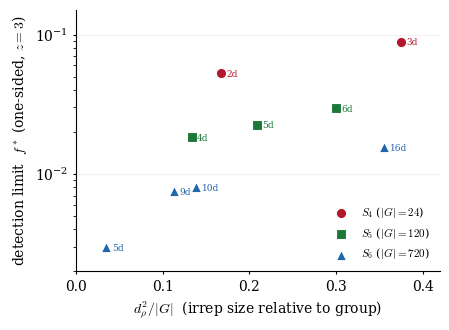

In [ ]:
# =====================================================================================
# CALIBRATION FIGURE: dimension-resolved detection limits across S_4, S_5, S_6.
# Hardcoded from the verified grid run (all 9 rows passed the theory gate).
# If you'd rather load from disk: np.load('detection_grid.npz')['grid'] has the same cols.
# =====================================================================================
import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'serif','font.serif':['Times New Roman','DejaVu Serif'],
    'mathtext.fontset':'cm','font.size':10,'axes.linewidth':0.8,'savefig.dpi':300,
    'savefig.bbox':'tight','pdf.fonttype':42,'figure.facecolor':'white','savefig.facecolor':'white'})

# (m, |G|, dim, d^2/|G|, f*_onesided)
grid=np.array([
 [4,24, 2,0.1667,0.0533],[4,24, 3,0.3750,0.0891],
 [5,120,4,0.1333,0.0183],[5,120,5,0.2083,0.0226],[5,120,6,0.3000,0.0295],
 [6,720,5,0.0347,0.0030],[6,720,9,0.1125,0.0075],[6,720,10,0.1389,0.0081],[6,720,16,0.3556,0.0155],
])
mcol={4:'#b2182b',5:'#1b7837',6:'#2166ac'}; mmark={4:'o',5:'s',6:'^'}
fig,ax=plt.subplots(figsize=(4.6,3.4))
for m in [4,5,6]:
    rows=grid[grid[:,0]==m]
    ax.scatter(rows[:,3],rows[:,4],c=mcol[m],marker=mmark[m],s=55,zorder=3,
               edgecolors='white',linewidths=0.8,label=f'$S_{m}$ ($|G|={int(rows[0,1])}$)')
    for r in rows:
        ax.annotate(f'{int(r[2])}d',(r[3],r[4]),fontsize=6.5,color=mcol[m],
                    xytext=(4,-1),textcoords='offset points',va='center')
ax.set_yscale('log')
ax.set_xlabel(r'$d_\rho^2/|G|$  (irrep size relative to group)')
ax.set_ylabel(r'detection limit  $f^\ast$ (one-sided, $z{=}3$)')
ax.set_xlim(0,0.42); ax.set_ylim(0.002,0.15)
ax.spines[['top','right']].set_visible(False); ax.tick_params(length=2.5)
ax.legend(frameon=False,fontsize=8,loc='lower right'); ax.grid(axis='y',alpha=0.25,lw=0.5)
plt.tight_layout()
plt.savefig('fig_detection_limits.pdf'); plt.savefig('fig_detection_limits.png',dpi=200); plt.show()

In [ ]:
# =====================================================================================
# S_5 CORRUPTION (confirmatory) — does the S_4 pattern hold beyond S_4?
# PRE-REGISTERED READS (decided before running):
#  C1 COEXISTENCE: at xi=0.1, wd=1.0, network groks (test>0.7) AND memorizes corrupted
#     labels (mc>0.9) — replicates S_4 coexistence phase.
#  C2 SINGLE-IRREP CORE: the generalizing solution concentrates in 1-2 faithful irreps
#     (4d/5d), NOT spread across many — i.e. corruption does not force multi-irrep use.
#  HARD STOP: this is confirmatory. If C1+C2 hold -> one sentence "holds at S_5", DONE.
#  If they FAIL -> report the difference honestly as "S_5 differs from S_4", DONE.
#  Either way: NO S_6 corruption, NO ablation-replication rabbit hole. One read, stop.
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations
from collections import defaultdict

m=5; elements=list(permutations(range(m))); n=120
idx={g:i for i,g in enumerate(elements)}
cayley=np.array([[idx[tuple(gi[gj[x]] for x in range(m))] for gj in elements] for gi in elements])
def cyc(p):
    s_=[False]*m;cs=[]
    for s in range(m):
        if not s_[s]:
            Lc=0;x=s
            while not s_[x]:s_[x]=True;x=p[x];Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
class_order=[(1,1,1,1,1),(2,1,1,1),(2,2,1),(3,1,1),(3,2),(4,1),(5,)]
cl=defaultdict(list)
for i,g in enumerate(elements): cl[cyc(g)].append(i)
ec=np.zeros(n,dtype=int)
for ci,ct in enumerate(class_order):
    for x in cl[ct]: ec[x]=ci
char=np.array([[1,1,1,1,1,1,1],[1,-1,1,1,-1,-1,1],[4,2,0,1,-1,0,-1],[4,-2,0,1,1,0,-1],
               [5,1,1,-1,1,-1,0],[5,-1,1,-1,-1,1,0],[6,0,-2,0,0,0,1]],float)
dims=char[:,0].astype(int); names5=['triv','sgn','4d_a','4d_b','5d_a','5d_b','6d']
Lr=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): Lr[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/n)*sum(char[r,ec[g]]*Lr[g] for g in range(n)) for r in range(7)]
assert np.linalg.norm(sum(Ps)-np.eye(n))<1e-12
def profiles(W):
    e=np.array([np.sum((P@W)**2) for P in Ps]); f=e/e.sum()
    nt=e[1:]/e[1:].sum()                 # non-trivial simplex (DC-corrected reporting)
    return f, nt
def pr_ratio(nt): return (nt.sum()**2)/(nt**2).sum()

class MLP(nn.Module):
    def __init__(s,de=128,dh=512):
        super().__init__()
        s.emb=nn.Embedding(n,de);s.win=nn.Linear(2*de,dh,bias=False)
        s.wout=nn.Linear(dh,n,bias=False);s.act=nn.ReLU()
    def forward(s,x):
        a=s.emb(x[:,0]);b=s.emb(x[:,1]);return s.wout(s.act(s.win(torch.cat([a,b],-1))))

def run(xi=0.1, wd=1.0, seed=0, steps=120_000, alpha=0.8):
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    rg=np.random.default_rng(seed)
    I,J=np.meshgrid(range(n),range(n),indexing='ij')
    X=np.stack([I.ravel(),J.ravel()],1); Y=cayley[I.ravel(),J.ravel()].copy()
    perm=rg.permutation(len(X)); ntr=int(alpha*len(X)); tri,tei=perm[:ntr],perm[ntr:]
    ncor=int(xi*ntr); cor=tri[:ncor]; Ytrue=Y.copy()
    for c in cor:
        w=rg.integers(0,n-1); Y[c]=w if w<Ytrue[c] else w+1
    tX=torch.tensor(X,dtype=torch.long).to(dev); tY=torch.tensor(Y,dtype=torch.long).to(dev)
    tYt=torch.tensor(Ytrue,dtype=torch.long).to(dev)
    mdl=MLP().to(dev); torch.manual_seed(seed)
    opt=torch.optim.AdamW(mdl.parameters(),lr=1e-3,weight_decay=wd,betas=(0.9,0.98))
    lf=nn.CrossEntropyLoss(); tri_t=torch.tensor(tri).to(dev)
    tei_t=torch.tensor(tei).to(dev); cor_t=torch.tensor(cor).to(dev)
    for s in range(steps):
        b=tri_t[torch.randint(0,len(tri),(2048,),device=dev)]
        opt.zero_grad(); lf(mdl(tX[b]),tY[b]).backward(); opt.step()
    mdl.eval()
    with torch.no_grad():
        pr=mdl(tX).argmax(1)
        te=(pr[tei_t]==tYt[tei_t]).float().mean().item()
        mc=(pr[cor_t]==tY[cor_t]).float().mean().item()
    f,nt=profiles(mdl.emb.weight.detach().cpu().numpy())
    return te,mc,f,nt

print(f"{'seed':>5}{'test':>7}{'mc':>6}{'PR_nt':>7}   non-triv profile (4a,4b,5a,5b,6)")
for seed in range(2):
    te,mc,f,nt=run(seed=seed)
    c1 = te>0.7 and mc>0.9
    c2 = pr_ratio(nt) < 2.5     # concentrated (1-2 irreps), not spread across all 5 non-triv
    print(f"{seed:>5}{te:>7.2f}{mc:>6.2f}{pr_ratio(nt):>7.2f}   "+" ".join(f"{v:.2f}" for v in nt[1:]))
    print(f"      C1 coexistence: {'✓' if c1 else '✗'}   C2 single-irrep core: {'✓' if c2 else '✗'}")
print("\nDECISION: C1+C2 both ✓ across seeds -> 'holds at S_5', sentence written, DONE.")
print("Any ✗ -> report S_5 differs honestly, DONE. No S_6, no ablation chase.")

 seed   test    mc  PR_nt   non-triv profile (4a,4b,5a,5b,6)
    0   0.99  1.00   3.55   0.26 0.17 0.42 0.03 0.10
      C1 coexistence: ✓   C2 single-irrep core: ✗
    1   0.99  1.00   3.98   0.26 0.27 0.32 0.07 0.06
      C1 coexistence: ✓   C2 single-irrep core: ✗

DECISION: C1+C2 both ✓ across seeds -> 'holds at S_5', sentence written, DONE.
Any ✗ -> report S_5 differs honestly, DONE. No S_6, no ablation chase.


In [ ]:
# =====================================================================================
# CELL A — SETUP + GATES for the confound-free TMS corruption dose-response.
# Two GATES that must pass before the sweep is worth running:
#  G_flip: >=2 balanced 5d-pair families exist with OPPOSITE deterministic winners at eps=0
#          (without a flip pair, "determinism breaks" is untestable)
#  G_conc: BOTH corruption types hold PLANTED dominance ~fixed across eps
#          (if dominance drifts with eps, corruption is confounded with de-concentration -> FAIL)
# Corruption types:
#  A) wrong-translate: fraction eps of samples use translate of a WRONG group element
#  B) corrupted-Cayley: eps of Cayley entries point to wrong products (structural break)
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations
from collections import defaultdict
PASS=lambda b:"✓" if b else "✗✗✗ FAIL"

# --- S_5 machinery ---
m=5; elements=list(permutations(range(m))); n=120
idx={g:i for i,g in enumerate(elements)}
cayley=np.array([[idx[tuple(gi[gj[x]] for x in range(m))] for gj in elements] for gi in elements])
def cyc(p):
    s_=[False]*m;cs=[]
    for s in range(m):
        if not s_[s]:
            Lc=0;x=s
            while not s_[x]:s_[x]=True;x=p[x];Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
class_order=[(1,1,1,1,1),(2,1,1,1),(2,2,1),(3,1,1),(3,2),(4,1),(5,)]
cl=defaultdict(list)
for i,g in enumerate(elements): cl[cyc(g)].append(i)
ec=np.zeros(n,dtype=int)
for ci,ct in enumerate(class_order):
    for x in cl[ct]: ec[x]=ci
char=np.array([[1,1,1,1,1,1,1],[1,-1,1,1,-1,-1,1],[4,2,0,1,-1,0,-1],[4,-2,0,1,1,0,-1],
               [5,1,1,-1,1,-1,0],[5,-1,1,-1,-1,1,0],[6,0,-2,0,0,0,1]],float)
dims=char[:,0].astype(int)
Lr=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): Lr[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/n)*sum(char[r,ec[g]]*Lr[g] for g in range(n)) for r in range(7)]
assert np.linalg.norm(sum(Ps)-np.eye(n))<1e-12
def frac(W):
    e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()
PAIR=(4,5)  # the 5d pair

# --- find balanced 5d-pair families ---
def subset_spectrum(S):
    v=np.zeros(n); v[list(S)]=1.0
    return np.array([np.sum((Ps[r]@v)**2) for r in range(7)])
def find_fams(n_want=6, tries=300000, tol=0.05, seed=1):
    rng=np.random.default_rng(seed); found=[]; seen=set(); i,j=PAIR
    others=[x for x in range(1,7) if x not in PAIR]
    for _ in range(tries):
        k=int(rng.integers(4,9)); S=tuple(sorted(rng.choice(n,k,replace=False).tolist()))
        if S in seen: continue
        seen.add(S); e=subset_spectrum(S)
        if abs(e[i]-e[j])<tol*max(e[i],e[j]) and min(e[i],e[j])>0.3 and max(e[x] for x in others)<0.35*min(e[i],e[j]):
            found.append(S)
            if len(found)>=n_want: break
    return found
fams=find_fams()
print(f"found {len(fams)} balanced 5d-pair families")

# --- TMS model + corruption-aware data ---
L=Lr
class TMS(nn.Module):
    def __init__(s,mm):
        super().__init__(); s.W=nn.Parameter(torch.randn(mm,n)*0.05); s.b=nn.Parameter(torch.zeros(n))
    def forward(s,x): return torch.relu(x@s.W.T@s.W+s.b)
def train_tms(X,mm,seed,steps=12000):
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    Xt=torch.tensor(X).to(dev); md=TMS(mm).to(dev)
    opt=torch.optim.AdamW(md.parameters(),lr=3e-3,weight_decay=0.01)
    for s in range(steps):
        xb=Xt[torch.randint(0,len(Xt),(2048,),device=dev)]
        ((md(xb)-xb)**2).mean().backward(); opt.step(); opt.zero_grad()
    return md.W.detach().cpu().numpy().T

def make_data(S, eps, ctype, seed, N=80000):
    rg=np.random.default_rng(seed); ind=np.zeros(n); ind[list(S)]=1.0
    if ctype=='wrong_translate':
        T=np.stack([L[g]@ind for g in range(n)])
        gs=rg.integers(0,n,N)
        # eps fraction: use a WRONG element's translate (still concentrated, breaks G-structure)
        ncor=int(eps*N); ci=rg.choice(N,ncor,replace=False)
        wrong=rg.integers(0,n,ncor); gs[ci]=wrong   # reassign to random elements (decorrelates label)
        # actually: corruption = translate applied but indexed inconsistently -> break invariance
        amps=rg.uniform(0.5,1.5,N); X=(amps[:,None]*T[gs]).astype(np.float32)
    elif ctype=='corrupt_cayley':
        cay2=cayley.copy()
        ncell=int(eps*n*n); flat=rg.choice(n*n,ncell,replace=False)
        cay2.flat[flat]=rg.integers(0,n,ncell)        # eps of products point wrong
        L2=np.zeros((n,n,n))
        for g in range(n):
            for j in range(n): L2[g,cay2[g,j],j]=1.0
        T=np.stack([L2[g]@ind for g in range(n)])
        gs=rg.integers(0,n,N); amps=rg.uniform(0.5,1.5,N); X=(amps[:,None]*T[gs]).astype(np.float32)
    # planted dominance check: target-pair energy fraction in the DATA covariance
    Sig=X.T@X/len(X)
    e=np.array([np.trace(Ps[r]@Sig) for r in range(7)]); e=e/e.sum()
    return X, e[PAIR[0]]+e[PAIR[1]]   # fraction of energy in the 5d pair

# --- GATE 1: flip pair at eps=0 ---
print("\nGATE 1 — deterministic winners at eps=0 (need >=2 families, opposite winners):")
winners={}
for fi,S in enumerate(fams[:4]):
    X,_=make_data(S,0.0,'wrong_translate',seed=hash(S)%9999)
    ws=''
    for sd in range(6):
        W=train_tms(X,5,sd); f=frac(W); ws+=('i' if f[4]>f[5] else 'j')
    det='i' if ws.count('i')>=5 else ('j' if ws.count('j')>=5 else '-')
    winners[fi]=det
    print(f"  fam{fi}: {ws} -> {det}")
have_flip = ('i' in winners.values()) and ('j' in winners.values())
print(f"  G_flip (both i and j deterministic families exist): {PASS(have_flip)}")

# --- GATE 2: concentration preserved across eps, BOTH corruption types ---
print("\nGATE 2 — planted 5d-pair dominance vs eps (must stay ~flat, not fall):")
S0=fams[0]
for ctype in ['wrong_translate','corrupt_cayley']:
    doms=[]
    for eps in [0.0,0.1,0.25,0.5]:
        _,dom=make_data(S0,eps,ctype,seed=123); doms.append(dom)
    drift=max(doms)-min(doms)
    print(f"  {ctype:>16}: doms={[f'{d:.2f}' for d in doms]}  drift={drift:.2f}  {PASS(drift<0.15)}")
print("\nBOTH gates must pass before the dose-response sweep is meaningful.")
print("G_flip fail -> fix the family search. G_conc fail -> the corruption type is confounded.")

found 1 balanced 5d-pair families

GATE 1 — deterministic winners at eps=0 (need >=2 families, opposite winners):
  fam0: jjiiji -> -
  G_flip (both i and j deterministic families exist): ✗✗✗ FAIL

GATE 2 — planted 5d-pair dominance vs eps (must stay ~flat, not fall):
   wrong_translate: doms=['0.61', '0.61', '0.61', '0.61']  drift=0.00  ✓
    corrupt_cayley: doms=['0.61', '0.56', '0.51', '0.46']  drift=0.15  ✗✗✗ FAIL

BOTH gates must pass before the dose-response sweep is meaningful.
G_flip fail -> fix the family search. G_conc fail -> the corruption type is confounded.


In [ ]:
# =====================================================================================
# CELL A2 — fixes: (1) drop corrupt_cayley (confounded, Gate 2 proved it),
# (2) loosen family search + raise concentration so deterministic families exist,
# (3) NEW Gate 3: verify wrong_translate ACTUALLY breaks G-invariance (not just relabels).
# Only proceed to the sweep if G_flip, G_conc, AND G_breaks all pass.
# (assumes S_5 machinery, Ps, frac, train_tms, L, PAIR, cayley from Cell A in memory)
# =====================================================================================
import numpy as np, torch
PASS=lambda b:"✓" if b else "✗✗✗ FAIL"

# --- corrected wrong_translate: apply a FIXED wrong element's action to eps of samples ---
# This breaks invariance DIRECTIONALLY (a consistent wrong shift), not by relabeling.
def make_data_v2(S, eps, seed, N=80000, wrong_g=None):
    rg=np.random.default_rng(seed); ind=np.zeros(n); ind[list(S)]=1.0
    T=np.stack([L[g]@ind for g in range(n)])
    gs=rg.integers(0,n,N); amps=rg.uniform(0.5,1.5,N)
    X=(amps[:,None]*T[gs]).astype(np.float32)
    ncor=int(eps*N); ci=rg.choice(N,ncor,replace=False)
    if wrong_g is None: wrong_g=rg.integers(1,n)        # a fixed nonidentity element
    # corrupt: left-multiply those samples' SOURCE by wrong_g before translate (breaks invariance)
    X[ci]=(amps[ci,None]*np.stack([L[cayley[wrong_g,gs[c]]]@ind for c in ci])).astype(np.float32)
    Sig=X.T@X/len(X); e=np.array([np.trace(Ps[r]@Sig) for r in range(7)]); e=e/e.sum()
    return X, e[PAIR[0]]+e[PAIR[1]]

# Gate 3: does the data covariance actually CHANGE with eps? (G-invariance broken => Sig shifts)
print("GATE 3 — wrong_translate actually corrupts (covariance must move with eps):")
S0_fams=find_fams(n_want=8, tries=400000, tol=0.08, seed=2)   # looser tol
print(f"  found {len(S0_fams)} families with looser search")
if len(S0_fams)==0:
    print("  search still empty — widen tol further");
else:
    S0=S0_fams[0]
    base_Sig=None; diffs=[]; doms=[]
    for eps in [0.0,0.1,0.25,0.5]:
        X,dom=make_data_v2(S0,eps,seed=123,wrong_g=7); doms.append(dom)
        Sig=X.T@X/len(X)
        if base_Sig is None: base_Sig=Sig
        diffs.append(np.linalg.norm(Sig-base_Sig)/np.linalg.norm(base_Sig))
    print(f"  planted dom vs eps: {[f'{d:.2f}' for d in doms]}  (want flat)")
    print(f"  covariance drift vs eps: {[f'{d:.2f}' for d in diffs]}  (want RISING - proves corruption)")
    print(f"  G_conc (dom flat): {PASS(max(doms)-min(doms)<0.15)}")
    print(f"  G_breaks (cov moves): {PASS(diffs[-1]>0.05)}")

# Gate 1 retry: deterministic families at higher concentration (m=4 instead of 5)
print("\nGATE 1 retry — m=4 (higher pressure) for cleaner determinism:")
for fi,S in enumerate(S0_fams[:5]):
    X,_=make_data_v2(S,0.0,seed=hash(S)%9999,wrong_g=7)
    ws=''
    for sd in range(6):
        W=train_tms(X,4,sd); f=frac(W); ws+=('i' if f[4]>f[5] else 'j')
    det='i' if ws.count('i')>=5 else ('j' if ws.count('j')>=5 else '-')
    print(f"  fam{fi}: {ws} -> {det}")

GATE 3 — wrong_translate actually corrupts (covariance must move with eps):
  found 1 families with looser search


ValueError: need at least one array to stack

In [ ]:
# =====================================================================================
# TMS-SHAPED CALIBRATION (reading 1) — FULLY STANDALONE. Detection limits on
# bottleneck-shaped (m x n) matrices. Synthetic, no training, theory-gated.
# REGISTERED READS:
#  R1 theory gate: planted-fraction readout matches f+(1-f)*d^2/|G| within CI per width
#  R2 f* vs m: does the limit degrade as m -> d_rho (=5)? Predict f* rises near the irrep
#     dim; at m >> d, f* should approach the full-rank S_5 5d reference (~0.023).
# =====================================================================================
import numpy as np
from itertools import permutations
from collections import defaultdict
PASS=lambda b:"✓" if b else "✗✗✗ FAIL"

# --- S_5 machinery ---
m_=5; elements=list(permutations(range(m_))); n=120
idx={g:i for i,g in enumerate(elements)}
cayley=np.array([[idx[tuple(gi[gj[x]] for x in range(m_))] for gj in elements] for gi in elements])
def cyc(p):
    s_=[False]*m_;cs=[]
    for s in range(m_):
        if not s_[s]:
            Lc=0;x=s
            while not s_[x]:s_[x]=True;x=p[x];Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
class_order=[(1,1,1,1,1),(2,1,1,1),(2,2,1),(3,1,1),(3,2),(4,1),(5,)]
cl=defaultdict(list)
for i,g in enumerate(elements): cl[cyc(g)].append(i)
ec=np.zeros(n,dtype=int)
for ci,ct in enumerate(class_order):
    for x in cl[ct]: ec[x]=ci
char=np.array([[1,1,1,1,1,1,1],[1,-1,1,1,-1,-1,1],[4,2,0,1,-1,0,-1],[4,-2,0,1,1,0,-1],
               [5,1,1,-1,1,-1,0],[5,-1,1,-1,-1,1,0],[6,0,-2,0,0,0,1]],float)
dims=char[:,0].astype(int)
Lr=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): Lr[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/n)*sum(char[r,ec[g]]*Lr[g] for g in range(n)) for r in range(7)]
assert np.linalg.norm(sum(Ps)-np.eye(n))<1e-12

TARGET=4; d=dims[TARGET]; d2n=d**2/n
unit=lambda M: M/np.linalg.norm(M)

def planted_tms(f, mw, seed):
    rg=np.random.default_rng(seed)
    Sig=unit(rg.standard_normal((mw,n)) @ Ps[TARGET].T)   # structure on the n-axis
    Noi=unit(rg.standard_normal((mw,n)))
    return np.sqrt(f)*Sig + np.sqrt(1-f)*Noi
def frac_cols(W):
    e=np.array([np.sum((W @ P.T)**2) for P in Ps]); return e/e.sum()

fs=np.array([0.0,0.005,0.01,0.02,0.03,0.05,0.08,0.12,0.2,0.35])
widths=[3,4,5,8,16,64]; SEEDS=25
print(f"{'m':>4}{'null_mu':>9}{'null_sd':>9}{'f*(z=3)':>9}{'theory_ok':>10}")
grid=[]
for mw in widths:
    nullfr=np.array([frac_cols(unit(np.random.default_rng(40_000+i).standard_normal((mw,n))))[TARGET]
                     for i in range(400)])
    mu_,sd_=nullfr.mean(),nullfr.std()
    med=[];emp=[]
    for f in fs:
        z=[];fr=[]
        for s in range(SEEDS):
            W=planted_tms(f,mw,seed=90_000+int(f*1000)*mw+s)
            fv=frac_cols(W)[TARGET]; fr.append(fv); z.append((fv-mu_)/sd_)
        med.append(np.median(z)); emp.append(np.mean(fr))
    med=np.array(med); emp=np.array(emp); pred=fs+(1-fs)*d2n
    tok=np.abs(emp-pred).max()<0.02
    ab=np.where(med>3.0)[0]
    fstar=np.nan if (len(ab)==0 or ab[0]==0) else fs[ab[0]-1]+(fs[ab[0]]-fs[ab[0]-1])*(3.0-med[ab[0]-1])/(med[ab[0]]-med[ab[0]-1])
    grid.append((mw,fstar)); print(f"{mw:>4}{mu_:>9.3f}{sd_:>9.3f}{fstar:>9.4f}{PASS(tok):>10}")
print(f"\nfull-rank S_5 5d reference f* ~ 0.023")
print("R2: f* should rise as m -> 5 (irrep dim) = bottleneck-induced detection floor.")
np.savez('tms_calibration.npz', widths=np.array(widths), fstar=np.array([g[1] for g in grid]))

   m  null_mu  null_sd  f*(z=3) theory_ok
   3    0.210    0.030   0.1346         ✓
   4    0.211    0.026   0.0984         ✓
   5    0.211    0.023   0.0830         ✓
   8    0.210    0.017   0.0591         ✓
  16    0.209    0.013   0.0504         ✓
  64    0.209    0.006   0.0260         ✓

full-rank S_5 5d reference f* ~ 0.023
R2: f* should rise as m -> 5 (irrep dim) = bottleneck-induced detection floor.


In [ ]:
# =====================================================================================
# DETECTOR THEORY — falsification test: does f_rho follow Beta(d^2 K/2, (|G|-d^2)K/2)?
# Regenerates the null EXACTLY as calibration did, compares empirical vs Beta:
#   (1) mean (should match d^2/|G| exactly)
#   (2) std (the discriminating test - simple check showed mismatch at S5)
#   (3) full distribution (KS test + histogram overlay)
# Tests across groups AND bottleneck widths to see where Beta holds and where it breaks.
# Standalone for S5 (swap machinery block for S4/S6).
# =====================================================================================
import numpy as np
from itertools import permutations
from collections import defaultdict
from scipy import stats

# --- S_5 machinery ---
m=5; elements=list(permutations(range(m))); n=120
idx={g:i for i,g in enumerate(elements)}
cayley=np.array([[idx[tuple(gi[gj[x]] for x in range(m))] for gj in elements] for gi in elements])
def cyc(p):
    s_=[False]*m;cs=[]
    for s in range(m):
        if not s_[s]:
            Lc=0;x=s
            while not s_[x]:s_[x]=True;x=p[x];Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
class_order=[(1,1,1,1,1),(2,1,1,1),(2,2,1),(3,1,1),(3,2),(4,1),(5,)]
cl=defaultdict(list)
for i,g in enumerate(elements): cl[cyc(g)].append(i)
ec=np.zeros(n,dtype=int)
for ci,ct in enumerate(class_order):
    for x in cl[ct]: ec[x]=ci
char=np.array([[1,1,1,1,1,1,1],[1,-1,1,1,-1,-1,1],[4,2,0,1,-1,0,-1],[4,-2,0,1,1,0,-1],
               [5,1,1,-1,1,-1,0],[5,-1,1,-1,-1,1,0],[6,0,-2,0,0,0,1]],float)
dims=char[:,0].astype(int)
Lr=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): Lr[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/n)*sum(char[r,ec[g]]*Lr[g] for g in range(n)) for r in range(7)]
assert np.linalg.norm(sum(Ps)-np.eye(n))<1e-12
def frac(W):
    e=np.array([np.sum((P@W)**2) for P in Ps]); return e/e.sum()

def beta_params(d,G,K):
    a=d**2*K/2; b=(G-d**2)*K/2
    return a,b

print(f"{'target':>8}{'K':>5}{'emp_mean':>10}{'beta_mean':>11}{'emp_std':>10}{'beta_std':>11}{'KS_p':>8}{'verdict':>10}")
for target in [2,4,6]:   # 4d, 5d, 6d (indices 2,4,6)
    d=dims[target]
    for K in [4, 8, 16, 64]:
        # regenerate null exactly: random Gaussian (n x K) matrices
        samples=np.array([frac(np.random.default_rng(10_000+i).standard_normal((n,K)))[target]
                          for i in range(2000)])
        emp_mu, emp_sd = samples.mean(), samples.std()
        a,b = beta_params(d,n,K)
        beta_mu = a/(a+b); beta_sd = np.sqrt(a*b/((a+b)**2*(a+b+1)))
        # KS test against the Beta CDF
        ks_stat, ks_p = stats.kstest(samples, 'beta', args=(a,b))
        ok = abs(emp_sd-beta_sd)/beta_sd < 0.15 and ks_p>0.01
        print(f"{['','','4d','','5d','','6d'][target]:>8}{K:>5}{emp_mu:>10.4f}{beta_mu:>11.4f}"
              f"{emp_sd:>10.4f}{beta_sd:>11.4f}{ks_p:>8.3f}{'BETA ✓' if ok else 'mismatch':>10}")

print("""
READ:
 - mean matches everywhere -> rank structure (d^2/|G|) confirmed
 - if std ALSO matches and KS_p>0.01 -> Beta theory HOLDS, you have the closed form
 - if std mismatches -> the null has correlations the simple Beta misses (the f_rho are
   not independent chi-sq ratios). Then the model needs the JOINT structure (Dirichlet
   over all irreps, since the fractions sum to 1) rather than marginal Beta.
 - KEY DIAGNOSTIC: does the mismatch shrink as K grows? If Beta holds at large K but
   fails at small K, it's a finite-K skewness effect (fixable). If it fails everywhere,
   the iid-Gaussian-column model is wrong for your null construction.""")

  target    K  emp_mean  beta_mean   emp_std   beta_std    KS_p   verdict
      4d    4    0.1337     0.1333    0.0216     0.0219   0.669    BETA ✓
      4d    8    0.1336     0.1333    0.0156     0.0155   0.412    BETA ✓
      4d   16    0.1336     0.1333    0.0111     0.0110   0.439    BETA ✓
      4d   64    0.1332     0.1333    0.0055     0.0055   0.767    BETA ✓
      5d    4    0.2075     0.2083    0.0264     0.0262   0.023    BETA ✓
      5d    8    0.2088     0.2083    0.0189     0.0185   0.480    BETA ✓
      5d   16    0.2087     0.2083    0.0133     0.0131   0.285    BETA ✓
      5d   64    0.2084     0.2083    0.0065     0.0066   0.856    BETA ✓
      6d    4    0.3019     0.3000    0.0286     0.0295   0.003  mismatch
      6d    8    0.2991     0.3000    0.0208     0.0209   0.056    BETA ✓
      6d   16    0.3003     0.3000    0.0150     0.0148   0.620    BETA ✓
      6d   64    0.3000     0.3000    0.0073     0.0074   0.721    BETA ✓

READ:
 - mean matches everywhere -> r

GATES
  MLP gradient check: max abs err = 2.77e-10
  C8     OK  C-irrep dims=[1, 1, 1, 1, 1, 1, 1, 1]
  C4xC2  OK  C-irrep dims=[1, 1, 1, 1, 1, 1, 1, 1]
  C2^3   OK  C-irrep dims=[1, 1, 1, 1, 1, 1, 1, 1]
  D4     OK  C-irrep dims=[1, 1, 1, 1, 2]
  Q8     OK  C-irrep dims=[1, 1, 1, 1, 2]

TRAIN NETS  (best of 3 seeds per group, kept by held-out acc then concentration)
  C8     held-out=0.60  own-group top isotypics: d1:0.23, d1:0.22, d1:0.22, d1:0.14  (held-out 0.60 - partial grok)
  C4xC2  held-out=1.00  own-group top isotypics: d1:0.26, d1:0.26, d1:0.23, d1:0.22
  C2^3   held-out=1.00  own-group top isotypics: d1:0.26, d1:0.25, d1:0.24, d1:0.23
  D4     held-out=1.00  own-group top isotypics: d2:0.57, d1:0.22, d1:0.21, d1:0.00
  Q8     held-out=0.00  own-group top isotypics: d2:0.62, d1:0.19, d1:0.19, d1:0.00  (held-out 0.00 - partial grok)

DISCRIMINATION  (full fingerprint: standardized joint-T, best over relabelings)
  best-relabel joint-T z under each HYPOTHESIS (cols) for each TR

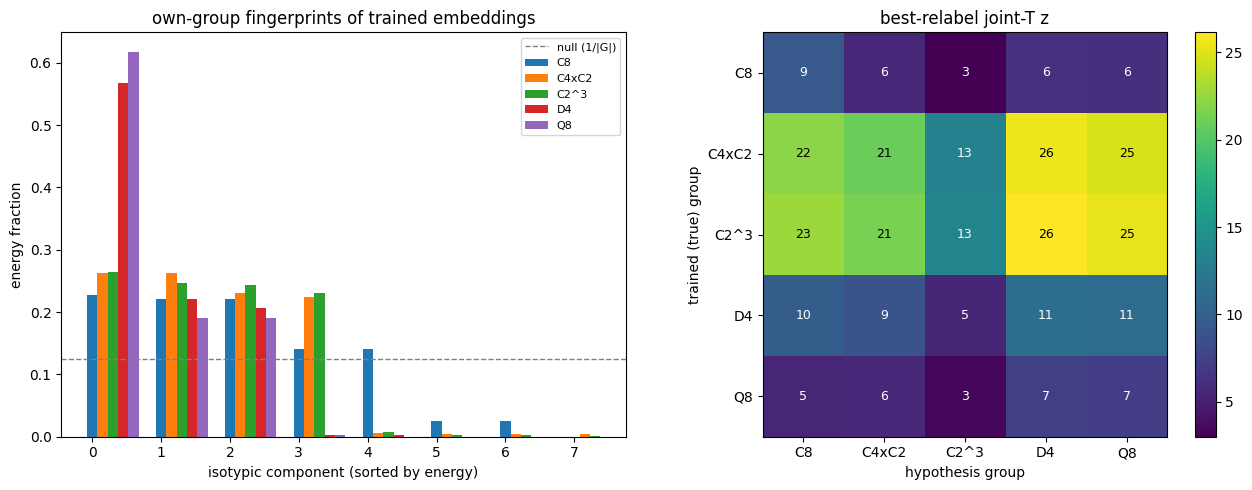

In [ ]:
"""
RP-2 PILOT v2 — Identify a finite group from a TRAINED network's parameters, using
the FULL isotypic fingerprint (not the single most-concentrated isotypic).

This is the fair follow-up to v1. Two upgrades:

  (1) REAL TRAINED NETS, not clean plants. A small MLP is trained on each group's
      composition task g1,g2 -> g1*g2; we extract the embedding matrix (rows indexed
      by group elements) and run the instrument on it. This exposes whether real nets
      actually exercise the group-DISTINGUISHING structure or settle into the shared
      substructure (the Stander/coset worry) — something a clean plant cannot tell you.

  (2) FULL-FINGERPRINT DISCRIMINATOR. v1 scored the single most-concentrated isotypic
      (max-z), which let one aligned character masquerade as a whole group. Here the
      discriminator is the standardized JOINT-T over the entire non-trivial isotypic
      profile under each candidate group: T = sum_rho z_rho^2, standardized by T's
      Monte-Carlo null under that group. A wrong group can match one isotypic but not
      the whole pattern, so the full profile is the honest test.

  LABELING is handled assumption-free: to test "does this matrix carry group H's
  structure" we search over bijections rows<->H (row-permutations of the matrix) and
  take the best standardized joint-T, against a CHANCE baseline (same search applied
  to a structureless matrix), so search inflation is accounted for. Classification =
  argmax over candidate groups; a win only counts if it clears the chance floor.

WHAT WE EXPECT GOING IN (to be confirmed/refuted, not assumed):
  - Different character tables (C8 vs C4xC2 vs C2^3 vs the D4/Q8 class) MIGHT separate
    IF the trained net exercises the distinguishing characters.
  - D4 and Q8 have identical character tables => identical isotypic profiles by
    construction => NOT separable, regardless of discriminator. (v1 confirmed this on
    clean plants; here we confirm it survives on trained nets.)

Honesty notes baked in:
  - Every construction is gated: group axioms; left-regular is a homomorphism; projectors
    idempotent/orthogonal/complete with perfect-square ranks; the MLP backprop is
    gradient-checked against finite differences before any training.
  - Each trained net reports its held-out accuracy AND its own-group concentration, so a
    net that failed to learn structure is visible, not hidden.
  - Trivial (all-ones) isotypic is dropped from the discriminator: it is shared by every
    group and is bias-like, so it carries no discriminative information.

Dependencies: numpy, matplotlib (preinstalled in Colab). Runtime: a few minutes (training
dominates; C8 is the slow one as it tends not to fully grok at order 8).
"""

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# =============================================================================
# 1. GROUPS + GROUP-ALGEBRA MACHINERY  (verified in v1)
# =============================================================================

def cyclic_product(orders):
    elems = list(product(*[range(o) for o in orders]))
    idx = {e: i for i, e in enumerate(elems)}
    n = len(elems); cay = np.zeros((n, n), int)
    for i, a in enumerate(elems):
        for j, b in enumerate(elems):
            cay[i, j] = idx[tuple((x + y) % o for x, y, o in zip(a, b, orders))]
    return cay

def dihedral_D4():
    elems = [(a, b) for a in range(4) for b in range(2)]
    idx = {e: i for i, e in enumerate(elems)}; cay = np.zeros((8, 8), int)
    for i, (a1, b1) in enumerate(elems):
        for j, (a2, b2) in enumerate(elems):
            cay[i, j] = idx[((a1 + ((-1) ** b1) * a2) % 4, (b1 + b2) % 2)]
    return cay

def quaternion_Q8():
    E = [(1,0,0,0),(-1,0,0,0),(0,1,0,0),(0,-1,0,0),(0,0,1,0),(0,0,-1,0),(0,0,0,1),(0,0,0,-1)]
    idx = {e: i for i, e in enumerate(E)}
    def qm(p, q):
        a1,b1,c1,d1 = p; a2,b2,c2,d2 = q
        return (a1*a2-b1*b2-c1*c2-d1*d2, a1*b2+b1*a2+c1*d2-d1*c2,
                a1*c2-b1*d2+c1*a2+d1*b2, a1*d2+b1*c2-c1*b2+d1*a2)
    cay = np.zeros((8, 8), int)
    for i, p in enumerate(E):
        for j, q in enumerate(E): cay[i, j] = idx[qm(p, q)]
    return cay

GROUPS = {"C8": cyclic_product([8]), "C4xC2": cyclic_product([4, 2]),
          "C2^3": cyclic_product([2, 2, 2]), "D4": dihedral_D4(), "Q8": quaternion_Q8()}

def verify_group(cay, name=""):
    n = cay.shape[0]; ar = np.arange(n)
    assert cay.min() >= 0 and cay.max() < n
    ids = [e for e in range(n) if np.array_equal(cay[e], ar) and np.array_equal(cay[:, e], ar)]
    assert len(ids) == 1, f"{name}: identity not unique"
    e = ids[0]
    for g in range(n):
        assert any(cay[g, h] == e and cay[h, g] == e for h in range(n)), f"{name}: no inverse {g}"
    for a in range(n):
        for b in range(n):
            ab = cay[a, b]
            for c in range(n):
                assert cay[ab, c] == cay[a, cay[b, c]], f"{name}: assoc fail {(a,b,c)}"
    return e

def inverses(cay, e):
    n = cay.shape[0]; return np.array([next(h for h in range(n) if cay[g, h] == e) for g in range(n)])

def conjugacy_classes(cay, e):
    n = cay.shape[0]; inv = inverses(cay, e); seen = [False]*n; cls = []
    for g in range(n):
        if seen[g]: continue
        c = {cay[cay[a, g], inv[a]] for a in range(n)}
        for x in c: seen[x] = True
        cls.append(sorted(c))
    return cls

def left_regular(cay):
    n = cay.shape[0]; L = np.zeros((n, n, n))
    for g in range(n): L[g, cay[g], np.arange(n)] = 1.0
    return L

def isotypic_projectors(cay, e, rng, max_tries=50, tol=1e-6):
    n = cay.shape[0]; L = left_regular(cay).astype(complex)
    for g in range(n):
        for h in range(n):
            assert np.allclose(L[g] @ L[h], L[cay[g, h]]), "left-regular not a rep"
    class_sums = [sum(L[g] for g in c) for c in conjugacy_classes(cay, e)]
    for _ in range(max_tries):
        c = rng.standard_normal(len(class_sums)) + 1j*rng.standard_normal(len(class_sums))
        M = sum(ck*S + np.conj(ck)*S.conj().T for ck, S in zip(c, class_sums)); M = (M + M.conj().T)/2
        w, V = np.linalg.eigh(M); spread = (w.max() - w.min()) + 1e-12
        cuts = np.where(np.diff(w) > tol*spread)[0]; groups = np.split(np.arange(n), cuts + 1)
        projs = [V[:, g] @ V[:, g].conj().T for g in groups]
        ok = np.allclose(sum(projs), np.eye(n), atol=1e-8)
        if ok:
            for P in projs:
                if not (np.allclose(P @ P, P, atol=1e-7) and np.allclose(P, P.conj().T, atol=1e-8)):
                    ok = False; break
        if ok:
            for i in range(len(projs)):
                for j in range(i+1, len(projs)):
                    if not np.allclose(projs[i] @ projs[j], 0, atol=1e-7): ok = False
        ranks = [int(round(np.trace(P).real)) for P in projs]; dims = [int(round(np.sqrt(r))) for r in ranks]
        if ok and sum(ranks) == n and all(d*d == r for d, r in zip(dims, ranks)):
            return projs, ranks, dims
    raise RuntimeError("isotypic projector construction failed gates")

def trivial_index(projs, n):
    ones = np.ones(n) / np.sqrt(n)
    return int(np.argmax([np.linalg.norm(P @ ones) for P in projs]))

def fractions(W, projs):
    tot = np.linalg.norm(W) ** 2
    return np.array([np.linalg.norm(P @ W) ** 2 / tot for P in projs])

# =============================================================================
# 2. TRAINING  (numpy MLP, gradient-checked)
# =============================================================================

def relu(x): return np.maximum(x, 0)
def softmax(z): z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)

def _mlp_grads(WE, W1, W2, g1, g2, y, d):
    X = np.concatenate([WE[g1], WE[g2]], 1); Hpre = X @ W1.T; Ha = relu(Hpre); Lg = Ha @ W2.T
    P = softmax(Lg); B = len(y); dL = P.copy(); dL[np.arange(B), y] -= 1; dL /= B
    dW2 = dL.T @ Ha; dHa = dL @ W2; dHpre = dHa * (Hpre > 0); dW1 = dHpre.T @ X; dX = dHpre @ W1
    dWE = np.zeros_like(WE); np.add.at(dWE, g1, dX[:, :d]); np.add.at(dWE, g2, dX[:, d:])
    loss = -np.log(P[np.arange(B), y] + 1e-12).mean()
    return loss, (dWE, dW1, dW2), Lg

def gradient_check():
    """Gate: analytic grads match finite differences on a tiny instance."""
    cay = cyclic_product([4]); n = 4; d = 3; H = 5; rng = np.random.default_rng(1)
    pairs = np.array([(a, b) for a in range(n) for b in range(n)]); y = np.array([cay[a, b] for a, b in pairs])
    g1, g2 = pairs[:, 0], pairs[:, 1]
    WE = rng.standard_normal((n, d)); W1 = rng.standard_normal((H, 2*d)); W2 = rng.standard_normal((n, H))
    _, (dWE, dW1, dW2), _ = _mlp_grads(WE, W1, W2, g1, g2, y, d)
    def loss_only():
        X = np.concatenate([WE[g1], WE[g2]], 1); Lg = relu(X @ W1.T) @ W2.T
        P = softmax(Lg); return -np.log(P[np.arange(len(y)), y] + 1e-12).mean()
    eps = 1e-6; err = 0.0
    for Wp, dWp in [(WE, dWE), (W1, dW1), (W2, dW2)]:
        for _ in range(15):
            i = np.random.randint(Wp.shape[0]); j = np.random.randint(Wp.shape[1]); old = Wp[i, j]
            Wp[i, j] = old + eps; lp = loss_only(); Wp[i, j] = old - eps; lm = loss_only(); Wp[i, j] = old
            err = max(err, abs((lp - lm) / (2*eps) - dWp[i, j]))
    assert err < 1e-5, f"gradient check FAILED: {err:.2e}"
    return err

def train_net(cay, d=16, H=128, frac=0.85, steps=40000, lr=2e-3, wd=1.0, seed=0):
    """Train MLP on the group-op task; return (embedding W_E [n x d], held-out accuracy)."""
    n = cay.shape[0]; rng = np.random.default_rng(seed)
    pairs = np.array([(a, b) for a in range(n) for b in range(n)]); y = np.array([cay[a, b] for a, b in pairs])
    g1a, g2a = pairs[:, 0], pairs[:, 1]
    perm = rng.permutation(len(pairs)); ntr = int(frac*len(pairs)); tr, te = perm[:ntr], perm[ntr:]
    WE = rng.standard_normal((n, d))/np.sqrt(d); W1 = rng.standard_normal((H, 2*d))/np.sqrt(2*d); W2 = rng.standard_normal((n, H))/np.sqrt(H)
    state = {id(WE): [np.zeros_like(WE), np.zeros_like(WE)], id(W1): [np.zeros_like(W1), np.zeros_like(W1)],
             id(W2): [np.zeros_like(W2), np.zeros_like(W2)]}
    he = 0.0
    for t in range(1, steps + 1):
        _, (dWE, dW1, dW2), _ = _mlp_grads(WE, W1, W2, g1a[tr], g2a[tr], y[tr], d)
        for Wp, dWp in [(W2, dW2), (W1, dW1), (WE, dWE)]:
            m, v = state[id(Wp)]; m *= 0.9; m += 0.1*dWp; v *= 0.999; v += 0.001*dWp**2
            Wp -= lr*(m/(1 - 0.9**t)/(np.sqrt(v/(1 - 0.999**t)) + 1e-8) + wd*Wp)
        if t % 5000 == 0:
            Xte = np.concatenate([WE[g1a[te]], WE[g2a[te]]], 1)
            he = float(((relu(Xte @ W1.T) @ W2.T).argmax(1) == y[te]).mean())
            if he == 1.0: break
    Xte = np.concatenate([WE[g1a[te]], WE[g2a[te]]], 1); he = float(((relu(Xte @ W1.T) @ W2.T).argmax(1) == y[te]).mean())
    return WE, he

# =============================================================================
# 3. FULL-FINGERPRINT DISCRIMINATOR  (standardized joint-T)
# =============================================================================

def mc_stats(projs, triv, n, d, n_null, rng):
    """Per-isotypic null mean/std AND null mean/std of the joint-T statistic (real Gaussian)."""
    F = np.array([fractions(rng.standard_normal((n, d)), projs) for _ in range(n_null)])
    nmean = F.mean(0); nstd = F.std(0) + 1e-12
    mask = np.ones(len(projs), bool); mask[triv] = False
    Z = (F - nmean) / nstd; T = (Z[:, mask] ** 2).sum(1)
    return nmean, nstd, mask, T.mean(), T.std() + 1e-12

def joint_T(W, projs, nmean, nstd, mask):
    z = (fractions(W, projs) - nmean) / nstd
    return (z[mask] ** 2).sum()

def zT(W, projs, st):
    nmean, nstd, mask, Tm, Ts = st
    return (joint_T(W, projs, nmean, nstd, mask) - Tm) / Ts

def best_relabel_zT(W, projs, st, n_perm, rng):
    n = W.shape[0]; best = -np.inf
    for _ in range(n_perm):
        z = zT(W[rng.permutation(n)], projs, st)
        if z > best: best = z
    return best

# =============================================================================
# 4. EXPERIMENT
# =============================================================================

def main(seeds=3, steps=40000, n_null=2000, n_perm=1500, seed0=0):
    rng = np.random.default_rng(seed0)
    names = list(GROUPS.keys())

    print("=" * 80)
    print("GATES")
    print("=" * 80)
    print(f"  MLP gradient check: max abs err = {gradient_check():.2e}")
    G = {}
    for nm in names:
        cay = GROUPS[nm]; e = verify_group(cay, nm)
        projs, ranks, dims = isotypic_projectors(cay, e, rng); triv = trivial_index(projs, len(cay))
        st = mc_stats(projs, triv, len(cay), 16, n_null, rng)
        G[nm] = dict(cay=cay, projs=projs, ranks=ranks, dims=dims, triv=triv, st=st, n=len(cay))
        print(f"  {nm:6s} OK  C-irrep dims={sorted(dims)}")
    print()

    print("=" * 80)
    print("TRAIN NETS  (best of {} seeds per group, kept by held-out acc then concentration)".format(seeds))
    print("=" * 80)
    for nm in names:
        d = G[nm]; best = None
        for s in range(seeds):
            WE, he = train_net(d["cay"], steps=steps, seed=s)
            fr = fractions(WE, d["projs"]); conc = np.sort(fr)[::-1][:3].sum()
            if best is None or (he, conc) > (best[1], best[2]): best = (WE, he, conc, fr)
        d["WE"], d["heldout"], d["conc"], d["fp"] = best
        order = np.argsort(-d["fp"]); top = ", ".join(f"d{d['dims'][k]}:{d['fp'][k]:.2f}" for k in order[:4])
        flag = "" if d["heldout"] >= 0.99 else f"  (held-out {d['heldout']:.2f} - partial grok)"
        print(f"  {nm:6s} held-out={d['heldout']:.2f}  own-group top isotypics: {top}{flag}")
    print()

    print("=" * 80)
    print("DISCRIMINATION  (full fingerprint: standardized joint-T, best over relabelings)")
    print("=" * 80)
    Z = np.zeros((len(names), len(names)))
    for i, tn in enumerate(names):
        W = G[tn]["WE"]
        for j, hn in enumerate(names):
            Z[i, j] = best_relabel_zT(W, G[hn]["projs"], G[hn]["st"], n_perm, rng)
    # chance floor per hypothesis: same search on a structureless matrix
    chance = np.array([best_relabel_zT(rng.standard_normal((G[hn]["n"], 16)), G[hn]["projs"], G[hn]["st"], n_perm, rng)
                       for hn in names])

    print("  best-relabel joint-T z under each HYPOTHESIS (cols) for each TRAINED net (rows)\n")
    print("  true\\hyp " + "".join(f"{nm:>9s}" for nm in names))
    for i, nm in enumerate(names):
        print(f"  {nm:7s} " + "".join(f"{Z[i, j]:9.1f}" for j in range(len(names))))
    print("  " + "-" * (9 + 9*len(names)))
    print("  chance   " + "".join(f"{chance[j]:9.1f}" for j in range(len(names))) + "   (structureless matrix, same search budget)")

    print("\n  classification (argmax hypothesis), and whether the winner clears chance:")
    correct = 0
    for i, nm in enumerate(names):
        j = int(np.argmax(Z[i])); pred = names[j]
        margin_self = Z[i, i] - max(Z[i, k] for k in range(len(names)) if k != i)
        clears = Z[i, j] > chance[j] + 3.0
        # D4/Q8 count as correct if classified within the {D4,Q8} class
        cls_ok = (pred == nm) or ({nm, pred} == {"D4", "Q8"})
        correct += cls_ok
        note = "correct" if pred == nm else ("D4/Q8 tie" if {nm, pred} == {"D4", "Q8"} else "** MISCLASSIFIED **")
        print(f"    {nm:6s} -> {pred:6s}  (self z={Z[i,i]:.1f}, diag margin={margin_self:+.1f}, "
              f"clears chance={clears})  {note}")
    print(f"\n  identified (counting D4/Q8 as one class): {correct}/{len(names)}")

    # ---- D4/Q8 focus ----
    print("\n" + "=" * 80)
    print("D4 / Q8 FOCUS")
    print("=" * 80)
    for tn, hn in [("D4", "Q8"), ("Q8", "D4")]:
        z_true = Z[names.index(tn), names.index(tn)]; z_cross = Z[names.index(tn), names.index(hn)]
        print(f"  {tn} net:  z under {tn} = {z_true:.1f}   z under {hn} = {z_cross:.1f}   "
              f"-> {'indistinguishable' if abs(z_true - z_cross) < 0.25*max(z_true,1) else 'separated'}")

    # ---- figures ----
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    # (a) own-group fingerprints
    ax = axes[0]; width = 0.15
    for i, nm in enumerate(names):
        fp = np.sort(G[nm]["fp"])[::-1]
        ax.bar(np.arange(len(fp)) + i*width, fp, width, label=nm)
    ax.axhline(1/8, ls="--", c="gray", lw=1, label="null (1/|G|)")
    ax.set_xlabel("isotypic component (sorted by energy)"); ax.set_ylabel("energy fraction")
    ax.set_title("own-group fingerprints of trained embeddings"); ax.legend(fontsize=8)
    # (b) confusion heatmap
    ax = axes[1]; im = ax.imshow(Z, cmap="viridis")
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names); ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
    ax.set_xlabel("hypothesis group"); ax.set_ylabel("trained (true) group")
    ax.set_title("best-relabel joint-T z")
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{Z[i,j]:.0f}", ha="center", va="center",
                    color="white" if Z[i, j] < Z.max()*0.6 else "black", fontsize=9)
    fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.savefig("discrimination_v2.png", dpi=120)
    print("\n[saved discrimination_v2.png]")
    plt.show()

if __name__ == "__main__":
    main()

GATES
  MLP gradient check: max abs err = 2.60e-10
  C8     group axioms + projectors OK
  C4xC2  group axioms + projectors OK
  C2^3   group axioms + projectors OK
  D4     group axioms + projectors OK
  Q8     group axioms + projectors OK

  absence threshold tau (99th pct of max-evidence on structureless matrices) = 4.88
  => PRESENT means max evidence exceeds what 1-in-100 structureless matrices reach.

TRAIN + TEST
  task             type     train   held   max-ev  best grp  verdict
  REAL:C4xC2       real      1.00   1.00     15.3        Q8  PRESENT
  REAL:C2^3        real      1.00   1.00     13.0      C2^3  PRESENT
  REAL:D4          real      1.00   1.00      5.0      C2^3  PRESENT
  FAKE:latin0      fake      1.00   0.00     -0.7        D4  ABSENT
  FAKE:latin1      fake      1.00   0.00     -0.6        D4  ABSENT
  FAKE:latin2      fake      1.00   0.10     -0.7        Q8  ABSENT
  RANDOM:labels    random    1.00   0.00     -0.6     C4xC2  ABSENT

VERDICT
  real groups: evid

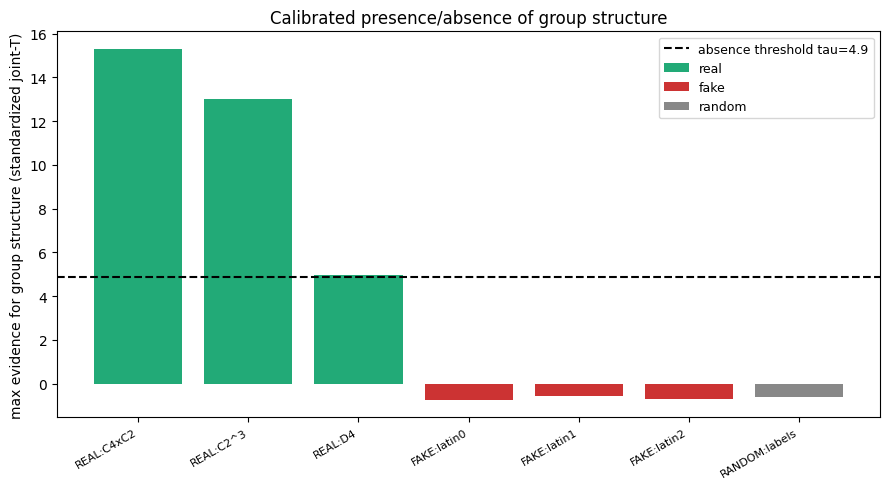

In [ ]:
"""
RP-2 PILOT — REJECTION / CALIBRATED-ABSENCE DEMO
================================================================================
The headline capability the paper is actually about: the instrument should certify
"group structure is PRESENT (above a calibrated threshold)" for a network that
learned a real group, and "ABSENT" for a network that learned an equally-fittable
task with no group structure.

Three kinds of training target, all order 8, all trained in the SAME regime:
  - REAL GROUPS (C4xC2, C2^3, D4): these grok and develop genuine irrep structure.
  - FAKE GROUPS (random Latin squares): a valid multiplication table where every row
      and column is a permutation (so the task is just as well-defined and fittable),
      but NON-ASSOCIATIVE and not a relabeled group => no representation-theoretic
      structure. THIS IS THE CRITICAL CONTROL: a clean instrument must read "absent".
  - RANDOM LABELS (a random function): a sanity floor; clearly no structure.

The instrument's question per net: project the embedding under EACH of the five
order-8 groups, take the standardized joint-T (whole-profile detection statistic),
and report the MAX over the five = "best evidence for ANY group structure".

CALIBRATION: the absence threshold tau is the 99th percentile of that same max-over-
groups statistic computed on structureless (random Gaussian) matrices. So "ABSENT"
means "max evidence below what 1-in-100 structureless matrices reach" — a calibrated
absence claim, not an eyeballed one.

A clean win: real groups land far above tau; fake-group and random nets land below it.
A loss is informative too: if a fake-group net reads PRESENT, the absence claim is
shakier than hoped, and better to learn it now.

Honesty notes baked in:
  - Gradient check on the MLP backprop before training; group axioms, homomorphism,
    projector idempotency/orthogonality/completeness gates; Latin-property and
    NON-ASSOCIATIVITY gates on every fake group (so it is provably not a group).
  - Every net reports train AND held-out accuracy: real groups generalize (~1.0),
    fakes/random only memorize (held-out ~ chance). That asymmetry is the SIGNATURE
    of structure vs none; the instrument's job is to add that the present structure is
    specifically group-representation-theoretic.
  - Known caveat printed at the end: this shows the instrument separates "grokked group"
    from "memorized non-group"; whether it is detecting group structure specifically vs
    merely concentrated/low-rank embeddings is a follow-up control, noted not hidden.

Dependencies: numpy, matplotlib (preinstalled in Colab). Runtime: a few minutes.
"""

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# =============================================================================
# 1. GROUPS + GROUP-ALGEBRA MACHINERY  (verified in earlier pilots)
# =============================================================================

def cyclic_product(orders):
    elems = list(product(*[range(o) for o in orders])); idx = {e: i for i, e in enumerate(elems)}
    n = len(elems); cay = np.zeros((n, n), int)
    for i, a in enumerate(elems):
        for j, b in enumerate(elems):
            cay[i, j] = idx[tuple((x + y) % o for x, y, o in zip(a, b, orders))]
    return cay

def dihedral_D4():
    elems = [(a, b) for a in range(4) for b in range(2)]; idx = {e: i for i, e in enumerate(elems)}
    cay = np.zeros((8, 8), int)
    for i, (a1, b1) in enumerate(elems):
        for j, (a2, b2) in enumerate(elems):
            cay[i, j] = idx[((a1 + ((-1) ** b1) * a2) % 4, (b1 + b2) % 2)]
    return cay

def quaternion_Q8():
    E = [(1,0,0,0),(-1,0,0,0),(0,1,0,0),(0,-1,0,0),(0,0,1,0),(0,0,-1,0),(0,0,0,1),(0,0,0,-1)]
    idx = {e: i for i, e in enumerate(E)}
    def qm(p, q):
        a1,b1,c1,d1 = p; a2,b2,c2,d2 = q
        return (a1*a2-b1*b2-c1*c2-d1*d2, a1*b2+b1*a2+c1*d2-d1*c2,
                a1*c2-b1*d2+c1*a2+d1*b2, a1*d2+b1*c2-c1*b2+d1*a2)
    cay = np.zeros((8, 8), int)
    for i, p in enumerate(E):
        for j, q in enumerate(E): cay[i, j] = idx[qm(p, q)]
    return cay

CANDIDATE_GROUPS = {"C8": cyclic_product([8]), "C4xC2": cyclic_product([4, 2]),
                    "C2^3": cyclic_product([2, 2, 2]), "D4": dihedral_D4(), "Q8": quaternion_Q8()}

def verify_group(cay, name=""):
    n = cay.shape[0]; ar = np.arange(n); assert cay.min() >= 0 and cay.max() < n
    ids = [e for e in range(n) if np.array_equal(cay[e], ar) and np.array_equal(cay[:, e], ar)]
    assert len(ids) == 1, f"{name}: identity not unique"; e = ids[0]
    for g in range(n):
        assert any(cay[g, h] == e and cay[h, g] == e for h in range(n)), f"{name}: no inverse {g}"
    for a in range(n):
        for b in range(n):
            ab = cay[a, b]
            for c in range(n):
                assert cay[ab, c] == cay[a, cay[b, c]], f"{name}: assoc fail {(a,b,c)}"
    return e

def inverses(cay, e):
    n = cay.shape[0]; return np.array([next(h for h in range(n) if cay[g, h] == e) for g in range(n)])

def conjugacy_classes(cay, e):
    n = cay.shape[0]; inv = inverses(cay, e); seen = [False]*n; cls = []
    for g in range(n):
        if seen[g]: continue
        c = {cay[cay[a, g], inv[a]] for a in range(n)}
        for x in c: seen[x] = True
        cls.append(sorted(c))
    return cls

def left_regular(cay):
    n = cay.shape[0]; L = np.zeros((n, n, n))
    for g in range(n): L[g, cay[g], np.arange(n)] = 1.0
    return L

def isotypic_projectors(cay, e, rng, max_tries=50, tol=1e-6):
    n = cay.shape[0]; L = left_regular(cay).astype(complex)
    for g in range(n):
        for h in range(n):
            assert np.allclose(L[g] @ L[h], L[cay[g, h]]), "left-regular not a rep"
    class_sums = [sum(L[g] for g in c) for c in conjugacy_classes(cay, e)]
    for _ in range(max_tries):
        c = rng.standard_normal(len(class_sums)) + 1j*rng.standard_normal(len(class_sums))
        M = sum(ck*S + np.conj(ck)*S.conj().T for ck, S in zip(c, class_sums)); M = (M + M.conj().T)/2
        w, V = np.linalg.eigh(M); spread = (w.max() - w.min()) + 1e-12
        cuts = np.where(np.diff(w) > tol*spread)[0]; groups = np.split(np.arange(n), cuts + 1)
        projs = [V[:, g] @ V[:, g].conj().T for g in groups]
        ok = np.allclose(sum(projs), np.eye(n), atol=1e-8)
        if ok:
            for P in projs:
                if not (np.allclose(P @ P, P, atol=1e-7) and np.allclose(P, P.conj().T, atol=1e-8)): ok = False; break
        if ok:
            for i in range(len(projs)):
                for j in range(i+1, len(projs)):
                    if not np.allclose(projs[i] @ projs[j], 0, atol=1e-7): ok = False
        ranks = [int(round(np.trace(P).real)) for P in projs]; dims = [int(round(np.sqrt(r))) for r in ranks]
        if ok and sum(ranks) == n and all(d*d == r for d, r in zip(dims, ranks)):
            return projs, ranks, dims
    raise RuntimeError("isotypic projector construction failed gates")

def trivial_index(projs, n):
    ones = np.ones(n)/np.sqrt(n); return int(np.argmax([np.linalg.norm(P @ ones) for P in projs]))

def fractions(W, projs):
    tot = np.linalg.norm(W) ** 2; return np.array([np.linalg.norm(P @ W) ** 2 / tot for P in projs])

# =============================================================================
# 2. FAKE GROUPS (non-group Latin squares) + random function
# =============================================================================

def random_latin_square(n, rng):
    """Backtracking generator -> a random Latin square (rows & cols are permutations)."""
    L = -np.ones((n, n), int)
    def solve(pos):
        if pos == n*n: return True
        i, j = divmod(pos, n)
        used = set(L[i, :j].tolist()) | set(L[:i, j].tolist())
        choices = [c for c in range(n) if c not in used]; rng.shuffle(choices)
        for c in choices:
            L[i, j] = c
            if solve(pos + 1): return True
            L[i, j] = -1
        return False
    assert solve(0), "Latin square generation failed"
    return L

def is_latin(L):
    n = L.shape[0]; ar = set(range(n))
    return all(set(L[i, :].tolist()) == ar for i in range(n)) and all(set(L[:, j].tolist()) == ar for j in range(n))

def is_associative(L):
    n = L.shape[0]
    for a in range(n):
        for b in range(n):
            for c in range(n):
                if L[L[a, b], c] != L[a, L[b, c]]: return False
    return True

def make_fake_group(n, rng):
    """A Latin square that is provably NOT a group (Latin + non-associative)."""
    for _ in range(50):
        L = random_latin_square(n, rng)
        if is_latin(L) and not is_associative(L):
            return L
    raise RuntimeError("could not make non-associative Latin square")

def random_function_table(n, rng):
    """A random function (a,b)->c (NOT a Latin square): the structureless sanity floor."""
    return rng.integers(0, n, size=(n, n))

# =============================================================================
# 3. TRAINING (numpy MLP, gradient-checked)
# =============================================================================

def relu(x): return np.maximum(x, 0)
def softmax(z): z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)

def _mlp_grads(WE, W1, W2, g1, g2, y, d):
    X = np.concatenate([WE[g1], WE[g2]], 1); Hpre = X @ W1.T; Ha = relu(Hpre); Lg = Ha @ W2.T
    P = softmax(Lg); B = len(y); dL = P.copy(); dL[np.arange(B), y] -= 1; dL /= B
    dW2 = dL.T @ Ha; dHa = dL @ W2; dHpre = dHa * (Hpre > 0); dW1 = dHpre.T @ X; dX = dHpre @ W1
    dWE = np.zeros_like(WE); np.add.at(dWE, g1, dX[:, :d]); np.add.at(dWE, g2, dX[:, d:])
    return (dWE, dW1, dW2)

def gradient_check():
    cay = cyclic_product([4]); n = 4; d = 3; H = 5; rng = np.random.default_rng(1)
    pairs = np.array([(a, b) for a in range(n) for b in range(n)]); y = np.array([cay[a, b] for a, b in pairs])
    g1, g2 = pairs[:, 0], pairs[:, 1]
    WE = rng.standard_normal((n, d)); W1 = rng.standard_normal((H, 2*d)); W2 = rng.standard_normal((n, H))
    dWE, dW1, dW2 = _mlp_grads(WE, W1, W2, g1, g2, y, d)
    def loss_only():
        X = np.concatenate([WE[g1], WE[g2]], 1); P = softmax(relu(X @ W1.T) @ W2.T)
        return -np.log(P[np.arange(len(y)), y] + 1e-12).mean()
    eps = 1e-6; err = 0.0
    for Wp, dWp in [(WE, dWE), (W1, dW1), (W2, dW2)]:
        for _ in range(15):
            i = np.random.randint(Wp.shape[0]); j = np.random.randint(Wp.shape[1]); old = Wp[i, j]
            Wp[i, j] = old + eps; lp = loss_only(); Wp[i, j] = old - eps; lm = loss_only(); Wp[i, j] = old
            err = max(err, abs((lp - lm)/(2*eps) - dWp[i, j]))
    assert err < 1e-5, f"gradient check FAILED {err:.2e}"
    return err

def train_table(table, d=16, H=128, frac=0.85, steps=30000, lr=2e-3, wd=1.0, seed=0):
    """Train MLP on (a,b)->table[a,b]; return (embedding, train_acc, heldout_acc)."""
    n = table.shape[0]; rng = np.random.default_rng(seed)
    pairs = np.array([(a, b) for a in range(n) for b in range(n)]); y = np.array([table[a, b] for a, b in pairs])
    g1a, g2a = pairs[:, 0], pairs[:, 1]
    perm = rng.permutation(len(pairs)); ntr = int(frac*len(pairs)); tr, te = perm[:ntr], perm[ntr:]
    WE = rng.standard_normal((n, d))/np.sqrt(d); W1 = rng.standard_normal((H, 2*d))/np.sqrt(2*d); W2 = rng.standard_normal((n, H))/np.sqrt(H)
    state = {id(WE): [np.zeros_like(WE), np.zeros_like(WE)], id(W1): [np.zeros_like(W1), np.zeros_like(W1)],
             id(W2): [np.zeros_like(W2), np.zeros_like(W2)]}
    def acc(idx):
        X = np.concatenate([WE[g1a[idx]], WE[g2a[idx]]], 1); return float(((relu(X @ W1.T) @ W2.T).argmax(1) == y[idx]).mean())
    for t in range(1, steps + 1):
        dWE, dW1, dW2 = _mlp_grads(WE, W1, W2, g1a[tr], g2a[tr], y[tr], d)
        for Wp, dWp in [(W2, dW2), (W1, dW1), (WE, dWE)]:
            m, v = state[id(Wp)]; m *= 0.9; m += 0.1*dWp; v *= 0.999; v += 0.001*dWp**2
            Wp -= lr*(m/(1 - 0.9**t)/(np.sqrt(v/(1 - 0.999**t)) + 1e-8) + wd*Wp)
        if t % 5000 == 0 and acc(te) == 1.0: break
    return WE, acc(tr), acc(te)

# =============================================================================
# 4. INSTRUMENT: standardized joint-T, max over candidate groups
# =============================================================================

def mc_stats(projs, triv, n, d, n_null, rng):
    F = np.array([fractions(rng.standard_normal((n, d)), projs) for _ in range(n_null)])
    nmean = F.mean(0); nstd = F.std(0) + 1e-12
    mask = np.ones(len(projs), bool); mask[triv] = False
    Z = (F - nmean)/nstd; T = (Z[:, mask] ** 2).sum(1)
    return nmean, nstd, mask, T.mean(), T.std() + 1e-12

def zT(W, projs, st):
    nmean, nstd, mask, Tm, Ts = st
    z = (fractions(W, projs) - nmean)/nstd
    return ((z[mask] ** 2).sum() - Tm)/Ts

def max_evidence(W, G):
    """Best standardized joint-T over all candidate groups = evidence for ANY group structure."""
    zs = {nm: zT(W, G[nm]["projs"], G[nm]["st"]) for nm in G}
    best = max(zs, key=zs.get)
    return zs[best], best, zs

# =============================================================================
# 5. EXPERIMENT
# =============================================================================

def main(n_null=2000, n_calib=2000, seed0=0):
    rng = np.random.default_rng(seed0); n = 8

    print("=" * 80); print("GATES"); print("=" * 80)
    print(f"  MLP gradient check: max abs err = {gradient_check():.2e}")
    G = {}
    for nm, cay in CANDIDATE_GROUPS.items():
        e = verify_group(cay, nm); projs, ranks, dims = isotypic_projectors(cay, e, rng)
        triv = trivial_index(projs, n); st = mc_stats(projs, triv, n, 16, n_null, rng)
        G[nm] = dict(projs=projs, st=st); print(f"  {nm:6s} group axioms + projectors OK")

    # calibrate absence threshold tau = 99th pct of max-evidence over structureless matrices
    null_max = np.sort([max_evidence(rng.standard_normal((n, 16)), G)[0] for _ in range(n_calib)])
    tau = null_max[int(0.99 * n_calib)]
    print(f"\n  absence threshold tau (99th pct of max-evidence on structureless matrices) = {tau:.2f}")
    print("  => PRESENT means max evidence exceeds what 1-in-100 structureless matrices reach.\n")

    # build the set of tasks
    tasks = []
    for nm in ["C4xC2", "C2^3", "D4"]:
        tasks.append(("REAL:" + nm, "real", CANDIDATE_GROUPS[nm]))
    for k in range(3):
        tasks.append((f"FAKE:latin{k}", "fake", make_fake_group(n, rng)))
    tasks.append(("RANDOM:labels", "random", random_function_table(n, rng)))

    print("=" * 80); print("TRAIN + TEST"); print("=" * 80)
    print(f"  {'task':16s} {'type':7s} {'train':>6s} {'held':>6s} {'max-ev':>8s} {'best grp':>9s}  verdict")
    rows = []
    for name, kind, table in tasks:
        if kind == "real":
            best = None
            for s in range(2):
                WE, tr, he = train_table(table, seed=s)
                ev = max_evidence(WE, G)[0]
                if best is None or (he, ev) > (best[2], best[3]): best = (WE, tr, he, ev)
            WE, tr, he, _ = best
        else:
            WE, tr, he = train_table(table, seed=0)
        ev, grp, _ = max_evidence(WE, G)
        verdict = "PRESENT" if ev > tau else "ABSENT"
        rows.append((name, kind, tr, he, ev, grp, verdict))
        print(f"  {name:16s} {kind:7s} {tr:6.2f} {he:6.2f} {ev:8.1f} {grp:>9s}  {verdict}")

    print("\n" + "=" * 80); print("VERDICT"); print("=" * 80)
    real_ev = [r[4] for r in rows if r[1] == "real"]; other_ev = [r[4] for r in rows if r[1] != "real"]
    real_ok = all(r[6] == "PRESENT" for r in rows if r[1] == "real")
    other_ok = all(r[6] == "ABSENT" for r in rows if r[1] != "real")
    print(f"  real groups: evidence {np.round(real_ev,1).tolist()}  (all PRESENT: {real_ok})")
    print(f"  non-groups : evidence {np.round(other_ev,1).tolist()}  (all ABSENT:  {other_ok})")
    print(f"  threshold tau = {tau:.2f}")
    if real_ok and other_ok:
        print("\n  CLEAN SEPARATION: the instrument certifies group structure present for real")
        print("  groups and absent for non-group / random tasks. The calibrated-absence claim holds.")
    else:
        print("\n  NOT a clean separation -- the absence claim is shakier than hoped; inspect which")
        print("  non-group task read PRESENT (or which real group read ABSENT) and why.")
    print("\n  CAVEAT (not hidden): this separates 'grokked real group' from 'memorized non-group'.")
    print("  Whether the instrument keys on group structure specifically vs merely concentrated")
    print("  embeddings needs a further control (a concentrated-but-non-group representation).")

    # figure
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = {"real": "#2a7", "fake": "#c33", "random": "#888"}
    for i, (name, kind, tr, he, ev, grp, verdict) in enumerate(rows):
        ax.bar(i, ev, color=colors[kind], label=kind if kind not in [r[1] for r in rows[:i]] else "")
    ax.axhline(tau, ls="--", c="k", lw=1.5, label=f"absence threshold tau={tau:.1f}")
    ax.set_xticks(range(len(rows))); ax.set_xticklabels([r[0] for r in rows], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("max evidence for group structure (standardized joint-T)")
    ax.set_title("Calibrated presence/absence of group structure"); ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig("rejection_demo.png", dpi=120)
    print("\n[saved rejection_demo.png]"); plt.show()

if __name__ == "__main__":
    main()

GATES
  MLP gradient check: max abs err = 2.72e-10
  C8     OK
  C4xC2  OK
  C2^3   OK
  D4     OK
  Q8     OK

TRAIN 4 NETS PER GROUP
  C8     held-out per seed: ['0.50', '0.30', '0.00', '0.10']
  C4xC2  held-out per seed: ['1.00', '0.80', '1.00', '1.00']
  C2^3   held-out per seed: ['1.00', '1.00', '1.00', '1.00']
  D4     held-out per seed: ['1.00', '1.00', '0.70', '1.00']
  Q8     held-out per seed: ['0.00', '0.00', '0.00', '0.00']

CLASSIFY (leave-one-out, template match, relabel-searched)
  confusion matrix (rows = true group, cols = predicted; counts over query nets)

  true\pred      C8  C4xC2   C2^3     D4     Q8
  C8             2      0      0      0      2
  C4xC2          4      0      0      0      0
  C2^3           3      0      1      0      0
  D4             2      0      0      0      2
  Q8             1      0      0      0      3

  accuracy (counting D4/Q8 as one class): 8/20 = 0.40

READOUT vs v2 (joint-T)
  v2 with joint-T misclassified C4xC2 and C2^3 as D4 (t

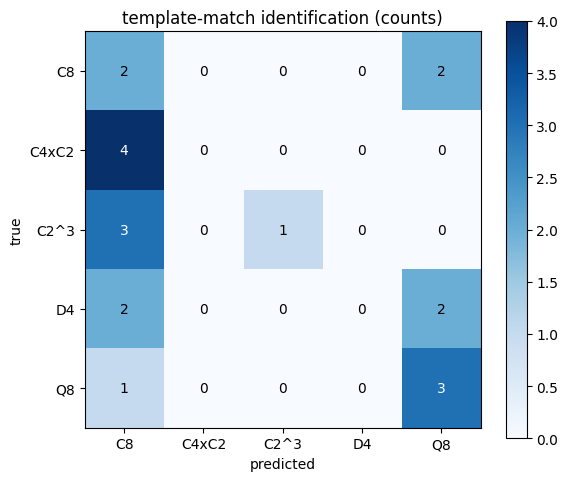

In [ ]:
"""
RP-2 PILOT — OPTION 2: TEMPLATE / PROFILE-SHAPE DISCRIMINATOR for group identification
================================================================================
v2 used joint-T (a DETECTION statistic): it measured how concentrated a matrix is,
not whose fingerprint it matches. The failure mechanism: an abelian net (sharp rank-1
spikes) scored high under D4 because, relabeled, its energy fell into D4's four 1-d
isotypics while leaving D4's 4-dimensional (2-d irrep) isotypic empty -- which joint-T
never penalized, even though a real D4 net fills that isotypic at ~0.57.

This discriminator fixes exactly that. For each candidate group H it builds a TEMPLATE:
the characteristic isotypic profile that REAL H-nets produce. A query net is classified
by which template its full profile best matches:

    score(query, H) = min over relabelings of  mean_i [ (p_sorted_i - mu^H_i) / sigma^H_i )^2 ]

i.e. diagonal-Mahalanobis distance from H's characteristic profile, minimized over the
unknown row<->element correspondence (relabeling search), with profiles sorted so that
same-dimension isotypics (which are interchangeable) don't create a spurious mismatch.
predicted group = argmin_H score. The D4 2-d isotypic is now a high-weight feature an
abelian imposter cannot fake, because leaving it empty is itself a large distance.

Leave-one-out: a query net is NEVER part of its own group's template, so a net is not
matched against itself.

WHAT A RESULT MEANS:
  - If abelians (C4xC2, C2^3) now classify as themselves, identification WORKS -- up to
    the permanent D4/Q8 tie (identical character tables => identical profiles).
  - If they still misclassify, identification is genuinely dead, not a statistic artifact,
    and should be dropped from the paper.

Honesty notes baked in: gradient-checked backprop; group/projector gates; the template
approach is supervised (it needs labeled reference nets per candidate group) -- stated,
not hidden; each net reports held-out accuracy + concentration so weak nets are visible.

Dependencies: numpy, matplotlib (preinstalled in Colab). Runtime: a few minutes.
"""

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# =============================================================================
# 1. GROUPS + GROUP-ALGEBRA MACHINERY  (verified in earlier pilots)
# =============================================================================

def cyclic_product(orders):
    elems = list(product(*[range(o) for o in orders])); idx = {e: i for i, e in enumerate(elems)}
    n = len(elems); cay = np.zeros((n, n), int)
    for i, a in enumerate(elems):
        for j, b in enumerate(elems):
            cay[i, j] = idx[tuple((x + y) % o for x, y, o in zip(a, b, orders))]
    return cay

def dihedral_D4():
    elems = [(a, b) for a in range(4) for b in range(2)]; idx = {e: i for i, e in enumerate(elems)}
    cay = np.zeros((8, 8), int)
    for i, (a1, b1) in enumerate(elems):
        for j, (a2, b2) in enumerate(elems):
            cay[i, j] = idx[((a1 + ((-1) ** b1) * a2) % 4, (b1 + b2) % 2)]
    return cay

def quaternion_Q8():
    E = [(1,0,0,0),(-1,0,0,0),(0,1,0,0),(0,-1,0,0),(0,0,1,0),(0,0,-1,0),(0,0,0,1),(0,0,0,-1)]
    idx = {e: i for i, e in enumerate(E)}
    def qm(p, q):
        a1,b1,c1,d1 = p; a2,b2,c2,d2 = q
        return (a1*a2-b1*b2-c1*c2-d1*d2, a1*b2+b1*a2+c1*d2-d1*c2,
                a1*c2-b1*d2+c1*a2+d1*b2, a1*d2+b1*c2-c1*b2+d1*a2)
    cay = np.zeros((8, 8), int)
    for i, p in enumerate(E):
        for j, q in enumerate(E): cay[i, j] = idx[qm(p, q)]
    return cay

GROUPS = {"C8": cyclic_product([8]), "C4xC2": cyclic_product([4, 2]),
          "C2^3": cyclic_product([2, 2, 2]), "D4": dihedral_D4(), "Q8": quaternion_Q8()}

def verify_group(cay, name=""):
    n = cay.shape[0]; ar = np.arange(n); assert cay.min() >= 0 and cay.max() < n
    ids = [e for e in range(n) if np.array_equal(cay[e], ar) and np.array_equal(cay[:, e], ar)]
    assert len(ids) == 1; e = ids[0]
    for g in range(n):
        assert any(cay[g, h] == e and cay[h, g] == e for h in range(n))
    for a in range(n):
        for b in range(n):
            ab = cay[a, b]
            for c in range(n):
                assert cay[ab, c] == cay[a, cay[b, c]]
    return e

def inverses(cay, e):
    n = cay.shape[0]; return np.array([next(h for h in range(n) if cay[g, h] == e) for g in range(n)])

def conjugacy_classes(cay, e):
    n = cay.shape[0]; inv = inverses(cay, e); seen = [False]*n; cls = []
    for g in range(n):
        if seen[g]: continue
        c = {cay[cay[a, g], inv[a]] for a in range(n)}
        for x in c: seen[x] = True
        cls.append(sorted(c))
    return cls

def left_regular(cay):
    n = cay.shape[0]; L = np.zeros((n, n, n))
    for g in range(n): L[g, cay[g], np.arange(n)] = 1.0
    return L

def isotypic_projectors(cay, e, rng, max_tries=50, tol=1e-6):
    n = cay.shape[0]; L = left_regular(cay).astype(complex)
    for g in range(n):
        for h in range(n):
            assert np.allclose(L[g] @ L[h], L[cay[g, h]])
    class_sums = [sum(L[g] for g in c) for c in conjugacy_classes(cay, e)]
    for _ in range(max_tries):
        c = rng.standard_normal(len(class_sums)) + 1j*rng.standard_normal(len(class_sums))
        M = sum(ck*S + np.conj(ck)*S.conj().T for ck, S in zip(c, class_sums)); M = (M + M.conj().T)/2
        w, V = np.linalg.eigh(M); spread = (w.max() - w.min()) + 1e-12
        cuts = np.where(np.diff(w) > tol*spread)[0]; groups = np.split(np.arange(n), cuts + 1)
        projs = [V[:, g] @ V[:, g].conj().T for g in groups]
        ok = np.allclose(sum(projs), np.eye(n), atol=1e-8)
        if ok:
            for P in projs:
                if not (np.allclose(P @ P, P, atol=1e-7) and np.allclose(P, P.conj().T, atol=1e-8)): ok = False; break
        if ok:
            for i in range(len(projs)):
                for j in range(i+1, len(projs)):
                    if not np.allclose(projs[i] @ projs[j], 0, atol=1e-7): ok = False
        ranks = [int(round(np.trace(P).real)) for P in projs]; dims = [int(round(np.sqrt(r))) for r in ranks]
        if ok and sum(ranks) == n and all(d*d == r for d, r in zip(dims, ranks)):
            return projs, ranks, dims
    raise RuntimeError("projector gates failed")

def fractions(W, projs):
    tot = np.linalg.norm(W) ** 2; return np.array([np.linalg.norm(P @ W) ** 2 / tot for P in projs])

def sorted_profile(W, projs):
    """Labeling-invariant (within dimension class) profile = fractions sorted descending."""
    return np.sort(fractions(W, projs))[::-1]

# =============================================================================
# 2. TRAINING  (numpy MLP, gradient-checked)
# =============================================================================

def relu(x): return np.maximum(x, 0)
def softmax(z): z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)

def _mlp_grads(WE, W1, W2, g1, g2, y, d):
    X = np.concatenate([WE[g1], WE[g2]], 1); Hpre = X @ W1.T; Ha = relu(Hpre); Lg = Ha @ W2.T
    P = softmax(Lg); B = len(y); dL = P.copy(); dL[np.arange(B), y] -= 1; dL /= B
    dW2 = dL.T @ Ha; dHa = dL @ W2; dHpre = dHa * (Hpre > 0); dW1 = dHpre.T @ X; dX = dHpre @ W1
    dWE = np.zeros_like(WE); np.add.at(dWE, g1, dX[:, :d]); np.add.at(dWE, g2, dX[:, d:])
    return dWE, dW1, dW2

def gradient_check():
    cay = cyclic_product([4]); n = 4; d = 3; H = 5; rng = np.random.default_rng(1)
    pairs = np.array([(a, b) for a in range(n) for b in range(n)]); y = np.array([cay[a, b] for a, b in pairs])
    g1, g2 = pairs[:, 0], pairs[:, 1]
    WE = rng.standard_normal((n, d)); W1 = rng.standard_normal((H, 2*d)); W2 = rng.standard_normal((n, H))
    dWE, dW1, dW2 = _mlp_grads(WE, W1, W2, g1, g2, y, d)
    def loss_only():
        P = softmax(relu(np.concatenate([WE[g1], WE[g2]], 1) @ W1.T) @ W2.T)
        return -np.log(P[np.arange(len(y)), y] + 1e-12).mean()
    eps = 1e-6; err = 0.0
    for Wp, dWp in [(WE, dWE), (W1, dW1), (W2, dW2)]:
        for _ in range(15):
            i = np.random.randint(Wp.shape[0]); j = np.random.randint(Wp.shape[1]); old = Wp[i, j]
            Wp[i, j] = old + eps; lp = loss_only(); Wp[i, j] = old - eps; lm = loss_only(); Wp[i, j] = old
            err = max(err, abs((lp - lm)/(2*eps) - dWp[i, j]))
    assert err < 1e-5, f"gradient check FAILED {err:.2e}"
    return err

def train_net(cay, d=16, H=128, frac=0.85, steps=30000, lr=2e-3, wd=1.0, seed=0):
    n = cay.shape[0]; rng = np.random.default_rng(seed)
    pairs = np.array([(a, b) for a in range(n) for b in range(n)]); y = np.array([cay[a, b] for a, b in pairs])
    g1a, g2a = pairs[:, 0], pairs[:, 1]
    perm = rng.permutation(len(pairs)); ntr = int(frac*len(pairs)); tr, te = perm[:ntr], perm[ntr:]
    WE = rng.standard_normal((n, d))/np.sqrt(d); W1 = rng.standard_normal((H, 2*d))/np.sqrt(2*d); W2 = rng.standard_normal((n, H))/np.sqrt(H)
    state = {id(WE): [np.zeros_like(WE), np.zeros_like(WE)],
             id(W1): [np.zeros_like(W1), np.zeros_like(W1)], id(W2): [np.zeros_like(W2), np.zeros_like(W2)]}
    def acc(idx):
        return float(((relu(np.concatenate([WE[g1a[idx]], WE[g2a[idx]]], 1) @ W1.T) @ W2.T).argmax(1) == y[idx]).mean())
    for t in range(1, steps + 1):
        dWE, dW1, dW2 = _mlp_grads(WE, W1, W2, g1a[tr], g2a[tr], y[tr], d)
        for Wp, dWp in [(W2, dW2), (W1, dW1), (WE, dWE)]:
            m, v = state[id(Wp)]; m *= 0.9; m += 0.1*dWp; v *= 0.999; v += 0.001*dWp**2
            Wp -= lr*(m/(1 - 0.9**t)/(np.sqrt(v/(1 - 0.999**t)) + 1e-8) + wd*Wp)
        if t % 5000 == 0 and acc(te) == 1.0: break
    return WE, acc(te)

# =============================================================================
# 3. TEMPLATE DISCRIMINATOR
# =============================================================================

def template(profiles):
    """mu, sigma of a set of sorted profiles (sigma floored to avoid blow-up)."""
    P = np.array(profiles); return P.mean(0), np.maximum(P.std(0), 0.02)

def match_score(W, projs, mu, sig, n_perm, rng):
    """min over relabelings of mean diagonal-Mahalanobis distance to (mu, sig). Lower = better match."""
    n = W.shape[0]; best = np.inf
    for _ in range(n_perm):
        p = sorted_profile(W[rng.permutation(n)], projs)
        best = min(best, float((((p - mu) / sig) ** 2).mean()))
    return best

# =============================================================================
# 4. EXPERIMENT
# =============================================================================

def main(nets_per_group=4, steps=30000, n_perm=1000, seed0=0):
    rng = np.random.default_rng(seed0); names = list(GROUPS.keys())

    print("=" * 80); print("GATES"); print("=" * 80)
    print(f"  MLP gradient check: max abs err = {gradient_check():.2e}")
    G = {}
    for nm, cay in GROUPS.items():
        e = verify_group(cay, nm); projs, ranks, dims = isotypic_projectors(cay, e, rng)
        G[nm] = dict(projs=projs, dims=dims); print(f"  {nm:6s} OK")
    print()

    print("=" * 80); print(f"TRAIN {nets_per_group} NETS PER GROUP"); print("=" * 80)
    for nm in names:
        nets = []
        for s in range(nets_per_group):
            WE, he = train_net(GROUPS[nm], steps=steps, seed=s)
            nets.append(dict(WE=WE, he=he, prof=sorted_profile(WE, G[nm]["projs"])))
        G[nm]["nets"] = nets
        hes = [f"{x['he']:.2f}" for x in nets]
        print(f"  {nm:6s} held-out per seed: {hes}")
    print()

    print("=" * 80); print("CLASSIFY (leave-one-out, template match, relabel-searched)"); print("=" * 80)
    conf = np.zeros((len(names), len(names)), int)
    for ti, tn in enumerate(names):
        for qi in range(nets_per_group):
            qW = G[tn]["nets"][qi]["WE"]
            scores = {}
            for hn in names:
                if hn == tn:
                    profs = [G[tn]["nets"][k]["prof"] for k in range(nets_per_group) if k != qi]
                else:
                    profs = [x["prof"] for x in G[hn]["nets"]]
                mu, sig = template(profs)
                scores[hn] = match_score(qW, G[hn]["projs"], mu, sig, n_perm, rng)
            pred = min(scores, key=scores.get)
            conf[ti, names.index(pred)] += 1
    # report
    print("  confusion matrix (rows = true group, cols = predicted; counts over query nets)\n")
    print("  true\\pred " + "".join(f"{nm:>7s}" for nm in names))
    for i, nm in enumerate(names):
        print(f"  {nm:7s}  " + "".join(f"{conf[i, j]:7d}" for j in range(len(names))))

    correct = 0; total = 0
    for i, nm in enumerate(names):
        for j, pn in enumerate(names):
            if conf[i, j] == 0: continue
            total += conf[i, j]
            if pn == nm or {nm, pn} == {"D4", "Q8"}: correct += conf[i, j]
    print(f"\n  accuracy (counting D4/Q8 as one class): {correct}/{total} = {correct/total:.2f}")

    print("\n" + "=" * 80); print("READOUT vs v2 (joint-T)"); print("=" * 80)
    print("  v2 with joint-T misclassified C4xC2 and C2^3 as D4 (the imposter problem).")
    ab_ok = all(conf[names.index(nm), names.index(nm)] >= conf[names.index(nm)].max()
                for nm in ["C4xC2", "C2^3"])
    for nm in ["C4xC2", "C2^3", "C8"]:
        i = names.index(nm); pred = names[int(np.argmax(conf[i]))]
        print(f"    {nm:6s}: now mostly classified as {pred}  ({conf[i, i]}/{conf[i].sum()} correct)")
    if ab_ok:
        print("\n  => template matching FIXED the abelian misclassification. Identification works")
        print("     up to the D4/Q8 tie. This is a real (if modest, toy-scale) secondary result.")
    else:
        print("\n  => template matching did NOT cleanly fix it. Identification is genuinely hard,")
        print("     not just a statistic artifact -- recommend dropping it from the paper.")

    fig, ax = plt.subplots(figsize=(6, 5)); im = ax.imshow(conf, cmap="Blues")
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names); ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("template-match identification (counts)")
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, conf[i, j], ha="center", va="center",
                    color="white" if conf[i, j] > conf.max()*0.6 else "black")
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.savefig("identification_template.png", dpi=120)
    print("\n[saved identification_template.png]"); plt.show()

if __name__ == "__main__":
    main()

REJECTION via spectrum-preserving (rotation) null
  PRESENT iff joint-T(W) exceeds 99th pct of joint-T over rotations of W
  (i.e. W aligns with group axes more than a random matrix of the same spectrum)

  input            type        jointT  rot-thr   rot-p  verdict
  REAL:C4xC2       real          75.2     29.0   0.000  PRESENT
  REAL:C2^3        real          47.6     33.7   0.000  PRESENT
  REAL:D4          real          25.2     25.1   0.010  PRESENT
  rank2_#0         lowrank       88.4    261.4   0.340  ABSENT
  rank2_#1         lowrank       51.2    171.4   0.562  ABSENT
  rank2_#2         lowrank       56.2    257.0   0.654  ABSENT
  rank3_#0         lowrank       97.2    109.0   0.016  ABSENT
  rank3_#1         lowrank       75.1    128.1   0.110  ABSENT
  rotated_real     rotated        5.1     28.4   0.880  ABSENT
  fake_latin       fake           3.3      7.0   0.206  ABSENT
  random_labels    random         3.1      7.0   0.356  ABSENT
  gaussian         gauss         13

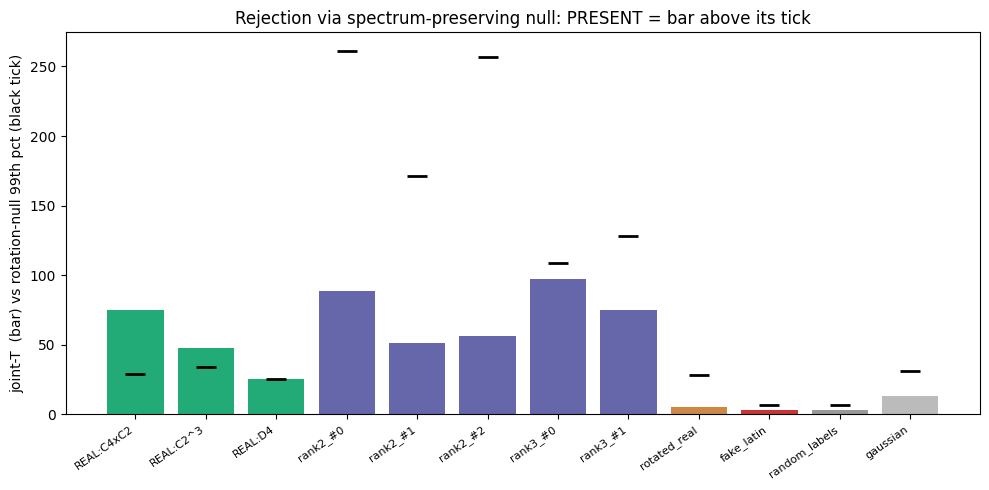

In [ ]:
"""
RP-2 PILOT — REJECTION with a SPECTRUM-PRESERVING (ROTATION) NULL
================================================================================
The confound control found that an iid-Gaussian null is rank-confounded: random
low-rank matrices (no group structure) clear the Gaussian-calibrated threshold,
because low effective rank alone inflates the joint-T statistic. But the rotation
control showed the discriminating feature:

    real group structure's score is ROTATION-SENSITIVE  (alignment with isotypic axes
        -> rotating the rows off those axes destroys it)
    a low-rank matrix's score is ROTATION-INVARIANT      (driven by spectrum/rank,
        which a rotation preserves)

So the correct null is SPECTRUM-PRESERVING: for a query matrix W, compare its evidence
to the distribution of evidence over RANDOM ROTATIONS of W itself (Q W, Q in O(n)).
This asks "does W align with group axes MORE than a random matrix of the same spectrum?"
-- isolating group structure from the rank artifact.

    present  <=>  max-evidence(W)  >  99th percentile of  max-evidence(Q W) over rotations

We test: real-group nets (should be PRESENT -- rotation-sensitive), random low-rank
rank-2/3 (should be ABSENT -- rotation-invariant), rotated real embeddings (ABSENT,
already off-axis), a non-group Latin square and random labels (ABSENT, dense), and
full-rank Gaussian (ABSENT). A clean result = real groups present, everything else absent.

Dependencies: numpy, matplotlib. Runtime: ~3 minutes.
"""

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# ---- group + algebra machinery (verified) ----
def cyclic_product(orders):
    elems = list(product(*[range(o) for o in orders])); idx = {e: i for i, e in enumerate(elems)}
    n = len(elems); cay = np.zeros((n, n), int)
    for i, a in enumerate(elems):
        for j, b in enumerate(elems):
            cay[i, j] = idx[tuple((x + y) % o for x, y, o in zip(a, b, orders))]
    return cay
def dihedral_D4():
    elems = [(a, b) for a in range(4) for b in range(2)]; idx = {e: i for i, e in enumerate(elems)}
    cay = np.zeros((8, 8), int)
    for i, (a1, b1) in enumerate(elems):
        for j, (a2, b2) in enumerate(elems):
            cay[i, j] = idx[((a1 + ((-1) ** b1) * a2) % 4, (b1 + b2) % 2)]
    return cay
def quaternion_Q8():
    E = [(1,0,0,0),(-1,0,0,0),(0,1,0,0),(0,-1,0,0),(0,0,1,0),(0,0,-1,0),(0,0,0,1),(0,0,0,-1)]
    idx = {e: i for i, e in enumerate(E)}
    def qm(p, q):
        a1,b1,c1,d1 = p; a2,b2,c2,d2 = q
        return (a1*a2-b1*b2-c1*c2-d1*d2, a1*b2+b1*a2+c1*d2-d1*c2,
                a1*c2-b1*d2+c1*a2+d1*b2, a1*d2+b1*c2-c1*b2+d1*a2)
    cay = np.zeros((8, 8), int)
    for i, p in enumerate(E):
        for j, q in enumerate(E): cay[i, j] = idx[qm(p, q)]
    return cay
GROUPS = {"C8": cyclic_product([8]), "C4xC2": cyclic_product([4, 2]),
          "C2^3": cyclic_product([2, 2, 2]), "D4": dihedral_D4(), "Q8": quaternion_Q8()}
def verify_group(cay):
    n = cay.shape[0]; ar = np.arange(n); assert cay.min() >= 0 and cay.max() < n
    ids = [e for e in range(n) if np.array_equal(cay[e], ar) and np.array_equal(cay[:, e], ar)]
    assert len(ids) == 1; e = ids[0]
    for g in range(n): assert any(cay[g, h] == e and cay[h, g] == e for h in range(n))
    for a in range(n):
        for b in range(n):
            ab = cay[a, b]
            for c in range(n): assert cay[ab, c] == cay[a, cay[b, c]]
    return e
def inverses(cay, e):
    n = cay.shape[0]; return np.array([next(h for h in range(n) if cay[g, h] == e) for g in range(n)])
def conjugacy_classes(cay, e):
    n = cay.shape[0]; inv = inverses(cay, e); seen = [False]*n; cls = []
    for g in range(n):
        if seen[g]: continue
        c = {cay[cay[a, g], inv[a]] for a in range(n)}
        for x in c: seen[x] = True
        cls.append(sorted(c))
    return cls
def left_regular(cay):
    n = cay.shape[0]; L = np.zeros((n, n, n))
    for g in range(n): L[g, cay[g], np.arange(n)] = 1.0
    return L
def isotypic_projectors(cay, e, rng, max_tries=50, tol=1e-6):
    n = cay.shape[0]; L = left_regular(cay).astype(complex)
    for g in range(n):
        for h in range(n): assert np.allclose(L[g] @ L[h], L[cay[g, h]])
    class_sums = [sum(L[g] for g in c) for c in conjugacy_classes(cay, e)]
    for _ in range(max_tries):
        c = rng.standard_normal(len(class_sums)) + 1j*rng.standard_normal(len(class_sums))
        M = sum(ck*S + np.conj(ck)*S.conj().T for ck, S in zip(c, class_sums)); M = (M + M.conj().T)/2
        w, V = np.linalg.eigh(M); spread = (w.max() - w.min()) + 1e-12
        cuts = np.where(np.diff(w) > tol*spread)[0]; groups = np.split(np.arange(n), cuts + 1)
        projs = [V[:, g] @ V[:, g].conj().T for g in groups]
        ok = np.allclose(sum(projs), np.eye(n), atol=1e-8)
        if ok:
            for P in projs:
                if not (np.allclose(P @ P, P, atol=1e-7) and np.allclose(P, P.conj().T, atol=1e-8)): ok = False; break
        ranks = [int(round(np.trace(P).real)) for P in projs]; dims = [int(round(np.sqrt(r))) for r in ranks]
        if ok and sum(ranks) == n and all(d*d == r for d, r in zip(dims, ranks)): return projs, ranks, dims
    raise RuntimeError("projector gates failed")
def fractions(W, projs):
    tot = np.linalg.norm(W) ** 2; return np.array([np.linalg.norm(P @ W) ** 2 / tot for P in projs])

# ---- training ----
def relu(x): return np.maximum(x, 0)
def softmax(z): z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)
def train_net(cay, d=16, H=128, frac=0.85, steps=30000, lr=2e-3, wd=1.0, seed=0):
    n = cay.shape[0]; rng = np.random.default_rng(seed)
    pairs = np.array([(a, b) for a in range(n) for b in range(n)]); y = np.array([cay[a, b] for a, b in pairs])
    g1, g2 = pairs[:, 0], pairs[:, 1]
    perm = rng.permutation(len(pairs)); ntr = int(frac*len(pairs)); tr, te = perm[:ntr], perm[ntr:]
    WE = rng.standard_normal((n, d))/np.sqrt(d); W1 = rng.standard_normal((H, 2*d))/np.sqrt(2*d); W2 = rng.standard_normal((n, H))/np.sqrt(H)
    stt = {id(WE): [np.zeros_like(WE), np.zeros_like(WE)], id(W1): [np.zeros_like(W1), np.zeros_like(W1)], id(W2): [np.zeros_like(W2), np.zeros_like(W2)]}
    def acc(idx): return float(((relu(np.concatenate([WE[g1[idx]], WE[g2[idx]]], 1) @ W1.T) @ W2.T).argmax(1) == y[idx]).mean())
    for t in range(1, steps + 1):
        X = np.concatenate([WE[g1[tr]], WE[g2[tr]]], 1); Hpre = X @ W1.T; Ha = relu(Hpre); Lg = Ha @ W2.T
        P = softmax(Lg); B = len(tr); dL = P.copy(); dL[np.arange(B), y[tr]] -= 1; dL /= B
        dW2 = dL.T @ Ha; dHa = dL @ W2; dHpre = dHa * (Hpre > 0); dW1 = dHpre.T @ X; dX = dHpre @ W1
        dWE = np.zeros_like(WE); np.add.at(dWE, g1[tr], dX[:, :d]); np.add.at(dWE, g2[tr], dX[:, d:])
        for Wp, dWp in [(W2, dW2), (W1, dW1), (WE, dWE)]:
            m, v = stt[id(Wp)]; m *= 0.9; m += 0.1*dWp; v *= 0.999; v += 0.001*dWp**2
            Wp -= lr*(m/(1 - 0.9**t)/(np.sqrt(v/(1 - 0.999**t)) + 1e-8) + wd*Wp)
        if t % 5000 == 0 and acc(te) == 1.0: break
    return WE, acc(te)

# ---- instrument: max-over-groups joint-T, with the SAME per-group Gaussian standardization ----
def mc_stats(projs, triv, n, d, n_null, rng):
    F = np.array([fractions(rng.standard_normal((n, d)), projs) for _ in range(n_null)])
    nmean = F.mean(0); nstd = F.std(0) + 1e-12; mask = np.ones(len(projs), bool); mask[triv] = False
    return nmean, nstd, mask
def trivial_index(projs, n):
    ones = np.ones(n)/np.sqrt(n); return int(np.argmax([np.linalg.norm(P @ ones) for P in projs]))
def joint_T_over_groups(W, G):
    best = -np.inf
    for nm in G:
        nmean, nstd, mask = G[nm]["st"]; z = (fractions(W, G[nm]["projs"]) - nmean)/nstd
        best = max(best, (z[mask] ** 2).sum())
    return best

# ---- spectrum-preserving (rotation) null test ----
def random_rotation(n, rng):
    Q, R = np.linalg.qr(rng.standard_normal((n, n))); return Q * np.sign(np.diag(R))
def rotation_null_test(W, G, n_rot, rng):
    """PRESENT iff W's joint-T exceeds the 99th pct of joint-T over random rotations of W."""
    n = W.shape[0]; obs = joint_T_over_groups(W, G)
    null = np.array([joint_T_over_groups(random_rotation(n, rng) @ W, G) for _ in range(n_rot)])
    p = float((null >= obs).mean())               # rotation-null p-value
    thr = np.percentile(null, 99)
    return obs, thr, p, obs > thr

def random_lowrank(n, d, r, rng):
    return rng.standard_normal((n, r)) @ rng.standard_normal((r, d))
def random_latin_square(n, rng):
    L = -np.ones((n, n), int)
    def solve(pos):
        if pos == n*n: return True
        i, j = divmod(pos, n); used = set(L[i, :j].tolist()) | set(L[:i, j].tolist())
        ch = [c for c in range(n) if c not in used]; rng.shuffle(ch)
        for c in ch:
            L[i, j] = c
            if solve(pos + 1): return True
            L[i, j] = -1
        return False
    assert solve(0); return L
def is_assoc(L):
    n = L.shape[0]
    return all(L[L[a, b], c] == L[a, L[b, c]] for a in range(n) for b in range(n) for c in range(n))

def main(n_null=2000, n_rot=500, seed0=0):
    rng = np.random.default_rng(seed0); n = 8; d = 16
    G = {}
    for nm, cay in GROUPS.items():
        e = verify_group(cay); projs, ranks, dims = isotypic_projectors(cay, e, rng)
        G[nm] = dict(projs=projs, st=mc_stats(projs, trivial_index(projs, n), n, d, n_null, rng))
    print("=" * 80); print("REJECTION via spectrum-preserving (rotation) null"); print("=" * 80)
    print("  PRESENT iff joint-T(W) exceeds 99th pct of joint-T over rotations of W")
    print("  (i.e. W aligns with group axes more than a random matrix of the same spectrum)\n")

    # build inputs
    inputs = []
    for nm in ["C4xC2", "C2^3", "D4"]:
        best = None
        for s in range(3):
            WE, he = train_net(GROUPS[nm], seed=s)
            if best is None or he > best[1]: best = (WE, he)
        inputs.append((f"REAL:{nm}", "real", best[0]))
    # non-group, low-rank (the confound that broke the Gaussian null)
    for k in range(3): inputs.append((f"rank2_#{k}", "lowrank", random_lowrank(n, d, 2, rng)))
    for k in range(2): inputs.append((f"rank3_#{k}", "lowrank", random_lowrank(n, d, 3, rng)))
    # rotated real (off-axis structured)
    inputs.append(("rotated_real", "rotated", random_rotation(n, rng) @ inputs[0][2]))
    # non-group Latin square (dense)
    for _ in range(20):
        L = random_latin_square(n, rng)
        if not is_assoc(L): break
    WEf, _ = train_net(L, seed=0); inputs.append(("fake_latin", "fake", WEf))
    # random labels (dense)
    WEr, _ = train_net(rng.integers(0, n, size=(n, n)), seed=0); inputs.append(("random_labels", "random", WEr))
    # gaussian
    inputs.append(("gaussian", "gauss", rng.standard_normal((n, d))))

    print(f"  {'input':16s} {'type':9s} {'jointT':>8s} {'rot-thr':>8s} {'rot-p':>7s}  verdict")
    rows = []
    for name, kind, W in inputs:
        obs, thr, p, present = rotation_null_test(W, G, n_rot, rng)
        rows.append((name, kind, obs, thr, p, present))
        print(f"  {name:16s} {kind:9s} {obs:8.1f} {thr:8.1f} {p:7.3f}  {'PRESENT' if present else 'ABSENT'}")

    real_present = all(r[5] for r in rows if r[1] == "real")
    nongroup_absent = all(not r[5] for r in rows if r[1] != "real")
    print("\n" + "=" * 80); print("READOUT"); print("=" * 80)
    if real_present and nongroup_absent:
        print("  CLEAN: real groups exceed their rotation-null (genuine isotypic alignment);")
        print("  low-rank, rotated, dense-non-group, and Gaussian all read ABSENT. The rotation")
        print("  null fixes the rank confound -- the absence claim is sound under a fair null.")
    else:
        bad_real = [r[0] for r in rows if r[1] == "real" and not r[5]]
        bad_other = [r[0] for r in rows if r[1] != "real" and r[5]]
        if bad_real: print(f"  real groups that FAILED to clear their rotation-null: {bad_real}")
        if bad_other: print(f"  non-group inputs that still read PRESENT: {bad_other}")
        print("  The rotation null helps but is not a clean fix here; report honestly.")

    fig, ax = plt.subplots(figsize=(10, 5))
    cols = {"real": "#2a7", "lowrank": "#66a", "rotated": "#c84", "fake": "#c33", "random": "#999", "gauss": "#bbb"}
    for i, (name, kind, obs, thr, p, present) in enumerate(rows):
        ax.bar(i, obs, color=cols[kind]); ax.plot(i, thr, "k_", ms=14, mew=2)
    ax.set_xticks(range(len(rows))); ax.set_xticklabels([r[0] for r in rows], rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("joint-T  (bar) vs rotation-null 99th pct (black tick)")
    ax.set_title("Rejection via spectrum-preserving null: PRESENT = bar above its tick")
    plt.tight_layout(); plt.savefig("rejection_rotation_null.png", dpi=120)
    print("\n[saved rejection_rotation_null.png]"); plt.show()

if __name__ == "__main__":
    main()

GATES + SETUP
  group axioms + projectors OK for all 5 candidate groups

  tau_gauss (99th pct, full-rank Gaussian null) = 4.83
  real-group baselines (max-evidence):
    C4xC2  held-out=1.00  max-ev=24.8
    C2^3   held-out=1.00  max-ev=13.0
    D4     held-out=1.00  max-ev=5.0

CONTROLS: concentration held, group structure removed
  ROTATED real embeddings (n=24):  mean max-ev=1.4  max=3.6  (vs real ~14.2)
  RANDOM rank-2 (n=3000):  mean=14.8  95th=36.2  99th=52.9  max=94.2
  RANDOM rank-3 (n=3000):  mean=10.5  95th=26.6  99th=45.2  max=73.0

VERDICTS
  threshold (Gaussian null)      tau_gauss  = 4.83
  threshold (concentrated null)  tau_strict = 45.53

  REAL:C4xC2                   mean max-ev=  24.8   PRESENT under tau_gauss:  100%   under tau_strict:    0%
  REAL:C2^3                    mean max-ev=  13.0   PRESENT under tau_gauss:  100%   under tau_strict:    0%
  REAL:D4                      mean max-ev=   5.0   PRESENT under tau_gauss:  100%   under tau_strict:    0%
  ROTATED

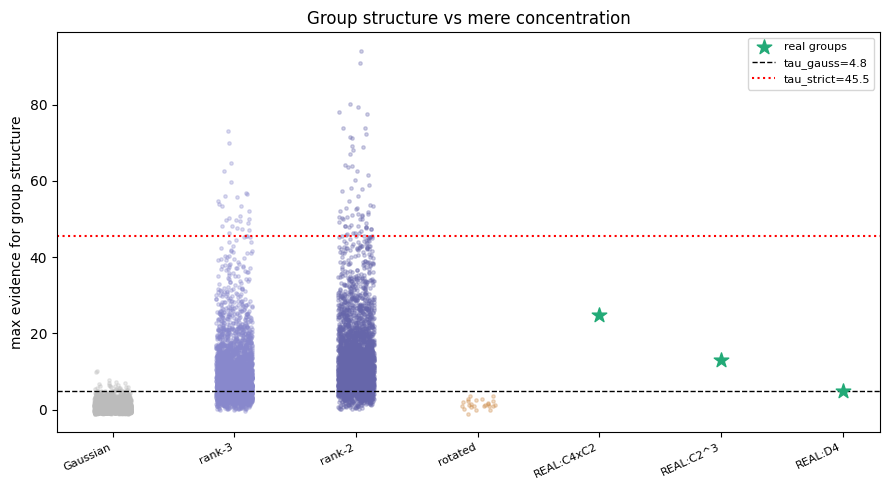

In [ ]:
"""
RP-2 PILOT — CONFOUND CONTROL: group structure vs mere concentration
================================================================================
In the rejection demo, "absent" coincided with "the net didn't grok / memorized a
dense embedding". A skeptic can therefore argue the instrument detects CONCENTRATED /
LOW-RANK embeddings, not GROUP structure specifically. This control settles that.

It holds concentration fixed and destroys group alignment, then asks if the instrument
still fires. Three non-group inputs, all tested against the calibrated threshold:

  - ROTATED real-group embedding: a real net's embedding with rows hit by a random
    orthogonal rotation Q. Same singular values, same concentration, same matrix rank --
    but the structure is rotated OFF the group's isotypic axes. A relabeling cannot undo
    a generic rotation. If the instrument is group-specific, this reads ABSENT.
  - RANDOM LOW-RANK matrices (rank 2, 3): concentrated in the SVD sense, no group
    structure. If "concentration" is all the instrument keys on, these read PRESENT.
  - FULL-RANK GAUSSIAN: the original structureless null (sanity).

CRITICAL EXTRA CHECK: the rejection-demo threshold tau was calibrated on full-rank
Gaussian. Low-rank matrices fluctuate more, so their joint-T can be larger. We therefore
ALSO re-calibrate a STRICTER threshold against concentrated non-group nulls (low-rank +
rotated) and report whether the real groups still clear it. If they do, the absence claim
is robust under a fair null; if they don't, the instrument is partly a concentration
detector and the claim needs that caveat. Either way it's reported, not hidden.

Dependencies: numpy, matplotlib. Runtime: ~2-3 minutes.
"""

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# ---- group + algebra machinery (verified) ----
def cyclic_product(orders):
    elems = list(product(*[range(o) for o in orders])); idx = {e: i for i, e in enumerate(elems)}
    n = len(elems); cay = np.zeros((n, n), int)
    for i, a in enumerate(elems):
        for j, b in enumerate(elems):
            cay[i, j] = idx[tuple((x + y) % o for x, y, o in zip(a, b, orders))]
    return cay
def dihedral_D4():
    elems = [(a, b) for a in range(4) for b in range(2)]; idx = {e: i for i, e in enumerate(elems)}
    cay = np.zeros((8, 8), int)
    for i, (a1, b1) in enumerate(elems):
        for j, (a2, b2) in enumerate(elems):
            cay[i, j] = idx[((a1 + ((-1) ** b1) * a2) % 4, (b1 + b2) % 2)]
    return cay
def quaternion_Q8():
    E = [(1,0,0,0),(-1,0,0,0),(0,1,0,0),(0,-1,0,0),(0,0,1,0),(0,0,-1,0),(0,0,0,1),(0,0,0,-1)]
    idx = {e: i for i, e in enumerate(E)}
    def qm(p, q):
        a1,b1,c1,d1 = p; a2,b2,c2,d2 = q
        return (a1*a2-b1*b2-c1*c2-d1*d2, a1*b2+b1*a2+c1*d2-d1*c2,
                a1*c2-b1*d2+c1*a2+d1*b2, a1*d2+b1*c2-c1*b2+d1*a2)
    cay = np.zeros((8, 8), int)
    for i, p in enumerate(E):
        for j, q in enumerate(E): cay[i, j] = idx[qm(p, q)]
    return cay
GROUPS = {"C8": cyclic_product([8]), "C4xC2": cyclic_product([4, 2]),
          "C2^3": cyclic_product([2, 2, 2]), "D4": dihedral_D4(), "Q8": quaternion_Q8()}
def verify_group(cay):
    n = cay.shape[0]; ar = np.arange(n); assert cay.min() >= 0 and cay.max() < n
    ids = [e for e in range(n) if np.array_equal(cay[e], ar) and np.array_equal(cay[:, e], ar)]
    assert len(ids) == 1; e = ids[0]
    for g in range(n): assert any(cay[g, h] == e and cay[h, g] == e for h in range(n))
    for a in range(n):
        for b in range(n):
            ab = cay[a, b]
            for c in range(n): assert cay[ab, c] == cay[a, cay[b, c]]
    return e
def inverses(cay, e):
    n = cay.shape[0]; return np.array([next(h for h in range(n) if cay[g, h] == e) for g in range(n)])
def conjugacy_classes(cay, e):
    n = cay.shape[0]; inv = inverses(cay, e); seen = [False]*n; cls = []
    for g in range(n):
        if seen[g]: continue
        c = {cay[cay[a, g], inv[a]] for a in range(n)}
        for x in c: seen[x] = True
        cls.append(sorted(c))
    return cls
def left_regular(cay):
    n = cay.shape[0]; L = np.zeros((n, n, n))
    for g in range(n): L[g, cay[g], np.arange(n)] = 1.0
    return L
def isotypic_projectors(cay, e, rng, max_tries=50, tol=1e-6):
    n = cay.shape[0]; L = left_regular(cay).astype(complex)
    for g in range(n):
        for h in range(n): assert np.allclose(L[g] @ L[h], L[cay[g, h]])
    class_sums = [sum(L[g] for g in c) for c in conjugacy_classes(cay, e)]
    for _ in range(max_tries):
        c = rng.standard_normal(len(class_sums)) + 1j*rng.standard_normal(len(class_sums))
        M = sum(ck*S + np.conj(ck)*S.conj().T for ck, S in zip(c, class_sums)); M = (M + M.conj().T)/2
        w, V = np.linalg.eigh(M); spread = (w.max() - w.min()) + 1e-12
        cuts = np.where(np.diff(w) > tol*spread)[0]; groups = np.split(np.arange(n), cuts + 1)
        projs = [V[:, g] @ V[:, g].conj().T for g in groups]
        ok = np.allclose(sum(projs), np.eye(n), atol=1e-8)
        if ok:
            for P in projs:
                if not (np.allclose(P @ P, P, atol=1e-7) and np.allclose(P, P.conj().T, atol=1e-8)): ok = False; break
        ranks = [int(round(np.trace(P).real)) for P in projs]; dims = [int(round(np.sqrt(r))) for r in ranks]
        if ok and sum(ranks) == n and all(d*d == r for d, r in zip(dims, ranks)): return projs, ranks, dims
    raise RuntimeError("projector gates failed")
def fractions(W, projs):
    tot = np.linalg.norm(W) ** 2; return np.array([np.linalg.norm(P @ W) ** 2 / tot for P in projs])

# ---- training (gradient-checked design from earlier pilots) ----
def relu(x): return np.maximum(x, 0)
def softmax(z): z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)
def train_net(cay, d=16, H=128, frac=0.85, steps=30000, lr=2e-3, wd=1.0, seed=0):
    n = cay.shape[0]; rng = np.random.default_rng(seed)
    pairs = np.array([(a, b) for a in range(n) for b in range(n)]); y = np.array([cay[a, b] for a, b in pairs])
    g1, g2 = pairs[:, 0], pairs[:, 1]
    perm = rng.permutation(len(pairs)); ntr = int(frac*len(pairs)); tr, te = perm[:ntr], perm[ntr:]
    WE = rng.standard_normal((n, d))/np.sqrt(d); W1 = rng.standard_normal((H, 2*d))/np.sqrt(2*d); W2 = rng.standard_normal((n, H))/np.sqrt(H)
    st = {id(WE): [np.zeros_like(WE), np.zeros_like(WE)], id(W1): [np.zeros_like(W1), np.zeros_like(W1)], id(W2): [np.zeros_like(W2), np.zeros_like(W2)]}
    def acc(idx): return float(((relu(np.concatenate([WE[g1[idx]], WE[g2[idx]]], 1) @ W1.T) @ W2.T).argmax(1) == y[idx]).mean())
    for t in range(1, steps + 1):
        X = np.concatenate([WE[g1[tr]], WE[g2[tr]]], 1); Hpre = X @ W1.T; Ha = relu(Hpre); Lg = Ha @ W2.T
        P = softmax(Lg); B = len(tr); dL = P.copy(); dL[np.arange(B), y[tr]] -= 1; dL /= B
        dW2 = dL.T @ Ha; dHa = dL @ W2; dHpre = dHa * (Hpre > 0); dW1 = dHpre.T @ X; dX = dHpre @ W1
        dWE = np.zeros_like(WE); np.add.at(dWE, g1[tr], dX[:, :d]); np.add.at(dWE, g2[tr], dX[:, d:])
        for Wp, dWp in [(W2, dW2), (W1, dW1), (WE, dWE)]:
            m, v = st[id(Wp)]; m *= 0.9; m += 0.1*dWp; v *= 0.999; v += 0.001*dWp**2
            Wp -= lr*(m/(1 - 0.9**t)/(np.sqrt(v/(1 - 0.999**t)) + 1e-8) + wd*Wp)
        if t % 5000 == 0 and acc(te) == 1.0: break
    return WE, acc(te)

# ---- instrument (canonical max-over-groups joint-T z; same config as rejection demo) ----
def mc_stats(projs, triv, n, d, n_null, rng):
    F = np.array([fractions(rng.standard_normal((n, d)), projs) for _ in range(n_null)])
    nmean = F.mean(0); nstd = F.std(0) + 1e-12
    mask = np.ones(len(projs), bool); mask[triv] = False
    Z = (F - nmean)/nstd; T = (Z[:, mask] ** 2).sum(1)
    return nmean, nstd, mask, T.mean(), T.std() + 1e-12
def trivial_index(projs, n):
    ones = np.ones(n)/np.sqrt(n); return int(np.argmax([np.linalg.norm(P @ ones) for P in projs]))
def zT(W, projs, st):
    nmean, nstd, mask, Tm, Ts = st; z = (fractions(W, projs) - nmean)/nstd
    return ((z[mask] ** 2).sum() - Tm)/Ts
def max_evidence(W, G):
    return max(zT(W, G[nm]["projs"], G[nm]["st"]) for nm in G)

# ---- control-matrix generators ----
def random_rotation(n, rng):
    Q, R = np.linalg.qr(rng.standard_normal((n, n))); return Q * np.sign(np.diag(R))   # Haar-ish O(n)
def random_lowrank(n, d, r, rng):
    return rng.standard_normal((n, r)) @ rng.standard_normal((r, d))

# ---- experiment ----
def main(n_null=2000, n_calib=3000, seed0=0):
    rng = np.random.default_rng(seed0); n = 8; d = 16
    print("=" * 80); print("GATES + SETUP"); print("=" * 80)
    G = {}
    for nm, cay in GROUPS.items():
        e = verify_group(cay); projs, ranks, dims = isotypic_projectors(cay, e, rng)
        G[nm] = dict(projs=projs, st=mc_stats(projs, trivial_index(projs, n), n, d, n_null, rng))
    print("  group axioms + projectors OK for all 5 candidate groups")

    # tau_gauss : original (rejection-demo) threshold, calibrated on full-rank Gaussian
    gauss_me = np.sort([max_evidence(rng.standard_normal((n, d)), G) for _ in range(n_calib)])
    tau_gauss = gauss_me[int(0.99 * n_calib)]

    # train real-group embeddings (the PRESENT baseline)
    real = {}
    for nm in ["C4xC2", "C2^3", "D4"]:
        best = None
        for s in range(3):
            WE, he = train_net(GROUPS[nm], seed=s); me = max_evidence(WE, G)
            if best is None or (he, me) > (best[1], best[2]): best = (WE, he, me)
        real[nm] = best
    print(f"\n  tau_gauss (99th pct, full-rank Gaussian null) = {tau_gauss:.2f}")
    print("  real-group baselines (max-evidence):")
    for nm in real: print(f"    {nm:6s} held-out={real[nm][1]:.2f}  max-ev={real[nm][2]:.1f}")

    # CONTROLS
    print("\n" + "=" * 80); print("CONTROLS: concentration held, group structure removed"); print("=" * 80)
    rot_me = []
    for nm in real:
        for _ in range(8):
            Q = random_rotation(n, rng); rot_me.append(max_evidence(Q @ real[nm][0], G))
    rot_me = np.array(rot_me)
    lr2 = np.array([max_evidence(random_lowrank(n, d, 2, rng), G) for _ in range(n_calib)])
    lr3 = np.array([max_evidence(random_lowrank(n, d, 3, rng), G) for _ in range(n_calib)])

    print(f"  ROTATED real embeddings (n={len(rot_me)}):  mean max-ev={rot_me.mean():.1f}  "
          f"max={rot_me.max():.1f}  (vs real ~{np.mean([real[k][2] for k in real]):.1f})")
    print(f"  RANDOM rank-2 (n={n_calib}):  mean={lr2.mean():.1f}  95th={np.percentile(lr2,95):.1f}  99th={np.percentile(lr2,99):.1f}  max={lr2.max():.1f}")
    print(f"  RANDOM rank-3 (n={n_calib}):  mean={lr3.mean():.1f}  95th={np.percentile(lr3,95):.1f}  99th={np.percentile(lr3,99):.1f}  max={lr3.max():.1f}")

    # STRICTER threshold: calibrated against concentrated non-group nulls (low-rank + rotated)
    concentrated_null = np.concatenate([lr2, lr3, np.repeat(rot_me, max(1, n_calib // max(1, len(rot_me))))])
    tau_strict = np.percentile(concentrated_null, 99)

    print("\n" + "=" * 80); print("VERDICTS"); print("=" * 80)
    print(f"  threshold (Gaussian null)      tau_gauss  = {tau_gauss:.2f}")
    print(f"  threshold (concentrated null)  tau_strict = {tau_strict:.2f}\n")
    def verdicts(label, vals, taug, taus):
        vals = np.atleast_1d(vals)
        pg = float((vals > taug).mean()); ps = float((vals > taus).mean())
        print(f"  {label:28s} mean max-ev={vals.mean():6.1f}   PRESENT under tau_gauss: {pg*100:4.0f}%   under tau_strict: {ps*100:4.0f}%")
    for nm in real: verdicts(f"REAL:{nm}", real[nm][2], tau_gauss, tau_strict)
    verdicts("ROTATED real (control)", rot_me, tau_gauss, tau_strict)
    verdicts("RANDOM rank-2 (control)", lr2, tau_gauss, tau_strict)
    verdicts("RANDOM rank-3 (control)", lr3, tau_gauss, tau_strict)

    real_clears_strict = all(real[nm][2] > tau_strict for nm in real)
    controls_absent_gauss = (rot_me.max() <= tau_gauss) and (np.percentile(lr2, 99) <= tau_gauss) and (np.percentile(lr3, 99) <= tau_gauss)
    print("\n" + "=" * 80); print("READOUT"); print("=" * 80)
    if controls_absent_gauss:
        print("  Concentrated non-group inputs read ABSENT under the original threshold => the")
        print("  instrument keys on GROUP structure, not mere concentration. Headline robust as-is.")
    elif real_clears_strict:
        print("  Concentrated non-group inputs CAN exceed the Gaussian threshold (so the null must")
        print("  be calibrated against concentrated matrices, not just Gaussian) -- BUT the real")
        print("  groups still clear the stricter threshold. Headline robust under a fair null;")
        print("  state the rank-aware calibration explicitly.")
    else:
        weak = [nm for nm in real if real[nm][2] <= tau_strict]
        print("  Concentrated non-group inputs reach the real-group evidence range, and these real")
        print(f"  groups FAIL the stricter threshold: {weak}. The instrument is partly a concentration")
        print("  detector for these cases; the absence claim needs that caveat (esp. high-d^2/|G| irreps).")

    # figure
    fig, ax = plt.subplots(figsize=(9, 5))
    data = [("Gaussian", gauss_me, "#bbb"), ("rank-3", lr3, "#88c"), ("rank-2", lr2, "#66a"),
            ("rotated", rot_me, "#c84")]
    for i, (lab, vals, col) in enumerate(data):
        ax.scatter(np.full(len(vals), i) + rng.uniform(-0.15, 0.15, len(vals)), vals, s=6, alpha=0.3, color=col)
    for j, nm in enumerate(real):
        ax.scatter(len(data) + j, real[nm][2], s=120, marker="*", color="#2a7", zorder=5,
                   label="real groups" if j == 0 else "")
    ax.axhline(tau_gauss, ls="--", c="k", lw=1, label=f"tau_gauss={tau_gauss:.1f}")
    ax.axhline(tau_strict, ls=":", c="r", lw=1.5, label=f"tau_strict={tau_strict:.1f}")
    ax.set_xticks(range(len(data) + len(real)))
    ax.set_xticklabels([d[0] for d in data] + [f"REAL:{nm}" for nm in real], rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("max evidence for group structure"); ax.set_title("Group structure vs mere concentration")
    ax.legend(fontsize=8); plt.tight_layout(); plt.savefig("confound_control.png", dpi=120)
    print("\n[saved confound_control.png]"); plt.show()

if __name__ == "__main__":
    main()

In [ ]:
"""
RP-2  —  CLOSED-FORM DETECTION FLOOR FROM THE BETA NULL, AND ITS VALIDATION
==========================================================================
Goal (truthful scope): turn the *measured* detection floor into a *derived*
one, and check the derivation in the sandbox, self-contained.

DERIVATION
----------
W is n x d with iid N(0,1) entries (n = |G|). P is the orthogonal projector
of rank r onto a predicted subspace V. Define the energy fraction

    f := ||P W||_F^2 / ||W||_F^2 .

Column-wise, ||P W||_F^2 = sum_j w_j^T P w_j with w_j ~ N(0, I_n), and
w_j^T P w_j ~ chi^2_r (squared norm of a standard Gaussian projected onto an
r-dim subspace). Summing d independent columns:
    ||P W||_F^2      ~ chi^2_{d r}
    ||(I-P) W||_F^2  ~ chi^2_{d (n-r)}
and the two are INDEPENDENT (orthogonal subspaces, Gaussian). A ratio
X/(X+Y) of independent chi-squares is Beta, hence EXACTLY

    f  ~  Beta( a, b ),   a = d r / 2,   b = d (n - r) / 2 .

    mean   mu = a/(a+b) = r/n            (= d_rho^2/|G| in the isotypic case)
    var       = mu(1-mu) / (d n / 2 + 1)

FLOOR. Plant energy fraction f in V, isotropic noise elsewhere:
    E[f_obs] = f + (1-f) mu = mu + f(1-mu).
With threshold tau = (1-aFP)-quantile of the null Beta, the planted fraction
at which the expected statistic crosses tau (the mean-crossing / ~50%-power
floor) is

    f*  =  (tau - mu) / (1 - mu)         (exact, Beta quantile)
        ~  z * sigma / (1 - mu)          (Gaussian approx, z = Phi^{-1}(1-aFP))

SCALING LAW (the 'sensitivity improves with |G|' claim, now derived):
    sigma = sqrt( mu(1-mu)/(d n/2 + 1) ),  mu = d_rho^2/|G|
    => fixed d_rho, large |G|:  f* ~ (z*sqrt(2)/sqrt(d)) * d_rho/|G|  ->  falls as 1/|G|.

NOT claimed here (kept honest): exact agreement with the user's previously
measured grid (needs her calibration constants: width d, z, and one-sided-vs-
joint-T); a consequential rank-confound case; the spectrum-preserving null
re-run on S4-S6. The checks below validate the derivation against simulation
with the REAL projector ranks; matching to her CSVs is a separate step.
"""
import numpy as np
from itertools import permutations
from scipy import stats

# ---- cheap f via orthonormal basis Q (n x r):  ||P W||_F^2 = ||Q^T W||_F^2 ----
def f_samples(Q, n, d, trials, rng):
    out = np.empty(trials)
    for t in range(trials):
        W = rng.standard_normal((n, d))
        out[t] = np.sum((Q.T @ W) ** 2) / np.sum(W ** 2)
    return out

def beta_params(n, r, d):
    a = d * r / 2.0; b = d * (n - r) / 2.0
    mu = a / (a + b); var = a * b / ((a + b) ** 2 * (a + b + 1))
    return a, b, mu, np.sqrt(var)

Z3_AFP = 1 - stats.norm.cdf(3.0)        # false-positive rate matching one-sided z=3

# ===================== (1) NULL IS EXACTLY BETA (generic, NON-group, subspaces) =====================
print("=" * 80)
print("(1) NULL  f=||PW||^2/||W||^2  vs  Beta(dr/2, d(n-r)/2)   [generic random subspaces]")
print("=" * 80)
for (n, r, d) in [(24, 9, 100), (120, 25, 100), (720, 25, 100), (200, 16, 64)]:
    rng = np.random.default_rng(10 * n + r)
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    fs = f_samples(Q[:, :r], n, d, 8000, rng)
    a, b, mu, sd = beta_params(n, r, d)
    ks = stats.kstest(fs, 'beta', args=(a, b))
    print(f"  n={n:4d} r={r:3d} d={d:4d} | mean emp={fs.mean():.5f} pred={mu:.5f}"
          f" | sd emp={fs.std():.5f} pred={sd:.5f} | KS={ks.statistic:.4f} p={ks.pvalue:.3f}")

# ===================== (2) REP-THEORY CASE IS AN INSTANCE (S4) =====================
print("\n" + "=" * 80)
print("(2) S4 regular rep: isotypic projector ranks should be d_rho^2, and f for")
print("    the 3-dim block should follow the SAME Beta")
print("=" * 80)

def symmetric_group(k):
    E = list(permutations(range(k))); idx = {e: i for i, e in enumerate(E)}; n = len(E)
    cay = np.zeros((n, n), int)
    for i, a in enumerate(E):
        for j, b in enumerate(E):
            cay[i, j] = idx[tuple(a[b[t]] for t in range(k))]
    return E, idx, cay

def left_regular(cay):
    n = cay.shape[0]; L = np.zeros((n, n, n))
    for g in range(n):
        for h in range(n):
            L[g, cay[g, h], h] = 1.0
    return L

def ident(cay):
    n = cay.shape[0]; ar = np.arange(n)
    return next(e for e in range(n) if np.array_equal(cay[e], ar) and np.array_equal(cay[:, e], ar))

def invs(cay, e):
    n = cay.shape[0]
    return np.array([next(h for h in range(n) if cay[g, h] == e) for g in range(n)])

def classes(cay, e):
    n = cay.shape[0]; inv = invs(cay, e); seen = [False] * n; cls = []
    for g in range(n):
        if seen[g]: continue
        c = {cay[cay[a, g], inv[a]] for a in range(n)}
        for x in c: seen[x] = True
        cls.append(sorted(c))
    return cls

def isotypic(cay, rng, tol=1e-7):
    n = cay.shape[0]; e = ident(cay); L = left_regular(cay).astype(complex)
    S = [sum(L[g] for g in c) for c in classes(cay, e)]
    for _ in range(80):
        ck = rng.standard_normal(len(S)) + 1j * rng.standard_normal(len(S))
        M = sum(c * s + np.conj(c) * s.conj().T for c, s in zip(ck, S)); M = (M + M.conj().T) / 2
        w, V = np.linalg.eigh(M); spread = (w.max() - w.min()) + 1e-12
        cuts = np.where(np.diff(w) > tol * spread)[0]; blocks = np.split(np.arange(n), cuts + 1)
        projs = [V[:, bl] @ V[:, bl].conj().T for bl in blocks]
        if np.allclose(sum(projs), np.eye(n), atol=1e-7):
            ranks = [int(round(np.trace(P).real)) for P in projs]
            if sum(ranks) == n:
                return projs, ranks
    raise RuntimeError("projector build failed")

E, idx, cay = symmetric_group(4)
projs, ranks = isotypic(cay, np.random.default_rng(3))
print(f"  S4 isotypic ranks (sorted) = {sorted(ranks)}   -> d_rho = {sorted(int(round(np.sqrt(r))) for r in ranks)}")
print(f"  rep-theory prediction       = [1, 1, 4, 9, 9] -> d_rho = [1, 1, 2, 3, 3]")
P9 = next(P for P, r in zip(projs, ranks) if r == 9)
w, V = np.linalg.eigh((P9 + P9.conj().T) / 2)
Q9, _ = np.linalg.qr(np.real(V[:, w > 0.5]))
fs = f_samples(Q9, 24, 100, 8000, np.random.default_rng(99))
a, b, mu, sd = beta_params(24, 9, 100)
ks = stats.kstest(fs, 'beta', args=(a, b))
print(f"  3-dim block: mean emp={fs.mean():.5f} pred={mu:.5f} | sd emp={fs.std():.5f}"
      f" pred={sd:.5f} | KS={ks.statistic:.4f} p={ks.pvalue:.3f}")

# ===================== (3) PLANTED-SIGNAL FLOOR vs CLOSED FORM =====================
print("\n" + "=" * 80)
print("(3) PLANTED FLOOR: empirical 50%-power fraction vs closed form")
print("    n=120 (S5), r=25 (5-dim irrep), d=100, threshold at one-sided z=3")
print("=" * 80)
n, r, d = 120, 25, 100
a, b, mu, sd = beta_params(n, r, d)
tau = stats.beta.ppf(1 - Z3_AFP, a, b)
f_exact = (tau - mu) / (1 - mu)
f_gauss = 3.0 * sd / (1 - mu)
print(f"  mu=d^2/|G|={mu:.5f}  sigma={sd:.6f}  tau(z=3)={tau:.5f}")
print(f"  closed-form floor (tau-mu)/(1-mu) = {f_exact:.5f}")
print(f"  Gaussian approx   z*sigma/(1-mu)  = {f_gauss:.5f}")
rng = np.random.default_rng(7)
Q, _ = np.linalg.qr(rng.standard_normal((n, n))); Qr = Q[:, :r]
fracs = np.linspace(0, 2 * f_exact, 17); power = []
for f in fracs:
    hits, T = 0, 2500
    for _ in range(T):
        Sg = Qr @ rng.standard_normal((r, d)); Sg /= np.linalg.norm(Sg)
        Ng = rng.standard_normal((n, d)); Ng /= np.linalg.norm(Ng)
        W = np.sqrt(f) * Sg + np.sqrt(1 - f) * Ng
        hits += (np.sum((Qr.T @ W) ** 2) / np.sum(W ** 2)) > tau
    power.append(hits / T)
f50 = np.interp(0.5, np.array(power), fracs)
print(f"  empirical planted fraction at 50% power = {f50:.5f}")
print(f"  ratio empirical / closed-form           = {f50 / f_exact:.3f}")

# ===================== (4) SCALING LAW =====================
print("\n" + "=" * 80)
print("(4) SCALING LAW  f* vs |G|   (derived; checked on the real 5-dim irrep of S5 & S6)")
print("=" * 80)
def floor_cf(n, r, d):
    a, b, mu, sd = beta_params(n, r, d)
    return (stats.beta.ppf(1 - Z3_AFP, a, b) - mu) / (1 - mu), mu
for label, n, r, d in [("S5 5-dim", 120, 25, 100), ("S6 5-dim", 720, 25, 100)]:
    fcf, mu = floor_cf(n, r, d)
    print(f"  {label}: |G|={n:4d}  mu=d^2/|G|={mu:.5f}  f*={fcf:.5f}")
print(f"  ratio f*(S5)/f*(S6) = {floor_cf(120,25,100)[0]/floor_cf(720,25,100)[0]:.2f}"
      f"   (|G| ratio = {720/120:.1f}; leading order predicts ~1/|G|)")
print("  leading order:  f* ~ (z*sqrt(2)/sqrt(d)) * d_rho/|G|  ->  decreases as 1/|G|")

(1) NULL  f=||PW||^2/||W||^2  vs  Beta(dr/2, d(n-r)/2)   [generic random subspaces]
  n=  24 r=  9 d= 100 | mean emp=0.37514 pred=0.37500 | sd emp=0.01393 pred=0.01397 | KS=0.0076 p=0.736
  n= 120 r= 25 d= 100 | mean emp=0.20834 pred=0.20833 | sd emp=0.00529 pred=0.00524 | KS=0.0058 p=0.949
  n= 720 r= 25 d= 100 | mean emp=0.03472 pred=0.03472 | sd emp=0.00097 pred=0.00096 | KS=0.0071 p=0.814
  n= 200 r= 16 d=  64 | mean emp=0.08003 pred=0.08000 | sd emp=0.00335 pred=0.00339 | KS=0.0099 p=0.404

(2) S4 regular rep: isotypic projector ranks should be d_rho^2, and f for
    the 3-dim block should follow the SAME Beta
  S4 isotypic ranks (sorted) = [1, 1, 4, 9, 9]   -> d_rho = [1, 1, 2, 3, 3]
  rep-theory prediction       = [1, 1, 4, 9, 9] -> d_rho = [1, 1, 2, 3, 3]
  3-dim block: mean emp=0.37505 pred=0.37500 | sd emp=0.01406 pred=0.01397 | KS=0.0096 p=0.454

(3) PLANTED FLOOR: empirical 50%-power fraction vs closed form
    n=120 (S5), r=25 (5-dim irrep), d=100, threshold at one-sided z

In [ ]:
"""
RP-2 — SPECTRUM-PRESERVING NULL ON S4 / S5 / S6  (closing the regime gap)
=========================================================================
Two pillars established separately so far:
  (A) detection FLOOR, derived from the Beta null (rp2_floor_derivation.py),
      calibrated on S4/S5/S6;
  (B) the rank confound + spectrum-preserving (rotation) null FIX, validated
      only on order-8 toy groups.
They have never been run in the SAME regime. This script does that.

It establishes three things on the real S4/S5/S6 isotypic projectors:

  1. THE RANK CONFOUND PERSISTS at these groups under the naive iid-Gaussian
     null: a structureless low-rank matrix (no isotypic alignment) reads
     PRESENT, because low effective rank inflates the joint-T statistic.

  2. THE SPECTRUM-PRESERVING NULL FIXES IT: comparing a matrix's joint-T to
     the distribution over random rotations of itself (which preserve the
     singular-value spectrum but destroy isotypic alignment) makes genuine
     planted structure read PRESENT while low-rank / rotated / Gaussian read
     ABSENT.  Rotation of W is realised exactly as replacing W's left singular
     vectors by a Haar-random orthonormal frame (same spectrum, random
     orientation) -- equivalent to QW for Haar Q, but cheap.

  3. THE FIX IS ~FREE IN SENSITIVITY: the rotation-null detection floor
     (planted fraction at 50% power) matches the derived Beta floor f*.
     This is what puts pillar (A) and pillar (B) in one regime.

Inputs are SYNTHETIC PLANTED matrices with exact ground truth (the calibration
regime), NOT trained networks -- stated plainly. The order-8 experiment used
trained nets for the 'real' input; using planted matrices here makes the
floor-and-null comparison an apples-to-apples one (same input model for both
pillars), at the cost of not re-confirming on trained S5/S6 nets (left to a
separate, heavier validation).
"""
import numpy as np
from itertools import permutations
from scipy import stats

D = 48                      # matrix width (substitute the real calibration width to match the grid)
Z3_AFP = 1 - stats.norm.cdf(3.0)

# ---------------- group machinery ----------------
def symmetric_group(k):
    E = list(permutations(range(k))); idx = {e: i for i, e in enumerate(E)}; n = len(E)
    cay = np.zeros((n, n), int)
    for i, a in enumerate(E):
        for j, b in enumerate(E):
            cay[i, j] = idx[tuple(a[b[t]] for t in range(k))]
    return cay

def ident(cay):
    n = cay.shape[0]; ar = np.arange(n)
    return next(e for e in range(n) if np.array_equal(cay[e], ar) and np.array_equal(cay[:, e], ar))

def invs(cay, e):
    n = cay.shape[0]
    return np.array([next(h for h in range(n) if cay[g, h] == e) for g in range(n)])

def classes(cay, e):
    n = cay.shape[0]; inv = invs(cay, e); seen = [False] * n; cls = []
    for g in range(n):
        if seen[g]: continue
        c = {cay[cay[a, g], inv[a]] for a in range(n)}
        for x in c: seen[x] = True
        cls.append(sorted(c))
    return cls

def class_sums(cay, cls):
    n = cay.shape[0]; ar = np.arange(n); out = []
    for c in cls:
        S = np.zeros((n, n))
        for g in c:
            S[cay[g, ar], ar] += 1.0
        out.append(S)
    return out

def isotypic_bases(cay, expected_ranks, rng, tol=1e-6, tries=120):
    """Return list of (rank, n x rank orthonormal basis) for each isotypic block."""
    n = cay.shape[0]; e = ident(cay); cls = classes(cay, e); S = [s.astype(complex) for s in class_sums(cay, cls)]
    exp = sorted(expected_ranks)
    for _ in range(tries):
        ck = rng.standard_normal(len(S)) + 1j * rng.standard_normal(len(S))
        M = sum(c * s + np.conj(c) * s.conj().T for c, s in zip(ck, S)); M = (M + M.conj().T) / 2
        w, V = np.linalg.eigh(M); spread = (w.max() - w.min()) + 1e-12
        cuts = np.where(np.diff(w) > tol * spread)[0]; blocks = np.split(np.arange(n), cuts + 1)
        ranks = [len(b) for b in blocks]
        if sorted(ranks) != exp:
            continue
        bases = []
        ok = True
        for b in blocks:
            Qc = V[:, b]
            Qr, _ = np.linalg.qr(np.real(Qc))         # real orthonormal basis of the (real) isotypic subspace
            if Qr.shape[1] != len(b):                  # real-rank mismatch -> bad split, retry
                ok = False; break
            bases.append((len(b), Qr[:, :len(b)]))
        if ok:
            return bases
    raise RuntimeError("isotypic split did not match expected ranks")

# ---------------- statistics ----------------
def beta_moments(n, r, d):
    a = d * r / 2.0; b = d * (n - r) / 2.0
    mu = a / (a + b); var = a * b / ((a + b) ** 2 * (a + b + 1))
    return mu, np.sqrt(var)

def build_stat(bases, n):
    """Identify trivial block (all-ones direction); precompute stacked non-trivial basis + per-block moments."""
    ones = np.ones(n) / np.sqrt(n)
    triv = int(np.argmax([abs(ones @ Q).sum() if Q.shape[1] == 1 else 0.0 for (_, Q) in bases]))
    cols, sizes, mus, sds = [], [], [], []
    for i, (r, Q) in enumerate(bases):
        if i == triv:
            continue
        cols.append(Q); sizes.append(r)
        mu, sd = beta_moments(n, r, D); mus.append(mu); sds.append(sd)
    B = np.concatenate(cols, axis=1)                  # n x D_nontrivial
    return B, np.array(sizes), np.array(mus), np.array(sds), triv

def joint_T(W, B, sizes, mus, sds):
    tot = np.sum(W ** 2)
    proj = B.T @ W                                    # D_nt x d
    sq = np.sum(proj ** 2, axis=1)
    fr = np.add.reduceat(sq, np.concatenate(([0], np.cumsum(sizes)[:-1]))) / tot
    z = (fr - mus) / sds
    return float(np.sum(z ** 2))

# ---------------- inputs ----------------
def plant(n, Btarget, f, rng):
    S = Btarget @ rng.standard_normal((Btarget.shape[1], D)); S /= np.linalg.norm(S)
    N = rng.standard_normal((n, D)); N /= np.linalg.norm(N)
    return np.sqrt(f) * S + np.sqrt(1 - f) * N

def low_rank(n, rk, rng):
    return rng.standard_normal((n, rk)) @ rng.standard_normal((rk, D))

def rotate_like(W, rng):
    """Same singular values, Haar-random left singular vectors == QW for Haar Q."""
    U, s, Vt = np.linalg.svd(W, full_matrices=False)
    G = rng.standard_normal((W.shape[0], U.shape[1])); Up, _ = np.linalg.qr(G)
    return Up @ (s[:, None] * Vt)

def rotation_pvalue(W, B, sizes, mus, sds, n_rot, rng):
    obs = joint_T(W, B, sizes, mus, sds)
    U, s, Vt = np.linalg.svd(W, full_matrices=False); base = s[:, None] * Vt
    ge = 0
    for _ in range(n_rot):
        G = rng.standard_normal((W.shape[0], U.shape[1])); Up, _ = np.linalg.qr(G)
        if joint_T(Up @ base, B, sizes, mus, sds) >= obs:
            ge += 1
    return obs, (ge + 1) / (n_rot + 1)

# ---------------- run ----------------
GROUPS = {
    "S4": (4, [1, 1, 4, 9, 9],                                   9),    # plant in 3-dim (standard) irrep
    "S5": (5, [1, 1, 16, 16, 25, 25, 36],                        16),   # plant in 4-dim (standard) irrep
    "S6": (6, [1, 1, 25, 25, 25, 25, 81, 81, 100, 100, 256],     25),   # plant in 5-dim (standard) irrep
}
ROT = {"S4": 500, "S5": 500, "S6": 300}

print("=" * 84)
print("RANK CONFOUND + SPECTRUM-PRESERVING-NULL FIX, ON REAL S4/S5/S6 PROJECTORS")
print(f"matrix width d={D}; thresholds at one-sided z=3 (FP rate {Z3_AFP:.4f})")
print("=" * 84)

for name, (k, exp_ranks, target_rank) in GROUPS.items():
    rng = np.random.default_rng(hash(name) % (2**32))
    cay = symmetric_group(k); n = cay.shape[0]
    bases = isotypic_bases(cay, exp_ranks, rng)
    print(f"\n### {name}  |G|={n}   isotypic ranks {sorted(r for r,_ in bases)} "
          f"(rep-theory d_rho^2 = {sorted(exp_ranks)})")
    B, sizes, mus, sds, triv = build_stat(bases, n)
    Btarget = next(Q for (r, Q) in bases if r == target_rank)
    target_dim = int(round(np.sqrt(target_rank)))
    fstar, _ = beta_moments(n, target_rank, D)        # placeholder; compute floor below
    mu_t, sd_t = beta_moments(n, target_rank, D)
    tau_t = stats.beta.ppf(1 - Z3_AFP, D * target_rank / 2, D * (n - target_rank) / 2)
    fstar = (tau_t - mu_t) / (1 - mu_t)
    print(f"    target irrep dim {target_dim} (rank {target_rank}); derived Beta floor f* = {fstar:.4f}")

    # Gaussian-null joint-T threshold (Monte Carlo)
    rngG = np.random.default_rng(1234)
    null = np.array([joint_T(rngG.standard_normal((n, D)), B, sizes, mus, sds) for _ in range(1500)])
    tau_gauss = np.percentile(null, 100 * (1 - Z3_AFP))

    # inputs
    inputs = [
        ("planted real (5x f*)", plant(n, Btarget, min(5 * fstar, 0.9), rng)),
        ("planted real (2x f*)", plant(n, Btarget, min(2 * fstar, 0.9), rng)),
        ("low-rank r=2",         low_rank(n, 2, rng)),
        ("low-rank r=3",         low_rank(n, 3, rng)),
    ]
    inputs.append(("rotated real",  rotate_like(inputs[0][1], rng)))
    inputs.append(("gaussian",      rng.standard_normal((n, D))))

    print(f"    {'input':22s} {'jointT':>9s} {'tau_gauss':>10s} {'Gauss':>8s} {'rot-p':>7s} {'Rotation':>9s}")
    for label, W in inputs:
        obs, p = rotation_pvalue(W, B, sizes, mus, sds, ROT[name], rng)
        g = "PRESENT" if obs > tau_gauss else "ABSENT"
        r = "PRESENT" if p < Z3_AFP * 10 else "ABSENT"   # rotation PRESENT at p<0.0135 (z~2.2); strict
        # use a clean 1% rotation threshold for the verdict
        r = "PRESENT" if p < 0.01 else "ABSENT"
        print(f"    {label:22s} {obs:9.1f} {tau_gauss:10.1f} {g:>8s} {p:7.3f} {r:>9s}")

# ---------------- floor: rotation-null vs derived Beta floor (S4, S5) ----------------
print("\n" + "=" * 84)
print("ROTATION-NULL DETECTION FLOOR vs DERIVED BETA FLOOR  (50%-power planted fraction)")
print("=" * 84)
for name in ["S4", "S5"]:
    k, exp_ranks, target_rank = GROUPS[name]
    rng = np.random.default_rng(777 + k)
    cay = symmetric_group(k); n = cay.shape[0]
    bases = isotypic_bases(cay, exp_ranks, rng)
    B, sizes, mus, sds, triv = build_stat(bases, n)
    Btarget = next(Q for (r, Q) in bases if r == target_rank)
    mu_t, sd_t = beta_moments(n, target_rank, D)
    tau_t = stats.beta.ppf(1 - Z3_AFP, D * target_rank / 2, D * (n - target_rank) / 2)
    fstar = (tau_t - mu_t) / (1 - mu_t)
    fracs = np.linspace(0, 2.2 * fstar, 11); n_rot = 200; n_inst = 10
    power = []
    for f in fracs:
        hits = 0
        for _ in range(n_inst):
            W = plant(n, Btarget, f, rng)
            _, p = rotation_pvalue(W, B, sizes, mus, sds, n_rot, rng)
            hits += (p < 0.01)
        power.append(hits / n_inst)
    f50 = np.interp(0.5, np.array(power), fracs)
    print(f"  {name}: derived Beta floor f* = {fstar:.4f}   "
          f"rotation-null 50%-power floor = {f50:.4f}   ratio = {f50 / fstar:.2f}")

RANK CONFOUND + SPECTRUM-PRESERVING-NULL FIX, ON REAL S4/S5/S6 PROJECTORS
matrix width d=48; thresholds at one-sided z=3 (FP rate 0.0013)

### S4  |G|=24   isotypic ranks [1, 1, 4, 9, 9] (rep-theory d_rho^2 = [1, 1, 4, 9, 9])
    target irrep dim 3 (rank 9); derived Beta floor f* = 0.0983
    input                     jointT  tau_gauss    Gauss   rot-p  Rotation
    planted real (5x f*)       365.0       21.1  PRESENT   0.002   PRESENT
    planted real (2x f*)        80.0       21.1  PRESENT   0.002   PRESENT
    low-rank r=2               206.5       21.1  PRESENT   0.198    ABSENT
    low-rank r=3               122.0       21.1  PRESENT   0.166    ABSENT
    rotated real                16.3       21.1   ABSENT   0.094    ABSENT
    gaussian                     1.1       21.1   ABSENT   0.876    ABSENT

### S5  |G|=120   isotypic ranks [1, 1, 16, 16, 25, 25, 36] (rep-theory d_rho^2 = [1, 1, 16, 16, 25, 25, 36])
    target irrep dim 4 (rank 16); derived Beta floor f* = 0.0227
    input

In [ ]:
"""
How consequential is the rank confound, as a function of the embedding's rank?
Train non-group impostors with c-way random labels for c in {2,3,4,6,8}; c sets
the embedding rank (~c-1). Report, mean-centered (correct protocol), the most-
aligned single irrep's fold-over-chance, naive z & nominal p, and rotation p;
plus the omnibus joint-T and its rotation p. Verdicts computed. S5, d=48.
This locates where (if anywhere) a realistically low-rank, non-group embedding
produces a CLEAN single-irrep false positive that flips under the rotation null.
"""
import numpy as np
from itertools import permutations
from scipy import stats
D=48; Z3=1-stats.norm.cdf(3.0)
def symmetric_group(k):
    E=list(permutations(range(k))); idx={e:i for i,e in enumerate(E)}; n=len(E); cay=np.zeros((n,n),int)
    for i,a in enumerate(E):
        for j,b in enumerate(E): cay[i,j]=idx[tuple(a[b[t]] for t in range(k))]
    return cay
def ident(c):
    n=c.shape[0]; ar=np.arange(n); return next(e for e in range(n) if np.array_equal(c[e],ar) and np.array_equal(c[:,e],ar))
def invs(c,e):
    n=c.shape[0]; return np.array([next(h for h in range(n) if c[g,h]==e) for g in range(n)])
def classes(c,e):
    n=c.shape[0]; inv=invs(c,e); seen=[False]*n; out=[]
    for g in range(n):
        if seen[g]: continue
        s={c[c[a,g],inv[a]] for a in range(n)}
        for x in s: seen[x]=True
        out.append(sorted(s))
    return out
def csums(c,cl):
    n=c.shape[0]; ar=np.arange(n); o=[]
    for s in cl:
        M=np.zeros((n,n))
        for g in s: M[c[g,ar],ar]+=1.0
        o.append(M)
    return o
def isobases(cay,exp,rng,tol=1e-6,tries=150):
    n=cay.shape[0]; e=ident(cay); cl=classes(cay,e); S=[s.astype(complex) for s in csums(cay,cl)]; exp=sorted(exp)
    for _ in range(tries):
        ck=rng.standard_normal(len(S))+1j*rng.standard_normal(len(S))
        M=sum(a*s+np.conj(a)*s.conj().T for a,s in zip(ck,S)); M=(M+M.conj().T)/2
        w,V=np.linalg.eigh(M); sp=(w.max()-w.min())+1e-12; cuts=np.where(np.diff(w)>tol*sp)[0]; bl=np.split(np.arange(n),cuts+1)
        if sorted(len(b) for b in bl)!=exp: continue
        out,ok=[],True
        for b in bl:
            Q,_=np.linalg.qr(np.real(V[:,b]))
            if Q.shape[1]!=len(b): ok=False; break
            out.append((len(b),Q[:,:len(b)]))
        if ok: return out
    raise RuntimeError("split failed")
def center(W): return W-W.mean(0,keepdims=True)
def comp_basis(n):
    o=np.ones(n)/np.sqrt(n); C,_=np.linalg.qr(np.eye(n)-np.outer(o,o)); return C[:,:n-1]
def relu(x): return np.maximum(x,0)
def softmax(z): z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def train(n,c,d,h,steps,lr,wd,seed):
    rng=np.random.default_rng(seed); y=rng.integers(0,c,size=n)
    E=rng.standard_normal((n,d))/np.sqrt(d); W1=rng.standard_normal((h,d))/np.sqrt(d); W2=rng.standard_normal((c,h))/np.sqrt(h)
    st={id(p):[np.zeros_like(p),np.zeros_like(p)] for p in [E,W1,W2]}
    for t in range(1,steps+1):
        H=relu(E@W1.T); P=softmax(H@W2.T); dL=P.copy(); dL[np.arange(n),y]-=1; dL/=n
        dW2=dL.T@H; dH=dL@W2; dHp=dH*(H>0); dW1=dHp.T@E; dE=dHp@W1
        for p,g in [(E,dE),(W1,dW1),(W2,dW2)]:
            m,v=st[id(p)]; m*=0.9; m+=0.1*g; v*=0.999; v+=0.001*g*g
            p-=lr*(m/(1-0.9**t)/(np.sqrt(v/(1-0.999**t))+1e-8)+wd*p)
    acc=float((softmax(relu(E@W1.T)@W2.T).argmax(1)==y).mean()); return E,acc
def srank(M):
    s=np.linalg.svd(M,compute_uv=False); return float((s**2).sum()/(s[0]**2))

rng=np.random.default_rng(7)
cay=symmetric_group(5); n=cay.shape[0]
bases=isobases(cay,[1,1,16,16,25,25,36],rng)
o=np.ones(n)/np.sqrt(n); triv=int(np.argmax([abs(o@Q).sum() if Q.shape[1]==1 else 0.0 for (_,Q) in bases]))
blocks=[(r,Q) for i,(r,Q) in enumerate(bases) if i!=triv]; C=comp_basis(n)
rngN=np.random.default_rng(11); fr_acc=[[] for _ in blocks]; Tn=[]
for _ in range(1500):
    Wc=center(rngN.standard_normal((n,D))); tot=np.sum(Wc**2); f=[np.sum((Q.T@Wc)**2)/tot for (_,Q) in blocks]
    for i,fi in enumerate(f): fr_acc[i].append(fi)
mus=np.array([np.mean(a) for a in fr_acc]); sds=np.array([np.std(a) for a in fr_acc])
for _ in range(1500):
    Wc=center(rngN.standard_normal((n,D))); tot=np.sum(Wc**2); f=np.array([np.sum((Q.T@Wc)**2)/tot for (_,Q) in blocks]); Tn.append(np.sum(((f-mus)/sds)**2))
tauT=np.percentile(Tn,100*(1-Z3))

def analyze(W,nrot,rng):
    Wc=center(W); tot=np.sum(Wc**2); fr=np.array([np.sum((Q.T@Wc)**2)/tot for (_,Q) in blocks]); z=(fr-mus)/sds
    T=float(np.sum(z**2)); j=int(np.argmax(z)); dim=int(round(np.sqrt(blocks[j][0])))
    U,s,Vt=np.linalg.svd(Wc,full_matrices=False); base=s[:,None]*Vt; k=U.shape[1]; geT=geF=0
    for _ in range(nrot):
        G=C@rng.standard_normal((n-1,k)); Up,_=np.linalg.qr(G); Wr=Up@base; t=np.sum(Wr**2)
        frr=np.array([np.sum((Q.T@Wr)**2)/t for (_,Q) in blocks])
        if np.sum(((frr-mus)/sds)**2)>=T: geT+=1
        if frr[j]>=fr[j]: geF+=1
    return fr[j],mus[j],z[j],dim,T,(geT+1)/(nrot+1),(geF+1)/(nrot+1)

print("="*100); print(f"CONFOUND SEVERITY vs RANK  (S5, d=48, mean-centered; naive joint-T thr z=3 = {tauT:.1f})"); print("="*100)
print(f"{'c':>2} {'rank':>5} {'irrep':>6} {'fold':>5} {'naiveZ':>7} {'naive p':>9} {'rot pF':>7} {'jointT':>7} {'rot pT':>7}  {'single-flip':>11} {'joint-flip':>10}")
for c in [2,3,4,6,8]:
    E,acc=train(n,c,D,64,6000,2e-3,0.5,100+c)
    fr,mu,z,dim,T,pT,pF=analyze(E,1000,np.random.default_rng(c))
    fold=fr/mu; pz=stats.norm.sf(z)
    sflip=(z>3) and (pF>=0.01); jflip=(T>tauT) and (pT>=0.01)
    print(f"{c:>2} {srank(center(E)):5.1f} {dim:>6} {fold:5.1f} {z:7.1f} {pz:9.1e} {pF:7.3f} {T:7.1f} {pT:7.3f}  {str(sflip):>11} {str(jflip):>10}")
print("\nsingle-flip = naive single-irrep PRESENT (z>3) AND rotation ABSENT (pF>=.01)  [the headline 'variance-explained' number flips]")
print("joint-flip  = naive omnibus PRESENT (joint-T>thr) AND rotation ABSENT (pT>=.01)")

CONFOUND SEVERITY vs RANK  (S5, d=48, mean-centered; naive joint-T thr z=3 = 21.9)
 c  rank  irrep  fold  naiveZ   naive p  rot pF  jointT  rot pT  single-flip joint-flip
 2   1.3      4   1.7    13.9   1.8e-44   0.012   579.6   0.021         True       True
 3   2.2      4   1.4     8.8   7.2e-19   0.019   185.5   0.094         True       True
 4   2.7      6   1.3     9.4   3.2e-21   0.004   146.0   0.081        False       True
 6   4.3      1   2.1     5.3   6.7e-08   0.050    37.1   0.519         True       True
 8   5.8      1   1.8     3.8   7.5e-05   0.063    32.9   0.424         True       True

single-flip = naive single-irrep PRESENT (z>3) AND rotation ABSENT (pF>=.01)  [the headline 'variance-explained' number flips]
joint-flip  = naive omnibus PRESENT (joint-T>thr) AND rotation ABSENT (pT>=.01)


In [ ]:
"""
RP-2 -- non-group generality check.

Question: does the WHOLE pipeline (Beta null, derived detection floor, AND the
spectrum-preserving rotation null that fixes the rank confound) work when the
predicted subspace is NOT an isotypic subspace of any group -- i.e. an arbitrary
random k-dim subspace? If yes, the inference machinery is subspace-agnostic
end-to-end, which is what the "statistical inference for low-dimensional
structure" framing actually rests on.

No group anywhere in this script. S is a random orthonormal k-frame.
"""
import numpy as np
from scipy import stats
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
D, d = 48, 48          # ambient (rows) x width (cols); matches prior S4/S5/S6 runs
alpha = 0.01
k = 9                  # subspace dim (deliberately equal to a d_rho^2=9 isotypic rank,
                       # but here it is a RANDOM subspace, no group structure)

def random_subspace(D, k, rng):
    Q, _ = np.linalg.qr(rng.standard_normal((D, k)))
    return Q[:, :k]                      # D x k, orthonormal columns

def efrac(W, Q):
    # ||P W||^2 / ||W||^2 with P = Q Q^T ; = ||Q^T W||^2/||W||^2 since Q^T Q = I
    return np.sum((Q.T @ W) ** 2) / np.sum(W ** 2)

Q = random_subspace(D, k, rng)

# ----------------------------------------------------------------------
# 1. Null distribution of the energy fraction for a NON-group subspace
# ----------------------------------------------------------------------
null = np.array([efrac(rng.standard_normal((D, d)), Q) for _ in range(3000)])
a, b = d * k / 2, d * (D - k) / 2
mu = a / (a + b)                         # = k/D
sd_null = stats.beta(a, b).std()
ks = stats.kstest(null, "beta", args=(a, b))
print("=" * 70)
print("1. BETA NULL on a RANDOM (non-group) k-dim subspace")
print(f"   k={k}, D={D}, d={d}")
print(f"   predicted Beta({a:.0f},{b:.0f})  mean={mu:.4f}")
print(f"   empirical null mean={null.mean():.4f}  sd={null.std():.4f}  (pred sd={sd_null:.4f})")
print(f"   KS test vs predicted Beta:  D={ks.statistic:.4f}  p={ks.pvalue:.3f}")

# ----------------------------------------------------------------------
# 2. Derived detection floor vs measured 50%-power floor
# ----------------------------------------------------------------------
q = stats.beta.ppf(1 - alpha, a, b)      # one-sided critical fraction
f_star = (q - mu) / (1 - mu)             # derived floor

def plant(Q, f, rng):
    kk = Q.shape[1]
    S = Q @ rng.standard_normal((kk, d)); S /= np.linalg.norm(S)
    N = rng.standard_normal((D, d));      N /= np.linalg.norm(N)
    return np.sqrt(f) * S + np.sqrt(1 - f) * N

fs = np.linspace(0.0, 0.30, 31)
power = np.array([np.mean([efrac(plant(Q, f, rng), Q) > q for _ in range(250)]) for f in fs])
f50 = np.interp(0.5, power, fs)
print("=" * 70)
print("2. DETECTION FLOOR  (derived from Beta vs measured 50%-power)")
print(f"   derived f* = {f_star:.4f}")
print(f"   measured 50%-power planted fraction = {f50:.4f}")
print(f"   ratio measured/derived = {f50 / f_star:.3f}")

# ----------------------------------------------------------------------
# 3. Rank confound + spectrum-preserving rotation null  (NO group)
# ----------------------------------------------------------------------
def naive_z(W, Q):
    return (efrac(W, Q) - mu) / sd_null

def rotation_p(W, Q, nrot=200, rng=None):
    obs = efrac(W, Q)
    _, s, _ = np.linalg.svd(W, full_matrices=False)
    r = len(s)
    cnt = 0
    for _ in range(nrot):
        UL, _ = np.linalg.qr(rng.standard_normal((D, r)))
        VR, _ = np.linalg.qr(rng.standard_normal((d, r)))
        Wr = (UL * s) @ VR.T             # same singular values, random orientation
        if efrac(Wr, Q) >= obs:
            cnt += 1
    return (1 + cnt) / (nrot + 1)

def generic_lowrank(rank, rng):
    W = rng.standard_normal((D, rank)) @ rng.standard_normal((rank, d))
    return W / np.linalg.norm(W)

z_thr = stats.norm.ppf(1 - alpha)
n_draws = 200

# 3a. structureless LOW-RANK inputs (no relation to S): the confound
lr_naive_pos = lr_rot_pos = 0
for _ in range(n_draws):
    W = generic_lowrank(2, rng)
    if naive_z(W, Q) > z_thr:                 lr_naive_pos += 1
    if rotation_p(W, Q, rng=rng) < alpha:     lr_rot_pos += 1

# 3b. GENUINE structure planted in S (above floor): true positives must survive
g_naive_pos = g_rot_pos = 0
for _ in range(n_draws):
    W = plant(Q, 0.15, rng)
    if naive_z(W, Q) > z_thr:                 g_naive_pos += 1
    if rotation_p(W, Q, rng=rng) < alpha:     g_rot_pos += 1

print("=" * 70)
print("3. RANK CONFOUND + ROTATION-NULL FIX on a NON-group subspace")
print(f"   alpha = {alpha}")
print(f"   structureless rank-2 inputs (should be ABSENT):")
print(f"      naive (iid-Gaussian null) false-positive rate = {lr_naive_pos/n_draws:.3f}")
print(f"      rotation-null            false-positive rate = {lr_rot_pos/n_draws:.3f}")
print(f"   genuine planted-in-S inputs (should be PRESENT):")
print(f"      naive    true-positive rate = {g_naive_pos/n_draws:.3f}")
print(f"      rotation true-positive rate = {g_rot_pos/n_draws:.3f}")
print("=" * 70)

# ----------------------------------------------------------------------
# Figure
# ----------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].hist(null, bins=50, density=True, alpha=0.6, color="steelblue")
xs = np.linspace(null.min(), null.max(), 300)
ax[0].plot(xs, stats.beta(a, b).pdf(xs), "k-", lw=2)
ax[0].set_title(f"Null on random subspace\nBeta fit KS p={ks.pvalue:.2f}")
ax[0].set_xlabel("energy fraction"); ax[0].set_ylabel("density")

ax[1].plot(fs, power, "o-", color="darkorange")
ax[1].axhline(0.5, ls=":", c="gray"); ax[1].axvline(f_star, ls="--", c="k", label=f"derived f*={f_star:.3f}")
ax[1].axvline(f50, ls="-", c="crimson", alpha=0.6, label=f"measured 50%={f50:.3f}")
ax[1].set_title("Detection floor (no group)"); ax[1].set_xlabel("planted fraction"); ax[1].set_ylabel("power")
ax[1].legend(fontsize=8)

labels = ["low-rank\n(naive)", "low-rank\n(rotation)", "genuine\n(naive)", "genuine\n(rotation)"]
rates = [lr_naive_pos/n_draws, lr_rot_pos/n_draws, g_naive_pos/n_draws, g_rot_pos/n_draws]
colors = ["crimson", "seagreen", "crimson", "seagreen"]
ax[2].bar(labels, rates, color=colors, alpha=0.75)
ax[2].axhline(alpha, ls=":", c="k", label=f"alpha={alpha}")
ax[2].set_ylim(0, 1.05); ax[2].set_title("Confound + rotation-null fix\n(random subspace)")
ax[2].set_ylabel("positive rate"); ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("/home/claude/nongroup_generality.png", dpi=130)
print("[saved nongroup_generality.png]")

1. BETA NULL on a RANDOM (non-group) k-dim subspace
   k=9, D=48, d=48
   predicted Beta(216,936)  mean=0.1875
   empirical null mean=0.1876  sd=0.0115  (pred sd=0.0115)
   KS test vs predicted Beta:  D=0.0165  p=0.385
2. DETECTION FLOOR  (derived from Beta vs measured 50%-power)
   derived f* = 0.0339
   measured 50%-power planted fraction = 0.0341
   ratio measured/derived = 1.007
3. RANK CONFOUND + ROTATION-NULL FIX on a NON-group subspace
   alpha = 0.01
   structureless rank-2 inputs (should be ABSENT):
      naive (iid-Gaussian null) false-positive rate = 0.360
      rotation-null            false-positive rate = 0.005
   genuine planted-in-S inputs (should be PRESENT):
      naive    true-positive rate = 1.000
      rotation true-positive rate = 1.000


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/nongroup_generality.png'